<a href="https://colab.research.google.com/github/tony-pitchblack/finrl-dt/blob/custom-backtesting/finrl_dt_replicate_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!pip install python-dotenv

In [3]:
%%capture
# TODO: optimize requirements installation

try:
    import finrl
except ImportError:
    # If finrl is not installed, install it and its requirements
    !pip install git+https://github.com/tony-pitchblack/FinRL.git@hft

# Imports

In [4]:
#@title setup wandb
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Get WANDB API key from environment variables
WANDB_API_KEY = os.getenv('WANDB_API_KEY')
if not WANDB_API_KEY:
    raise ValueError("WANDB_API_KEY not found in .env file")

os.environ["WANDB_API_KEY"] = WANDB_API_KEY

ENTITY = "overfit1010"
PROJECT = 'finrl-dt-replicate'


In [5]:
import pandas as pd

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl import config_tickers
from finrl.main import check_and_make_directories
from finrl.config import INDICATORS, TRAINED_MODEL_DIR, RESULTS_DIR

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import torch
import warnings
import wandb

warnings.filterwarnings("ignore", category=DeprecationWarning)

# General funcs

In [7]:
#@title YahooDownloader (compatible with original FinRL)

from __future__ import annotations

import pandas as pd
import yfinance as yf


class YahooDownloader:
    """Provides methods for retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from neofinrl_config.py)
        end_date : str
            end date of the data (modified from neofinrl_config.py)
        ticker_list : list
            a list of stock tickers (modified from neofinrl_config.py)

    Methods
    -------
    fetch_data()
        Fetches data from yahoo API

    """

    def __init__(self, start_date: str, end_date: str, ticker_list: list):
        self.start_date = start_date
        self.end_date = end_date
        self.ticker_list = ticker_list

    def fetch_data(self, proxy=None) -> pd.DataFrame:
        """Fetches data from Yahoo API
        Parameters
        ----------

        Returns
        -------
        `pd.DataFrame`
            7 columns: A date, open, high, low, close, volume and tick symbol
            for the specified stock ticker
        """
        # Download and save the data in a pandas DataFrame:
        data_df = pd.DataFrame()
        num_failures = 0
        for tic in self.ticker_list:
            temp_df = yf.download(
                tic, start=self.start_date, end=self.end_date, proxy=proxy
            )
            temp_df["tic"] = tic
            if len(temp_df) > 0:
                # data_df = data_df.append(temp_df)
                data_df = pd.concat([data_df, temp_df], axis=0)
            else:
                num_failures += 1
        if num_failures == len(self.ticker_list):
            raise ValueError("no data is fetched.")
        # reset the index, we want to use numbers as index instead of dates
        data_df = data_df.reset_index()

        try:
            # Convert wide to long format
            # print(f"DATA COLS: {data_df.columns}")
            data_df = data_df.sort_index(axis=1).set_index(['Date']).drop(columns=['tic']).stack(level='Ticker', future_stack=True)
            data_df.reset_index(inplace=True)
            data_df.columns.name = ''

            # convert the column names to standardized names
            data_df.rename(columns={'Ticker': 'Tic', 'Adj Close': 'Adjcp'}, inplace=True)
            data_df.rename(columns={col: col.lower() for col in data_df.columns}, inplace=True)

            columns = [
                "date",
                "tic",
                "open",
                "high",
                "low",
                "close",
                # "adjcp",
                "volume",
            ]

            data_df = data_df[columns]
            if 'adjcp' in data_df.columns:
                # use adjusted close price instead of close price
                data_df["close"] = data_df["adjcp"]
                # drop the adjusted close price column
                data_df = data_df.drop(labels="adjcp", axis=1)

        except NotImplementedError:
            print("the features are not supported currently")

        # create day of the week column (monday = 0)
        data_df["day"] = data_df["date"].dt.dayofweek
        # convert date to standard string format, easy to filter
        data_df["date"] = data_df.date.apply(lambda x: x.strftime("%Y-%m-%d"))
        # drop missing data
        data_df = data_df.dropna()
        data_df = data_df.reset_index(drop=True)
        print("Shape of DataFrame: ", data_df.shape)
        # print("Display DataFrame: ", data_df.head())

        data_df = data_df.sort_values(by=["date", "tic"]).reset_index(drop=True)

        return data_df

    def select_equal_rows_stock(self, df):
        df_check = df.tic.value_counts()
        df_check = pd.DataFrame(df_check).reset_index()
        df_check.columns = ["tic", "counts"]
        mean_df = df_check.counts.mean()
        equal_list = list(df.tic.value_counts() >= mean_df)
        names = df.tic.value_counts().index
        select_stocks_list = list(names[equal_list])
        df = df[df.tic.isin(select_stocks_list)]
        return df

In [8]:
#@title fix_daily_index

def make_daily_index(data_df, date_column='date', new_index_name='date_index'):
    # Get unique dates and create a mapping to daily indices
    total_dates = data_df[date_column].unique()
    date_to_index = {date: idx for idx, date in enumerate(sorted(total_dates))}
    return data_df[date_column].map(date_to_index)

def set_daily_index(data_df, date_column='date', new_index_name='date_index'):
    """
    Constructs a daily index from unique dates in the specified column.

    Parameters:
        data_df (pd.DataFrame): The input DataFrame.
        date_column (str): The name of the column containing dates.
        new_index_name (str): The name for the new index.

    Returns:
        pd.DataFrame: DataFrame with a daily index.
    """

    # Map dates to daily indices and set as index
    data_df[new_index_name] = make_daily_index(data_df, date_column='date', new_index_name='date_index')

    data_df.set_index(new_index_name, inplace=True)
    data_df.index.name = ''  # Remove the index name for simplicity

    return data_df

def fix_daily_index(df):
    if df.index.name == 'date':
        df.reset_index(inplace=True)

    daily_index = make_daily_index(df, date_column='date', new_index_name='date_index')
    if (df.index.values != daily_index.values).any():

        df.index = daily_index
        df.index.name = ''

    return df

# trade = fix_daily_index(trade)
# trade.index

In [9]:
#@title get dataset name

get_quarter = lambda date: f'Q{(date.month - 1) // 3 + 1}'

def get_quarterly_dataset_name(prefix, train_start_date, val_start_date, test_start_date):
    val_quarter = get_quarter(val_start_date)
    test_quarter = get_quarter(test_start_date)

    # Extract year and month
    train_start = f"{train_start_date.year}-{train_start_date.month:02}"
    val_start = f"{val_start_date.year}"
    test_start = f"{test_start_date.year}"

    # Construct the dataset name
    dataset_name = f"{prefix} | {train_start} | {val_start} {val_quarter} | {test_start} {test_quarter}"

    return dataset_name

def get_yearly_dataset_name(prefix, train_start, test_start, test_end):
    # Extract year and month
    train_start_str = f"{train_start.year}-{train_start.month:02}"
    test_start_str = f"{test_start.year}-{test_start.month:02}"
    test_end_str = f"{test_end.year}-{test_end.month:02}"

    # Construct the dataset name
    dataset_name = f"{prefix} | {train_start_str} | {test_start_str} | {test_end_str}"
    return dataset_name


In [10]:
#@title add_dataset

def add_dataset(stock_index_name, train_df, test_df):
    if 'datasets' not in globals():
        global datasets
        datasets = {}

    # Ensure datetime format
    if 'date' in train_df.columns:
        train_df.set_index('date', inplace=True)
    train_df.index = pd.to_datetime(train_df.index)

    if 'date' in test_df.columns:
        test_df.set_index('date', inplace=True)
    test_df.index = pd.to_datetime(test_df.index)

    train_start_date = train_df.index[0]
    test_start_date = test_df.index[0]
    test_end_date = test_df.index[-1]

    dataset_name = get_yearly_dataset_name(
        stock_index_name,
        train_start_date, test_start_date, test_end_date
    )

    train_df.reset_index(inplace=True)
    test_df.reset_index(inplace=True)

    train_df = set_daily_index(train_df)
    test_df = set_daily_index(test_df)

    ticker_list = train_df.tic.unique().tolist()

    datasets[dataset_name] = {
        'train': train_df,
        'test': test_df,
        'metadata': dict(
            stock_index_name = stock_index_name,
            train_start_date = train_start_date,
            test_start_date = test_start_date,
            test_end_date = test_end_date,
            num_tickers = len(ticker_list),
            ticker_list = ticker_list,
        )
    }

# Load data

## DATA: DOW-30 (rolling yearly windows)

In [11]:
#@title download full data
# %%capture

min_test_start_year = 2020
max_test_start_year = 2025

train_years_count = 10
test_years_count = 1.5

min_date = \
    pd.Timestamp(year=min_test_start_year, month=1, day=1) - \
    pd.Timedelta(days=int(train_years_count * 365.2425))

max_date = \
    pd.Timestamp(year=max_test_start_year, month=1, day=1) + \
    pd.Timedelta(days=int(test_years_count * 365.2425))

# data_df = YahooDownloader(
#     start_date=min_date,
#     end_date=max_date,
#     ticker_list=config_tickers.DOW_30_TICKER
# ).fetch_data()

# data_df['date'] = pd.to_datetime(data_df['date'])

# # clip max year w.r.t. to available data
# max_data_date = data_df['date'].max()
# max_test_start_year = min(max_test_start_year, max_data_date.year)

In [12]:
#@title add features

# from finrl.meta.preprocessor.preprocessors import FeatureEngineer

# fe = FeatureEngineer(use_turbulence=True, use_vix=True)
# preprocessed_data_df = fe.preprocess_data(data_df.astype({'date': str}))
# preprocessed_data_df.head()

In [13]:
#@title get_train_test_split
def get_train_test_split(data_df, train_years_count, test_years_count, test_start_year):
    test_start_date = pd.Timestamp(year=test_start_year, month=1, day=1)

    train_start_date = \
        test_start_date - \
        pd.Timedelta(days=int(train_years_count * 365.2425))

    test_end_date = \
        test_start_date + \
        pd.Timedelta(days=int(test_years_count * 365.2425))

    # Filter using the 'date' column
    train_df = data_df[(data_df['date'] >= train_start_date) & (data_df['date'] < test_start_date)]
    test_df = data_df[(data_df['date'] >= test_start_date) & (data_df['date'] < test_end_date)]

    return train_df, test_df

In [14]:
# preprocessed_data_df['date'] = pd.to_datetime(preprocessed_data_df['date'])

# for test_start_year in range(min_test_start_year, max_test_start_year + 1):
#     train_df, test_df = get_train_test_split(
#         # data_df,
#         preprocessed_data_df,

#         train_years_count, test_years_count, test_start_year
#     )

#     add_dataset('DOW_30', train_df, test_df)

#     print(f"Train start: {train_df['date'].min()}, Train end: {train_df['date'].max()}")
#     print(f"Test start: {test_df['date'].min()}, Test end: {test_df['date'].max()}")
#     print()

#     # break

# print(*list(datasets.keys()), sep='\n')

## DATA: DOW-30 (quarterly train/val/test)

In [15]:
# train_start_date = '2015-01-01'
# min_test_start_date = '2016-01-01'
# max_test_end_date = '2016-10-01'

train_start_date = '2009-01-01'
min_test_start_date = '2016-01-01'
max_test_end_date = '2020-08-01'

In [16]:
%%capture
#@title download

# from finrl.meta.preprocessor.yahoodownloader import YahooDownloader

# ########################

# data_df = YahooDownloader(
#     start_date= pd.Timestamp(train_start_date),
#     end_date= pd.Timestamp(max_test_end_date),
#     ticker_list=config_tickers.DOW_30_TICKER
# ).fetch_data()

# data_df['date'] = pd.to_datetime(data_df['date'])

In [17]:
#@title add features

# from finrl.meta.preprocessor.preprocessors import FeatureEngineer

# fe = FeatureEngineer(use_turbulence=True, use_vix=True)
# preproc_df = fe.preprocess_data(data_df.astype({'date': str}))
# preproc_df['date'] = pd.to_datetime(preproc_df['date'])
# # preproc_df.head()

In [18]:
#@title generate_quarterly_date_ranges

def generate_quarterly_date_ranges(
    train_start_date,
    min_test_start_date,
    max_test_end_date,
    return_strings=False,
    finetune_previous_val=False
):
    is_quarter_start = lambda date: date.month in [1, 4, 7, 10] and date.day == 1

    min_test_start_date = pd.Timestamp(min_test_start_date)
    train_start_date = pd.Timestamp(train_start_date)
    max_test_end_date = pd.Timestamp(max_test_end_date)

    assert is_quarter_start(train_start_date), f"train_start_date {train_start_date} is not a quarter start date."
    assert is_quarter_start(min_test_start_date), f"min_test_start_date {min_test_start_date} is not a quarter start date."

    test_start_date = min_test_start_date
    date_ranges = []
    full_train_start_date = train_start_date

    while True:
        val_start_date = test_start_date - pd.DateOffset(months=3)
        test_end_date = test_start_date + pd.DateOffset(months=3)

        if test_end_date > max_test_end_date:
            break

        if len(date_ranges) == 0:
            # The first date_range contains the full training period
            train_start_date = full_train_start_date
        elif finetune_previous_val:
            # Use the previous validation range as the training range
            train_start_date = date_ranges[-1]['val_start_date']

        date_range = dict(
            train_start_date=train_start_date,
            val_start_date=val_start_date,
            test_start_date=test_start_date,
            test_end_date=test_end_date,
        )

        if return_strings:
            date_range = {k: str(v) for k, v in date_range.items()}

        date_ranges.append(date_range)

        test_start_date = test_end_date

    return date_ranges

In [19]:
train_start_date = '2015-01-01'
min_test_start_date = '2016-01-01'
max_test_end_date = '2016-10-01'

# train_start_date = '2009-01-01'
# min_test_start_date = '2016-01-01'
# max_test_end_date = '2020-08-01'

# train_start_date = '2009-01-01'
# min_test_start_date = '2016-01-01'
# max_test_end_date = '2025-01-01'

date_ranges = generate_quarterly_date_ranges(
    train_start_date,
    min_test_start_date,
    max_test_end_date,
    finetune_previous_val=True
)

# print(*date_ranges, sep='\n')
len(date_ranges), date_ranges[-1]

(3,
 {'train_start_date': Timestamp('2016-01-01 00:00:00'),
  'val_start_date': Timestamp('2016-04-01 00:00:00'),
  'test_start_date': Timestamp('2016-07-01 00:00:00'),
  'test_end_date': Timestamp('2016-10-01 00:00:00')})

In [20]:
#@title split_data

def split_data(data_df, date_range):
    def subset_date_range(df, start_date, end_date):
        df = df[(df['date'] >= start_date) & (df['date'] < end_date)]
        df = fix_daily_index(df)
        return df

    return {
        'train': subset_date_range(data_df, date_range['train_start_date'], date_range['val_start_date']),
        'val': subset_date_range(data_df, date_range['val_start_date'], date_range['test_start_date']),
        'test': subset_date_range(data_df, date_range['test_start_date'], date_range['test_end_date']),
    }

# data_splits = split_data(preproc_df, date_ranges[0])
# data_splits['train'].head()

## DATA: CME-GLOBEX futures (quarterly train/val/test)

In [21]:
import os
import gdown

zip_path = Path('data/Portfolio of 15 futures.zip')
if not os.path.exists(zip_path):
    url = 'https://drive.google.com/uc?id=1qscWAcww04S1teg3a6C3mKVBgUMN9sAP'
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(url, zip_path, fuzzy=True)

In [22]:
from pathlib import Path

HFT_DATA_DIR = Path('data/hft')
os.makedirs(HFT_DATA_DIR, exist_ok=True)

!unzip -o 'data/Portfolio of 15 futures.zip' -d {HFT_DATA_DIR}

Archive:  data/Portfolio of 15 futures.zip
  inflating: data/hft/NYMEX_CL1!, 60_25a2f.csv  
  inflating: data/hft/COMEX_GC1!, 60_d3690.csv  
  inflating: data/hft/CME_MINI_ES1!, 60_b82b9.csv  
  inflating: data/hft/COMEX_SI1!, 60_51f62.csv  
  inflating: data/hft/CME_6B1!, 60_30e8f.csv  
  inflating: data/hft/CME_6E1!, 60_bd9d3.csv  
  inflating: data/hft/CME_6S1!, 60_672f5.csv  
  inflating: data/hft/CME_6J1!, 60_9e7db.csv  
  inflating: data/hft/NYMEX_RB1!, 60_5c3e4.csv  
  inflating: data/hft/CME_BTC1!, 60_8ba88.csv  
  inflating: data/hft/CME_MINI_RTY1!, 60_388c4.csv  
  inflating: data/hft/CME_MINI_NQ1!, 60_acc24.csv  
  inflating: data/hft/CME_NKD1!, 60_6c975.csv  
  inflating: data/hft/CBOT_MINI_YM1!, 60_b34d0.csv  
  inflating: data/hft/NYMEX_NG1!, 60_cffb4.csv  


In [23]:
import re

EXCLUDE_TICKERS = ['CME_NKD1!']

def load_hft_as_finrl(hft_data_file):
    df = pd.read_csv(HFT_DATA_DIR / hft_data_file)

    df.rename(columns={'time': 'timestamp'}, inplace=True)

    # extract hour as day of week
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    # df['day'] = df['timestamp'].dt.hour
    df['volume'] = 0.0

    # add ticker name
    pattern = r'^([^,]+)'
    match = re.search(pattern, hft_data_file)
    if match:
        ticker_name = match.group(1)

    if ticker_name in EXCLUDE_TICKERS:
        print(f"Excluding ticker '{ticker_name}'")
        return None
    else:
        df['tic'] = ticker_name
        return df

hft_data_files = os.listdir(HFT_DATA_DIR)
# hft_df = pd.read_csv(HFT_DATA_DIR / hft_data_files[0])
hft_finrl_df = load_hft_as_finrl(hft_data_files[4])
hft_finrl_df.head()

,timestamp,open,high,low,close,volume,tic
0,2020-12-20 23:00:00+00:00,26.110,26.190,26.000,26.020,0.0,COMEX_SI1!
1,2020-12-21 00:00:00+00:00,26.010,26.215,26.005,26.155,0.0,COMEX_SI1!
2,2020-12-21 01:00:00+00:00,26.155,26.920,26.145,26.820,0.0,COMEX_SI1!
3,2020-12-21 02:00:00+00:00,26.825,26.860,26.730,26.820,0.0,COMEX_SI1!
4,2020-12-21 03:00:00+00:00,26.820,26.885,26.795,26.830,0.0,COMEX_SI1!


In [24]:
limit = None

hft_data_files = os.listdir(HFT_DATA_DIR)
hft_finrl_df_all = []
for idx, hft_data_file in enumerate(hft_data_files):
    hft_finrl_df = load_hft_as_finrl(hft_data_file)
    if hft_finrl_df is not None:
        hft_finrl_df_all.append(hft_finrl_df)
        print(hft_finrl_df['timestamp'].min(), hft_finrl_df['timestamp'].max())

    if limit and idx == limit - 1:
        break

hft_finrl_df_all = pd.concat(hft_finrl_df_all)
hft_finrl_df_all.sort_values(by='timestamp', inplace=True)

2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2020-12-20 23:00:00+00:00 2025-01-10 21:00:00+00:00
2020-12-27 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2020-12-20 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
Excluding ticker 'CME_NKD1!'
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-06 10:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-03 23:00:00+00:00 2025-01-10 21:00:00+00:00
2021-01-07 11:00:00+00:00 2025-01-10 21:00:00+00:00


In [25]:
#@title generate_quarterly_date_ranges
from datetime import datetime

date_ranges_sets = {}

date_ranges_hft = generate_quarterly_date_ranges(
    train_start_date = pd.Timestamp('2021-01-01'),
    min_test_start_date = pd.Timestamp('2021-07-01'),
    max_test_end_date = hft_finrl_df_all['timestamp'].max().tz_localize(None),
    finetune_previous_val=True
)

display(pd.DataFrame(date_ranges_hft))

,train_start_date,val_start_date,test_start_date,test_end_date
0,2021-01-01,2021-04-01,2021-07-01,2021-10-01
1,2021-04-01,2021-07-01,2021-10-01,2022-01-01
2,2021-07-01,2021-10-01,2022-01-01,2022-04-01
3,2021-10-01,2022-01-01,2022-04-01,2022-07-01
4,2022-01-01,2022-04-01,2022-07-01,2022-10-01
5,2022-04-01,2022-07-01,2022-10-01,2023-01-01
6,2022-07-01,2022-10-01,2023-01-01,2023-04-01
7,2022-10-01,2023-01-01,2023-04-01,2023-07-01
8,2023-01-01,2023-04-01,2023-07-01,2023-10-01
9,2023-04-01,2023-07-01,2023-10-01,2024-01-01


## Wandb funcs

In [26]:
#@title update_artifact

def update_artifact(folder_path, name_prefix, type):
    """
    Create or update a W&B artifact consisting of a folder.

    Args:
        run: The current W&B run.
        folder_path (str): Path to the folder to upload.
        artifact_name (str): Name of the artifact.
        artifact_type (str): Type of the artifact.
    """
    run = wandb.run
    artifact_name = f'{name_prefix}-{wandb.run.id}'

    # Create a new artifact
    artifact = wandb.Artifact(name=artifact_name, type=type)

    # Add the folder to the artifact
    artifact.add_dir(folder_path)

    # Log the artifact to W&B
    run.log_artifact(artifact)
    print(f"Artifact '{artifact_name}' has been updated and uploaded.")

In [27]:
#@title update_model_artifacts

def update_model_artifacts(log_results_folder=True):
    if log_results_folder:
        update_artifact(
            folder_path = RESULTS_DIR,
            name_prefix = 'results',
            type = 'results'
        )

    update_artifact(
        folder_path = TRAINED_MODEL_DIR,
        name_prefix = 'trained_models',
        type = 'trained_models'
    )

# Train RLLib models (np env)

## Init np env

In [28]:
run_config = {
    'cost_pct': 0.001,
    'initial_amount': 50_000,
    'turbulence_threshold': 99,
    'if_vix': True
}

In [29]:
#@title load_cached_data (w/ tech indicator padding)
from pathlib import Path
from bisect import bisect_left
import pandas as pd
from finrl.config_tickers import DOW_30_TICKER
from finrl.config import INDICATORS
from finrl.meta.data_processor import DataProcessor
import hashlib

NY = "America/New_York"
CACHE_DIR = './cache'

def stable_hash(data):
    return hashlib.sha256(str(data).encode()).hexdigest()


def load_cached_data(
    start_date: str,
    end_date: str,
    ticker_list=DOW_30_TICKER,
    technical_indicator_list=INDICATORS,
    extra_indicator_list=None,
    time_interval='1d',
    if_vix=True,
    ignore_cache=False,
    tech_indicator_padding=60,
    source_df=None,
    verbose=None,  # Accepts None, 'hours', or 'data'
):
    """
    Load data with a buffer of N trading days before start_date, so that
    rolling tech indicators can be computed properly within the environment.

    tech_indicator_padding: how many extra timestamps to load for correct tech indicators calculation
    verbose: one of None, 'hours', or 'data'. If 'hours', display hour counts. If 'data', display data head.
    """

    # Create the DataProcessor first so we can use .get_trading_days(...)
    dp = DataProcessor(
        data_source='yahoofinance',
        tech_indicator=technical_indicator_list,
        extra_indicator=extra_indicator_list,
        vix=if_vix,
    )

    # 1) Define a big offset (e.g. 6 months) before start_date to gather trading days
    #    (We assume 6 months is enough to include all desired tech_indicator_padding.)
    raw_buffer_start = pd.Timestamp(start_date) - pd.DateOffset(months=6)

    # 2) Get *all* trading days from that offset up to the real end_date
    all_trading_days = dp.processor.get_trading_days(
        start=str(raw_buffer_start.date()),
        end=str(pd.Timestamp(end_date).date())
    )

    # 3) Find the index of the first trading day >= start_date
    #    We compare strings "YYYY-MM-DD", so make sure to align formats.
    target_str = str(pd.Timestamp(start_date).date())
    i = bisect_left(all_trading_days, target_str)

    # 4) Subtract tech_indicator_padding from that index (clamp to zero)
    earliest_idx = max(0, i - tech_indicator_padding)
    actual_start_date = all_trading_days[earliest_idx]

    # Build a stable hash for caching
    if source_df is not None:
        # Use the hash of the source_df for caching
        data_hash = stable_hash(source_df)
    else:
        data_hash = stable_hash(tuple(sorted(ticker_list)
                                      + sorted(technical_indicator_list)
                                      + (sorted(extra_indicator_list) if extra_indicator_list else [])
                                      + [if_vix, time_interval]))

    # File path includes the actual_start_date so we pick up correct caching
    file_path = Path(CACHE_DIR) / (
        f"{actual_start_date}_{end_date}_{time_interval}_{data_hash}.csv"
    )

    if file_path.is_file() and not ignore_cache:
        print(f"Using cached data: {file_path}")
        data = pd.read_csv(file_path, index_col=0)
        data['timestamp'] = (
            pd.to_datetime(data['timestamp'], utc=True)
              .dt.tz_convert(NY)
              .dt.tz_localize(None)
        )
        return data, dp
    else:
        print("Creating new data (no suitable cache).")
        os.makedirs(CACHE_DIR, exist_ok=True)

        # 5) Download from the earlier (buffered) start date
        if source_df is not None:
            data = source_df[source_df['timestamp'] >= actual_start_date]
            dp.processor.start = actual_start_date
            dp.processor.end = end_date
            dp.processor.time_interval = time_interval
        else:
            data = dp.download_data(
                ticker_list=ticker_list,
                start_date=actual_start_date,
                end_date=end_date,
                time_interval=time_interval
            )

        if verbose == 'hours':
            print("Unique hours before cleaning:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("Data before cleaning:")
            display(data.head())
            unique_offsets = data.timestamp.dt.strftime('%z').unique()
            print("Before cleaning, unique offsets:", unique_offsets)

        print("Cleaning data...")
        data = dp.clean_data(data)

        if verbose == 'hours':
            print("Unique hours after cleaning:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("Data after cleaning:")
            display(data.head())
            print("After cleaning, all tickers have the same number of rows:", data.groupby('tic').size().nunique() == 1)

            unique_offsets = data.timestamp.dt.strftime('%z').unique()
            print("After cleaning, unique offsets:", unique_offsets)
            # print("Pre suspicious timestamp:")
            # display(data[data.timestamp==PRE_SUS_TS][['tic','open', 'high', 'low', 'close']])
            # print("Suspicious timestamp:")
            # display(data[data.timestamp==SUS_TS][['tic','open', 'high', 'low', 'close']])

        # Add VIX or turbulence
        print("Adding vix or turbulence...")
        if if_vix:
            data = dp.add_vix(data)
        else:
            data = dp.add_turbulence(data)

        if verbose == 'hours':
            print("Unique hours after adding vix or turbulence:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("After adding vix or turbulence, all tickers have the same number of rows:", data.groupby('tic').size().nunique() == 1)
            print("Data after adding vix or turbulence:")
            display(data.head())

        data = dp.add_technical_indicator(data, technical_indicator_list, extra_indicator_list)

        if verbose == 'hours':
            print("Unique hours after adding technical indicators:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("After adding technical indicators, all tickers have the same number of rows:", data.groupby('tic').size().nunique() == 1)
            print("Data after adding technical indicators:")
            display(data.head())

        # -------------------------------------------
        # (6) Trim out rows before the *original* start_date
        # so that the final returned DataFrame is the "original size".
        start_ts = pd.Timestamp(start_date).tz_localize(NY)
        data = data[data["timestamp"] >= start_ts]
        data.reset_index(drop=True, inplace=True)
        # -------------------------------------------

        if verbose == 'hours':
            print("Unique hours after trimming:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("After trimming, all tickers have the same number of rows:", data.groupby('tic').size().nunique() == 1)
            print("Data after trimming:")
            display(data.head())

        # Save to cache
        data.to_csv(file_path)
        print(f"Saved to cache: {file_path}")

        # Convert timestamps
        data['timestamp'] = (
            pd.to_datetime(data['timestamp'], utc=True)
              .dt.tz_convert(NY)
            #   .dt.tz_localize(None)
        )

        if verbose == 'hours':
            print("Unique hours after converting timestamps:")
            display(data.timestamp.dt.hour.value_counts().rename_axis('hour').reset_index())
        elif verbose == 'data':
            print("After converting timestamps, all tickers have the same number of rows:", data.groupby('tic').size().nunique() == 1)
            print("Data after converting timestamps:")
            display(data.head())

        return data, dp

In [30]:
lookback_window = 63

date_range = date_ranges_hft[0]
if_vix = False
source_df=hft_finrl_df_all
time_interval='1h'

# LIMIT_TIMESTAMPS = 20
# date_range = date_ranges_hft[0]
# if_vix = False
# time_interval='1h'
# limit_timestamps = hft_finrl_df_all.timestamp.unique()[:LIMIT_TIMESTAMPS]
# source_df = hft_finrl_df_all[hft_finrl_df_all.timestamp.isin(limit_timestamps)]

# DEBUG_OFFSET = 2
# date_range = date_ranges_hft[0]
# if_vix = False
# time_interval='1h'
# source_df = pd.concat([
#     hft_finrl_df_all[
#         (hft_finrl_df_all.timestamp > (pd.Timestamp(SUS_TS).tz_localize(None) - pd.Timedelta(days=DEBUG_OFFSET)).tz_localize(NY)) &
#         (hft_finrl_df_all.timestamp <= pd.Timestamp(SUS_TS))
#     ],
#     hft_finrl_df_all[
#         (hft_finrl_df_all.timestamp > date_range['val_start_date'].tz_localize(NY)) &
#         (hft_finrl_df_all.timestamp <= (date_range['val_start_date'] + pd.Timedelta(days=DEBUG_OFFSET)).tz_localize(NY))
#     ],
#     hft_finrl_df_all[
#         (hft_finrl_df_all.timestamp > date_range['test_start_date'].tz_localize(NY)) &
#         (hft_finrl_df_all.timestamp <= (date_range['test_start_date'] + pd.Timedelta(days=DEBUG_OFFSET)).tz_localize(NY))
#     ],
# ])

# date_range = date_ranges[0]
# if_vix = True
# source_df=None
# time_interval='1d'

if if_vix:
    VOLATILITY_SMA_COL = f'vix_{lookback_window}_sma'
    VOLATILITY_COL = 'vix'
else:
    VOLATILITY_SMA_COL = f'turbulence_{lookback_window}_sma'
    VOLATILITY_COL = 'turbulence'

data, data_processor = load_cached_data(
    ignore_cache=True,
    # ignore_cache=False,

    # verbose='hours',
    # verbose='data',
    verbose=False,

    start_date=date_range['train_start_date'],
    end_date=date_range['test_end_date'],
    tech_indicator_padding=lookback_window,  # << in terms of trading days
    technical_indicator_list=INDICATORS + [VOLATILITY_SMA_COL],
    if_vix=if_vix,
    source_df=source_df,
    time_interval=time_interval,
)

# moving average should be different from the source value at each timestamp
# so if padding was correctly applied, the first differing index should be 0
data[data[VOLATILITY_COL] == data[VOLATILITY_SMA_COL]]
first_diff_idx = (data[VOLATILITY_COL] != data[VOLATILITY_SMA_COL]).reset_index(drop=True).idxmax()
print(f"first_diff_idx: {first_diff_idx}")
data.iloc[first_diff_idx][[VOLATILITY_COL, VOLATILITY_SMA_COL]]

Creating new data (no suitable cache).
Cleaning data...
Creating complete timestamp grid...
Filling data using vectorized operations...
Handling missing data with vectorized operations...
Processing tickers with vectorized operations...
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
NaN data on start date, fill using first valid data.
Applying final optimi

turbulence           206.448252
turbulence_63_sma     22.951242
Name: 0, dtype: object

In [31]:
#@title get_np_env_config

def get_np_env_config(
    data: pd.DataFrame,
    data_processor: DataProcessor,
    start_date,
    end_date,
    if_train,
    use_extra_indicators=False,
    if_extra_indicators_tech=False
):
    """
    Uses data_processor to convert data to array.
    WARNING: data_processor should be same as the one that was used to create the data.
    """
    NY = "America/New_York"
    
    # Convert dates to timezone-aware timestamps to match data timezone
    start_date = pd.Timestamp(start_date).tz_localize(NY)
    end_date = pd.Timestamp(end_date).tz_localize(NY)

    print(f"Min timestamp: {data.timestamp.min()}, Max timestamp: {data.timestamp.max()}")
    print(f"Start date: {start_date}, End date: {end_date}")

    data = data[(data['timestamp'] >= start_date) & (data['timestamp'] < end_date)]
    # display(data.head())

    # print(f'use_extra_indicators: {use_extra_indicators}')
    (
        price_array,
        tech_array,
        turbulence_array,
        timestamp_array,
        *extra_arrays
    ) = data_processor.df_to_array(
        df=data,
        return_timestamps=True,
        use_extra_indicators=use_extra_indicators,
        if_extra_indicators_tech=if_extra_indicators_tech,
    )

    env_config = {
        "price_array": price_array,
        "tech_array": tech_array,
        "turbulence_array": turbulence_array,
        "timestamp_array": timestamp_array,
        "if_train": if_train
    }

    extra_cols = data_processor.extra_indicator_list
    if extra_cols is not None:
        env_config.update({
            col: array for col, array in zip(extra_cols, extra_arrays)
        })

    return env_config

In [32]:
train_np_env_config = get_np_env_config(
    data,
    data_processor,
    start_date=date_range['train_start_date'],
    end_date=date_range['val_start_date'],
    if_train=True,
)

val_np_env_config = get_np_env_config(
    data,
    data_processor,
    start_date=date_range['val_start_date'],
    end_date=date_range['test_start_date'],
    if_train=False,
)

for k, v in val_np_env_config.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)

test_np_env_config = get_np_env_config(
    data,
    data_processor,
    start_date=date_range['test_start_date'],
    end_date=date_range['test_end_date'],
    if_train=False,
)

train_np_env_config.keys()

Min timestamp: 2021-01-04 08:00:00-05:00, Max timestamp: 2021-10-01 15:00:00-04:00
Start date: 2021-01-01 00:00:00-05:00, End date: 2021-04-01 00:00:00-04:00
Min timestamp: 2021-01-04 08:00:00-05:00, Max timestamp: 2021-10-01 15:00:00-04:00
Start date: 2021-04-01 00:00:00-04:00, End date: 2021-07-01 00:00:00-04:00
price_array (504, 14)
tech_array (504, 126)
turbulence_array (504,)
timestamp_array (504,)
Min timestamp: 2021-01-04 08:00:00-05:00, Max timestamp: 2021-10-01 15:00:00-04:00
Start date: 2021-07-01 00:00:00-04:00, End date: 2021-10-01 00:00:00-04:00


dict_keys(['price_array', 'tech_array', 'turbulence_array', 'timestamp_array', 'if_train'])

In [33]:
#@title Init StockTradingEnv (numpy)

from finrl.meta.env_stock_trading.env_stocktrading_np import StockTradingEnv
from finrl.meta.data_processor import DataProcessor
from finrl.config_tickers import DOW_30_TICKER
from finrl.config import INDICATORS
# from finrl.config import CACHE_DIR

def init_env(
    np_env_config,

    # run_config,
    initial_amount,
    cost_pct,

    mode,
    turbulence_threshold=99,
    initial_stocks=None
):
    assert mode in ['train', 'val', 'test']

    print(f"Initializing {'train' if np_env_config['if_train'] else 'eval'} env...", end=' ')
    # print(f"\tinitial_amount: {initial_amount}")
    env = StockTradingEnv(
        config=np_env_config,
        initial_capital=initial_amount,
        buy_cost_pct=cost_pct,
        sell_cost_pct=cost_pct,
        turbulence_thresh=turbulence_threshold,
        initial_stocks=np.array(initial_stocks) if isinstance(initial_stocks, list) else initial_stocks
    )
    print('Done.')

    return env

def create_stock_trading_env(env_config):
    return init_env(**env_config)

In [34]:
# turbulence_thresh = 20
# turbulence_thresh = np.ones(len(val_np_env_config['turbulence_array'])) * turbulence_thresh

# env = init_env(
#     val_np_env_config,
#     initial_amount=run_config['initial_amount'],
#     cost_pct=run_config['cost_pct'],
#     turbulence_threshold=turbulence_thresh,
#     mode='val'
# )

# env.turbulence_bool

## Metric funcs

In [35]:
import numpy as np
import pandas as pd


# --------------------------------------------------------------------------- #
# Internal helper – determine “bars-per-year” from a DatetimeIndex
# --------------------------------------------------------------------------- #
_SECS_IN_YEAR = 365.25 * 24 * 3600  # one tropical year ≈ 31 557 600 s


def _periods_per_year(index: pd.DatetimeIndex) -> float:
    """
    Return the number of index periods that fit in one calendar year.
    Works for hourly, minute, daily … anything with a *regular* spacing.
    """
    if not isinstance(index, pd.DatetimeIndex) or len(index) < 2:
        return np.nan

    # Median step is robust to an occasional missing bar
    step = index.to_series().diff().dropna().median()
    if step == pd.Timedelta(0):
        return np.nan

    return _SECS_IN_YEAR / step.total_seconds()

In [36]:
# --------------------------------------------------------------------------- #
# Sharpe ratio – automatically scaled to the detected frequency
# --------------------------------------------------------------------------- #
def calculate_sharpe_ratio(asset_values: pd.Series, risk_free_rate: float = 0.0) -> float:
    """
    Sharpe ratio, annualised no-matter the bar size.
    • `asset_values` must be a Series indexed by timestamps.
    • `risk_free_rate` is the *annual* risk-free rate (e.g. 0.02 for 2 %).
    """
    returns = asset_values.pct_change().dropna()
    if returns.empty:
        return 0.0

    pp_year = _periods_per_year(returns.index)
    if np.isnan(pp_year):
        return 0.0

    # Convert Rf to per-period
    excess = returns - risk_free_rate / pp_year
    std = excess.std(ddof=0)
    if std == 0:
        return 0.0

    return excess.mean() / std * np.sqrt(pp_year)

In [37]:
# --------------------------------------------------------------------------- #
# Annualised return (CAGR) – time aware
# --------------------------------------------------------------------------- #
def calculate_annualized_return(asset_values: pd.Series) -> float:
    """
    Compound annual growth rate in **percent**.
    Handles any regular or irregular timestamp spacing.
    """
    if not isinstance(asset_values.index, pd.DatetimeIndex) or len(asset_values) < 2:
        return 0.0

    total_return = asset_values.iloc[-1] / asset_values.iloc[0] - 1.0
    if total_return <= -1.0:                 # portfolio wiped out
        return -100.0

    elapsed_years = (asset_values.index[-1] - asset_values.index[0]).total_seconds() / _SECS_IN_YEAR
    if elapsed_years <= 0:
        return 0.0

    cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
    return cagr * 100.0                      # percent

In [38]:
# --------------------------------------------------------------------------- #
# Convenience wrapper – unchanged API, but frequency-aware inside
# --------------------------------------------------------------------------- #
def compute_metrics(account_values):
    """
    Accepts:
      • DataFrame with columns ['date', <equity-col>]
      • Series indexed by timestamps
      • 1-D NumPy array (treated as raw values, no dates → no annualisation)
    Returns a dict of Sharpe, MDD, cumulative return, annualised return.
    """

    # --- normalise input to a Series with DateTimeIndex ----------------------
    if isinstance(account_values, pd.DataFrame):
        if 'date' not in account_values.columns:
            if account_values.index.name != 'date':
                raise ValueError("DataFrame must have a 'date' column or index")
            account_values = account_values.reset_index()
        s = (account_values.dropna()
                           .set_index('date')
                           .iloc[:, 0])
    elif isinstance(account_values, pd.Series):
        s = account_values.dropna()
    else:  # list or ndarray
        s = pd.Series(account_values)
        # without dates we cannot annualise; fabricate an Int64Index
        s.index = pd.RangeIndex(len(s))

    # --- metric calculations -------------------------------------------------
    sharpe = calculate_sharpe_ratio(s)
    mdd = ((s / s.cummax()) - 1).min() * 100.0
    cum_ret = (s.iloc[-1] / s.iloc[0] - 1.0) * 100.0
    ann_ret = calculate_annualized_return(s) if isinstance(s.index, pd.DatetimeIndex) else np.nan

    return dict(
        sharpe_ratio=sharpe,
        mdd=mdd,
        ann_return=ann_ret,
        cum_return=cum_ret,
    )

In [39]:
#@title log_metrics_to_wandb

def log_metrics_to_wandb(
        metrics,
        model_name,
        split_label,
        step=None,
        metric_prefix=''
    ):

    print(f'log_metrics for {model_name}')
    assert model_name in ['a2c', 'ddpg', 'sac', 'ppo', 'td3', 'best_model', 'chosen_model']

    renamed_metrics = {
        f"{metric_prefix}{metric_name}/{model_name}": value
        for metric_name, value in metrics.items()
    }
    wandb.log({split_label: renamed_metrics}, step=step)
    # wandb.run.save()

In [40]:
#@title benchmark_exec_time
import pandas as pd
from time import perf_counter
from functools import wraps

def benchmark_exec_time(func):
    @wraps(func)
    def wrapper(*args, **kwargs):

        start = perf_counter()
        output = func(*args, **kwargs)
        end = perf_counter()

        exec_time_sec = end - start

        data = {
            "func_name": func.__name__,
            "exec_time_sec": exec_time_sec,
        }
        print(f'\nBenchmark results: {data}')
        return output, exec_time_sec

    return wrapper

## Train RLLib

In [41]:
import ray

ray.shutdown()
ray.init()

2025-06-07 17:57:43,431	INFO worker.py:1879 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 


Python version:,3.10.18
Ray version:,2.46.0
Dashboard:,http://127.0.0.1:8266


In [42]:
#@title MetricsLoggerCallback
from ray.rllib.algorithms.callbacks import DefaultCallbacks
from typing import Optional, Sequence
import gymnasium as gym
from gymnasium.vector import AsyncVectorEnv

class MetricsLoggerCallback(DefaultCallbacks):
    def __init__(self, model_name, ema_coeff=0.2, ma_window=20, log_to_wandb=False):
        super().__init__()

        self.model_name = model_name
        self.ema_coeff = ema_coeff
        self.ma_window = ma_window
        self.metric_names = set()
        self.log_to_wandb = log_to_wandb

    def unwrap_env(self, env):
        env = env.unwrapped
        # print(type(env))
        # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.vector.sync_vector_env.SyncVectorEnv'>

        if isinstance(env, AsyncVectorEnv):
            return env
        else:
            env = env.envs[0]
            # print(type(env))
            # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.wrappers.common.OrderEnforcing'>

            env = env.env
            # print(type(env))
            # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.wrappers.common.PassiveEnvChecker'>

            env = env.env
            # print(type(env))
            # (SingleAgentEnvRunner pid=127688) <class 'finrl.meta.env_stock_trading.env_stocktrading.StockTradingEnv'>
        return env

    def on_episode_step(
            self,
            *,
            episode,
            env_runner,
            metrics_logger,
            env,
            env_index,
            rl_module,
            **kwargs,
        ) -> None:

        env = self.unwrap_env(env)

        if isinstance(env, AsyncVectorEnv):
            asset_values = env.get_attr('asset_memory')
            asset_values = pd.concat([pd.Series(av) for av in asset_values], axis=1).mean(axis=1)

            # TODO: save_asset_memory
            raise NotImplementedError
        else:
            # asset_values = env.asset_memory
            asset_values = env.save_asset_memory()

        # print(f"Env {env_index} day: {env.day}")
        metrics = compute_metrics(asset_values)

        # mode = env.mode
        for metric_name, metric_value in metrics.items():
            # metric_name = f"{mode}/{metric_name}" if mode != "" else metric_name
            # episode.add_temporary_timestep_data(metric_name, metric_value)
            episode.custom_data[metric_name] = metric_value
            self.metric_names.update([metric_name])

    def on_episode_end(
            self,
            *,
            episode,
            env_runner,
            metrics_logger,
            env,
            env_index,
            rl_module,
            **kwargs,
        ) -> None:

        # # 2. See true vs assumed time span in one episode
        # env = self.unwrap_env(env)
        # asset_vals = env.save_asset_memory().dropna()
        # display(asset_vals)
        # years_real = (asset_vals.date.iloc[-1] - asset_vals.date.iloc[0]).total_seconds()/31557600
        # print("Years seen by metric:", years_real)
        # print("total dates:", len(asset_vals.date))
        # print("unique dates:", len(asset_vals.date.unique()))

        for metric_name in self.metric_names:
            # metric_values = episode.get_temporary_timestep_data(metric_name)
            metric_values = episode.custom_data[metric_name]
            metric_value = np.nanmean(np.array(metric_values))

            metrics_logger.log_value(
                metric_name,
                metric_value,
                reduce='mean',
            )

            metrics_logger.log_value(
                f"{metric_name}_EMA_{self.ema_coeff}",
                metric_value,
                reduce='mean',
                ema_coeff=self.ema_coeff
            )

            metrics_logger.log_value(
                f"{metric_name}_MA_{self.ma_window}",
                metric_value,
                reduce='mean',
                window=self.ma_window
            )

            # mode = 'val' if env_runner.config.in_evaluation else 'train'
            # if mode == 'val':
            #     print({
            #         f"{mode}.{metric_name}/{self.model_name}": metric_value,
            #     }) # TODO: log on every episode step

            if self.log_to_wandb:
                mode = 'val' if env_runner.config.in_evaluation else 'train'
                wandb.log({
                    f"{mode}.{metric_name}/{self.model_name}": metric_value,
                }) # TODO: log on every episode step

In [43]:
# #@title MetricsLoggerCallback (on_episode_end)
# from ray.rllib.algorithms.callbacks import DefaultCallbacks
# from typing import Optional, Sequence
# import gymnasium as gym
# from gymnasium.vector import AsyncVectorEnv

# class MetricsLoggerCallback(DefaultCallbacks):
#     def __init__(self, model_name, ema_coeff=0.2, ma_window=20, log_to_wandb=False):
#         super().__init__()

#         self.model_name = model_name
#         self.ema_coeff = ema_coeff
#         self.ma_window = ma_window
#         self.metric_names = set()
#         self.log_to_wandb = log_to_wandb

#     def unwrap_env(self, env):
#         env = env.unwrapped
#         # print(type(env))
#         # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.vector.sync_vector_env.SyncVectorEnv'>

#         if isinstance(env, AsyncVectorEnv):
#             return env
#         else:
#             env = env.envs[0]
#             # print(type(env))
#             # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.wrappers.common.OrderEnforcing'>

#             env = env.env
#             # print(type(env))
#             # (SingleAgentEnvRunner pid=127688) <class 'gymnasium.wrappers.common.PassiveEnvChecker'>

#             env = env.env
#             # print(type(env))
#             # (SingleAgentEnvRunner pid=127688) <class 'finrl.meta.env_stock_trading.env_stocktrading.StockTradingEnv'>
#         return env

#     def on_episode_end(
#             self,
#             *,
#             episode,
#             env_runner,
#             metrics_logger,
#             env,
#             env_index,
#             rl_module,
#             **kwargs,
#         ) -> None:

#         env = self.unwrap_env(env)

#         # 2. See true vs assumed time span in one episode
#         asset_vals = env.save_asset_memory().dropna()

#         # pd.set_option('display.max_rows', None)
#         display(asset_vals)
#         # pd.reset_option('display.max_rows')

#         years_real = (asset_vals.date.iloc[-1] - asset_vals.date.iloc[0]).total_seconds()/31557600
#         print("Years seen by metric:", years_real)
#         print("total dates:", len(asset_vals.date))
#         print("unique dates:", len(asset_vals.date.unique()))

#         if isinstance(env, AsyncVectorEnv):
#             asset_values = env.get_attr('asset_memory')
#             asset_values = pd.concat([pd.Series(av) for av in asset_values], axis=1).mean(axis=1)

#             # TODO: save_asset_memory
#             raise NotImplementedError
#         else:
#             # asset_values = env.asset_memory
#             asset_values = env.save_asset_memory()

#         # print(f"Env {env_index} day: {env.day}")
#         metrics = compute_metrics(asset_values)

#         # mode = env.mode
#         for metric_name, metric_value in metrics.items():
#             # metric_name = f"{mode}/{metric_name}" if mode != "" else metric_name
#             # episode.add_temporary_timestep_data(metric_name, metric_value)
#             episode.custom_data[metric_name] = metric_value
#             self.metric_names.update([metric_name])

#         for metric_name in self.metric_names:
#             # metric_values = episode.get_temporary_timestep_data(metric_name)
#             metric_values = episode.custom_data[metric_name]
#             metric_value = np.nanmean(np.array(metric_values))

#             metrics_logger.log_value(
#                 metric_name,
#                 metric_value,
#                 reduce='mean',
#             )

#             metrics_logger.log_value(
#                 f"{metric_name}_EMA_{self.ema_coeff}",
#                 metric_value,
#                 reduce='mean',
#                 ema_coeff=self.ema_coeff
#             )

#             metrics_logger.log_value(
#                 f"{metric_name}_MA_{self.ma_window}",
#                 metric_value,
#                 reduce='mean',
#                 window=self.ma_window
#             )

#             # mode = 'val' if env_runner.config.in_evaluation else 'train'
#             # if mode == 'val':
#             #     print({
#             #         f"{mode}.{metric_name}/{self.model_name}": metric_value,
#             #     }) # TODO: log on every episode step

#             if self.log_to_wandb:
#                 mode = 'val' if env_runner.config.in_evaluation else 'train'
#                 wandb.log({
#                     f"{mode}.{metric_name}/{self.model_name}": metric_value,
#                 }) # TODO: log on every episode step

In [44]:
#@title print_result

RESULT_KEYS_TO_INCLUDE = [
    'sharpe_ratio',
    'ann_return',
    'mdd',

    # 'sharpe_ratio_MA',
    # 'ann_return_MA',
    # 'mdd_MA',

    # 'sharpe_ratio_EMA',
    # 'ann_return_EMA',
    # 'mdd_EMA',
]

def print_result(result):
    print()
    print('-' * 40)

    keys_to_print = [
        key
        for include_key in RESULT_KEYS_TO_INCLUDE
        for key in result['env_runners'].keys()
        if key.startswith(include_key)
    ]

    for key in sorted(keys_to_print):
        print(f"train/{key}: {round(result['env_runners'][key], 2)}")

    print('*' * 40)
    keys_to_print = [
        key
        for include_key in RESULT_KEYS_TO_INCLUDE
        for key in result['evaluation']['env_runners'].keys()
        if key.startswith(include_key)
    ]

    for key in sorted(keys_to_print):
        print(f"val/{key}: {round(result['evaluation']['env_runners'][key], 2)}")

    print('-' * 40)
    print()

In [45]:
# train, val, test using DRL_prediction()
# test using DRL_prediction()

In [46]:
model_name = 'ppo'
num_envs_per_env_runner = 1
num_env_runners = 0

# log_to_wandb = True
log_to_wandb = False

In [47]:
#@title Define RLlib model

from functools import partial
from pathlib import Path
from ray.rllib.algorithms.ppo import PPOConfig
import torch
from ray.tune.registry import register_env
from time import perf_counter
from ray.rllib.algorithms.algorithm_config import AlgorithmConfig
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

AVAILABLE_MODELS = ['ppo']

# def create_stock_trading_env(env_config):
#     return init_env(**env_config)

def build_model():
    assert model_name in AVAILABLE_MODELS
    register_env("stock_trading_env", create_stock_trading_env)

    run_timer_start = perf_counter()

    config = (
        PPOConfig()
        .environment(
            env="stock_trading_env",
            env_config={
                # "df": train,
                "np_env_config": train_np_env_config,

                # "run_config": run_config,
                "initial_amount": run_config['initial_amount'],
                "cost_pct": run_config['cost_pct'],

                "mode": 'train'
            },
        )
        .env_runners(
            batch_mode="complete_episodes",
            num_envs_per_env_runner=num_envs_per_env_runner,
            num_env_runners=num_env_runners,
            num_cpus_per_env_runner= (2/num_env_runners) if num_env_runners > 2 else None,

            # gym_env_vectorize_mode=gym.envs.registration.VectorizeMode.ASYNC,
        )
        .training(
            train_batch_size=2048,
            num_epochs=10,
            minibatch_size=128,
        )
        # .experimental(
        #     _validate_config=False
        # )
        .evaluation(
            # Set up the validation environment
            evaluation_interval=1,  # Specify evaluation frequency (1=after each training step)
            # evaluation_parallel_to_training=True,
            # evaluation_duration=2,

            # evaluation_config=AlgorithmConfig.overrides(**{
            #     "explore": False,
            #     "env": "stock_trading_env",
            #     "env_config": {
            #         # "df": val,
            #         "np_env_config": val_np_env_config,

            #         # "run_config": run_config,
            #         "initial_amount": run_config['initial_amount'],
            #         "cost_pct": run_config['cost_pct'],

            #         "mode": 'val'
            #     },
            # }),

            evaluation_config={
                "explore": False,
                "env": "stock_trading_env",
                "env_config": {
                    # "df": val,
                    "np_env_config": val_np_env_config,

                    # "run_config": run_config,
                    "initial_amount": run_config['initial_amount'],
                    "cost_pct": run_config['cost_pct'],

                    "mode": 'val'
                },
            },
        )
        # .callbacks(MetricsLoggerCallback)
        .callbacks(partial(MetricsLoggerCallback, model_name='ppo', log_to_wandb=log_to_wandb))
        .resources(
            num_gpus=1 if torch.cuda.is_available() else None
        )
    )

    # 2. build the algorithm ..
    if config.num_env_runners > 0:
        ray.shutdown()
        ray.init()

        register_env("stock_trading_env", create_stock_trading_env)

    algo = config.build()
    return algo

In [48]:
algo = build_model()

2025-06-07 17:57:46,177	WARNING deprecation.py:50 -- DeprecationWarning: `build` has been deprecated. Use `AlgorithmConfig.build_algo` instead. This will raise an error in the future!
2025-06-07 17:57:46,192	WARNING algorithm_config.py:4968 -- You are running PPO on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html


Initializing train env... Done.


2025-06-07 17:57:46,800	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
/home/anton/FinRL/.venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment rllib-single-agent-env-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


Initializing eval env... Done.


In [49]:
#@title Train RLlib model

# 3. .. train it ..
from math import ceil

@benchmark_exec_time
def _train_rllib(algo, total_timesteps=200_000):
    if log_to_wandb:
        wandb.finish()
        wandb.init(ENTITY, PROJECT)

    results = []
    total_batches = ceil(total_timesteps / algo.config.train_batch_size)
    print(f"total_batches: {total_batches}")
    print(f"total_timesteps: {total_timesteps}")
    for _ in tqdm(range(total_batches), desc="Batches"):
        result = algo.train()
        results.append(result)

    print_result(result)
    return results

def train_model(algo, steps=2_048):
    print(f"Envs: {algo.config.num_envs_per_env_runner}, Runners: {algo.config.num_env_runners}")

    results, exec_time_sec = _train_rllib(algo, steps)
    os.makedirs(TRAINED_MODEL_DIR, exist_ok=True)
    if log_to_wandb:
        duration_minutes = round(exec_time_sec / 60, 1)
        wandb.run.summary[f"train.duration_minutes/{model_name}"] = duration_minutes

    ckpt_path = (Path(TRAINED_MODEL_DIR) / model_name).resolve()
    dir = algo.save(ckpt_path)
    if log_to_wandb:
        update_model_artifacts(log_results_folder=False)
    
    return results

In [50]:
results = train_model(
    algo,

    # steps=128,
    steps=2_048 * 1
    # steps=8_766
)

Envs: 1, Runners: 0
total_batches: 1
total_timesteps: 2048


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in scalar power
  cagr = (1.0 + total_return) ** (1.0 / elapsed_years) - 1.0
/tmp/ipykernel_20873/3554125618.py:20: RuntimeWarning: overflow encountered in sca


----------------------------------------
train/ann_return: -72.19
train/ann_return_EMA_0.2: -12.4
train/ann_return_MA_20: 61.51
train/mdd: -39.18
train/mdd_EMA_0.2: -34.79
train/mdd_MA_20: -30.01
train/sharpe_ratio: -6.72
train/sharpe_ratio_EMA_0.2: -4.07
train/sharpe_ratio_MA_20: -1.08
****************************************
val/ann_return: 12.2
val/ann_return_EMA_0.2: 12.2
val/ann_return_MA_20: 12.2
val/mdd: -8.05
val/mdd_EMA_0.2: -8.05
val/mdd_MA_20: -8.05
val/sharpe_ratio: 1.43
val/sharpe_ratio_EMA_0.2: 1.43
val/sharpe_ratio_MA_20: 1.43
----------------------------------------


Benchmark results: {'func_name': '_train_rllib', 'exec_time_sec': 47.34911148300034}


In [51]:
# results, _ = _train_rllib(2_048)
# %timeit -n 1 -r 1 _train_rllib(2_048)

In [52]:
#@title aggregate_results

import pandas as pd

def aggregate_results(results):
    """
    Combines all metrics from a list of results into a single DataFrame.

    Args:
        results (list): A list of result dictionaries with train and validation metrics.

    Returns:
        pd.DataFrame: A DataFrame containing the combined metrics.
    """
    metrics = []

    for i, result in enumerate(results):
        row = {'iteration': i + 1}  # Add iteration number
        for key in result['env_runners'].keys():
            if any(include_key in key for include_key in RESULT_KEYS_TO_INCLUDE):
                row[f"train/{key}"] = round(result['env_runners'][key], 2)
                row[f"val/{key}"] = round(result['evaluation']['env_runners'].get(key, float('nan')), 2)  # Use `.get()` for safety
        metrics.append(row)

    return pd.DataFrame(metrics)

In [53]:
#@title plot_metrics
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metrics(df, average_mode=None):
    """
    Plots all metrics on the same figure with different axes for train and validation metrics.

    Args:
        df (pd.DataFrame): Dataframe containing metrics.
        average_mode (str): Average mode to filter metrics ('EMA' or 'MA').
    """
    assert average_mode in ('EMA', 'MA', None)

    if average_mode is None:
        average_mode = ''
    else:
        average_mode = '_' + average_mode

    # Extract metric keys based on average_mode
    metric_keys = [f'sharpe_ratio{average_mode}', f'ann_return{average_mode}', f'mdd{average_mode}']
    train_keys = [key for key in df.columns if any([key.removeprefix('train/').startswith(metric_key) for metric_key in metric_keys])]
    val_keys = [key for key in df.columns if any([key.removeprefix('val/').startswith(metric_key) for metric_key in metric_keys])]
    print(metric_keys)
    print(val_keys, train_keys)

    # Set up the figure and the main axis
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Sharpe Ratio", color="tab:blue")

    # Plot the first metric on the main axis
    ax1.plot(df['iteration'], df[train_keys[0]], label=f"Train {metric_keys[0]}", color="tab:blue", linestyle="-")
    ax1.plot(df['iteration'], df[val_keys[0]], label=f"Val {metric_keys[0]}", color="tab:blue", linestyle="--")
    # ax1.legend(loc="upper left")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Create the second y-axis for the second metric
    ax2 = ax1.twinx()
    ax2.set_ylabel("Annual Return", color="tab:green")
    ax2.plot(df['iteration'], df[train_keys[1]], label=f"Train {metric_keys[1]}", color="tab:green", linestyle="-")
    ax2.plot(df['iteration'], df[val_keys[1]], label=f"Val {metric_keys[1]}", color="tab:green", linestyle="--")
    ax2.tick_params(axis="y", labelcolor="tab:green")

    # Create the third y-axis for the third metric
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # Offset the third y-axis
    ax3.set_ylabel("Maximum Drawdown", color="tab:red")
    ax3.plot(df['iteration'], df[train_keys[2]], label=f"Train {metric_keys[2]}", color="tab:red", linestyle="-")
    ax3.plot(df['iteration'], df[val_keys[2]], label=f"Val {metric_keys[2]}", color="tab:red", linestyle="--")
    ax3.tick_params(axis="y", labelcolor="tab:red")

    # Add a title and show the plot
    plt.title(f"Metrics Comparison ({average_mode})")
    fig.tight_layout()  # Ensure proper layout
    plt.show()


In [54]:
# results_agg = aggregate_results(results)
# results_agg.tail()

# plot_metrics(
#     results_agg,
#     average_mode=None
#     # average_mode='EMA'
# )

In [55]:
#@title get_formatted_metric_name

def get_formatted_metric_name(
    model_name,
    metric_name,
    split_label,
    turbulence_log_name=None,
    turbulence_thresh=None,
    turbulence_thresh_postfix=None,
    metric_prefix=None,
    quantile_log_name=None,
    quantile_thresh = None
):
    assert turbulence_thresh_postfix in ['best', 'chosen', None]
    # assert quantile_log_name in ['q', 'qe', None]

    if turbulence_log_name is not None:
        assert turbulence_thresh is not None

    if quantile_log_name is not None:
        assert turbulence_thresh is None and turbulence_log_name is None
        assert quantile_thresh is not None and 0 <= quantile_thresh <= 1

    formatted_name = (
        f"{split_label}"

        # Quantile name + thresh
        f"{'.' + quantile_log_name if quantile_log_name else ''}"
        f"{'_' + str(round(quantile_thresh * 100)) if quantile_thresh else ''}"

        # Turbulence name + thresh
        f"{'.' + turbulence_log_name if turbulence_log_name else ''}"
        f"{'_' + str(turbulence_thresh) if turbulence_thresh else ''}"
        f"{'_' + turbulence_thresh_postfix if turbulence_thresh_postfix else ''}"

        f".{metric_prefix + '_' if metric_prefix else ''}{metric_name}/"
        f"{model_name}"
    )
    return formatted_name


formatted_name = get_formatted_metric_name(
    model_name,
    metric_name='sharpe_ratio',
    split_label='val',
    # turbulence_log_name='vix',
    # turbulence_thresh=99,
    metric_prefix='agg',
    quantile_log_name='q',
    quantile_thresh = 0.25
)

formatted_name

'val.q_25.agg_sharpe_ratio/ppo'

In [56]:
#@title log_eval_results

def log_eval_results(
        model_name,
        metrics,
        split_label,
        turbulence_log_name=None,
        turbulence_thresh=None,
        run=None,
        turbulence_thresh_postfix=None,
        metric_prefix=None,
        quantile_log_name=None,
        quantile_thresh = None
    ):

    # if run is None:
    #     run = wandb.run
    #     assert run is not None, "If no run is provided, wandb should contain an active run"

    assert isinstance(run, wandb.apis.public.runs.Run), "Use API instead of SDK"

    for metric_name, metric_value in metrics.items():
        formatted_name = get_formatted_metric_name(
            model_name,
            metric_name,
            split_label,
            turbulence_log_name,
            turbulence_thresh,
            metric_prefix=metric_prefix,
            quantile_log_name=quantile_log_name,
            quantile_thresh = quantile_thresh
        )

        run.summary[formatted_name] = np.round(metric_value, decimals=2).tolist()  # Use formatted_name instead

    run.summary.update() # for API only


# log_eval_results(
#     model_name,
#     metrics={'sharpe_ratio': 1.5},
#     split_label='val',
#     # turbulence_log_name='vix',
#     # turbulence_thresh=99,
#     run=None,
#     metric_prefix='agg',
#     quantile_log_name='q',
#     quantile_thresh = 0.25
# )

In [57]:
#@title get_config_hash

import json
from hashlib import sha256

def dict_to_canonical_string(cfg_dict):
    return json.dumps(cfg_dict, sort_keys=True)

def get_config_hash(run_config):
    config_seed = run_config['seed']
    config_training_params = run_config['training_params']
    config_canonical_str = dict_to_canonical_string({
        'seed': config_seed,
        'training_params': config_training_params
    })
    config_hash = sha256(config_canonical_str.encode()).hexdigest()
    return config_hash

In [58]:
#@title find_previous_run (sweep)

WANDB_API = wandb.Api()

def find_prev_run(sweep_id, curr_run_id):
    global WANDB_API
    assert sweep_id is not None
    assert curr_run_id is not None

    sweep_runs = WANDB_API.sweep(f"{ENTITY}/{PROJECT}/{sweep_id}").runs
    curr_run = WANDB_API.run(f"{ENTITY}/{PROJECT}/{curr_run_id}")

    prev_run = None
    for run in sweep_runs:
        # find run with same `hash_config`
        # and current previous `test_start_date == current `val_start_date`
        if run.summary['config_hash'] == curr_run.summary['config_hash'] \
        and run.config['date_range']['test_start_date'] == curr_run.config['date_range']['val_start_date']:
            prev_run = run
            break

    return prev_run

# SWEEP_ID = wandb.run.sweep_id
# CURR_RUN_ID = wandb.run.id
# prev_run = find_prev_run(SWEEP_ID, CURR_RUN_ID)

# prev_run.id

In [59]:
#@title RLLib_prediction
from ray.rllib.core.columns import Columns

def RLLib_prediction(
    model_name,
    rl_module,
    eval_env,
):
    state, info = eval_env.reset()
    done = False
    print(f'\t initial_total_asset: {eval_env.initial_total_asset}')

    while not done:
        # Compute action using the RLlib trained agent
        input_dict = {Columns.OBS: torch.Tensor(state).unsqueeze(0)}

        # print("input_dict:")
        # for k, v in input_dict.items():
        #     print(k, v.shape)

        rl_module_out = rl_module.forward_inference(input_dict)
        logits = rl_module_out[Columns.ACTION_DIST_INPUTS]

        # Take mean of multivariate Gaussian distribution
        mean, log_std = logits.chunk(2, dim=-1)

        # action_distribution = TorchDiagGaussian.from_logits(logits)
        # action_distribution = action_distribution.to_deterministic()
        # assert np.allclose(mean, action_distribution.loc)
        # assert np.allclose(log_std.exp(), action_distribution._dist.scale)
        # action = action_distribution.sample()

        action = mean.detach().numpy().squeeze()

        # Clip the action to ensure it's within the action space bounds
        action = np.clip(action, eval_env.action_space.low, eval_env.action_space.high)

        # Perform action
        state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated

    df_account_values = eval_env.save_asset_memory()
    df_account_values = df_account_values.rename(columns={'account_value': model_name.upper()})

    # HACK: hardcoded timezone
    # TODO: transfer timezone handling to FinRL
    # df_account_value['date'] = pd.to_datetime(df_account_value['date'], utc=True).dt.tz_convert(NY)
    return df_account_values

env_config = {
    "np_env_config": val_np_env_config,

    "initial_amount": run_config['initial_amount'],
    "initial_stocks": None,
    "cost_pct": run_config['cost_pct'],

    "mode": 'val',
    'turbulence_threshold': 99
}

eval_env = create_stock_trading_env(env_config)
rl_module = algo.env_runner.module
df_account_value = RLLib_prediction(
    model_name,
    rl_module,
    eval_env,
)

display(df_account_value.head())
display(df_account_value.tail())

Initializing eval env... Done.
	 initial_total_asset: 50000.0


,date,PPO
0,2021-04-01 08:00:00-04:00,50000.000000
1,2021-04-01 09:00:00-04:00,49950.094931
2,2021-04-01 10:00:00-04:00,49997.990046
3,2021-04-01 11:00:00-04:00,49923.593683
4,2021-04-01 12:00:00-04:00,50002.890558


,date,PPO
499,2021-06-30 11:00:00-04:00,51507.013744
500,2021-06-30 12:00:00-04:00,51528.923900
501,2021-06-30 13:00:00-04:00,51490.416088
502,2021-06-30 14:00:00-04:00,51585.873119
503,2021-06-30 15:00:00-04:00,51442.748119


In [60]:
#@title add DIJA (deprecated)

def add_djia(df_account_value, run_config):
    # Download DIJA
    df_djia = YahooDownloader(
        start_date=df_account_value['date'].iloc[0],
        end_date=df_account_value['date'].iloc[-1] + pd.Timedelta(days=1),
        ticker_list=['^DJI'] # `dji` is delisted, `DJIA` is an ETF, not an index
    ).fetch_data()


    # Scale DJIA data
    df_djia = df_djia[['date','close']]
    fst_day = df_djia['close'].iloc[0]
    df_djia = pd.DataFrame({
        'date': df_djia['date'],
        'DJIA': df_djia['close'].div(fst_day).mul(run_config['initial_amount']).values,
    })

    # Convert `date` to datetime
    df_account_value['date'] = pd.to_datetime(df_account_value['date'], utc=True).dt.tz_convert(NY).dt.date
    df_account_value['date'] = pd.to_datetime(df_account_value['date'])
    df_djia['date'] = pd.to_datetime(df_djia['date'])

    # Merge DJIA data
    df_account_value = pd.merge(
        df_account_value,
        df_djia,
        on='date',
        how='inner',
    ).fillna(method='bfill')

    return df_account_value

df_account_value_with_dija = add_djia(df_account_value, run_config)
print(df_account_value_with_dija.shape)
df_account_value_with_dija.head()

YF.download() has changed argument auto_adjust default to True
YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (64, 8)
(504, 3)


,date,PPO,DJIA
0,2021-04-01,50000.000000,50000.0
1,2021-04-01,49950.094931,50000.0
2,2021-04-01,49997.990046,50000.0
3,2021-04-01,49923.593683,50000.0
4,2021-04-01,50002.890558,50000.0


In [61]:
#@title load DIJA

def load_djia(
        start_date,
        end_date,
        initial_amount
    ):

    """
    Load prices of index scaled by initial amount
    """

    # Download DIJA
    df_djia = YahooDownloader(
        start_date = start_date,
        end_date = end_date + pd.Timedelta(days=1), # include last day
        ticker_list=['^DJI'] # `dji` is delisted, `DJIA` is an ETF, not an index
    ).fetch_data()


    # Scale DJIA data
    df_djia = df_djia[['date','close']]
    fst_day = df_djia['close'].iloc[0]
    df_djia = pd.DataFrame({
        'date': df_djia['date'],
        'DJIA': df_djia['close'].div(fst_day).mul(initial_amount).values,
    })

    df_djia['date'] = pd.to_datetime(df_djia['date'])

    return df_djia

In [62]:
#@title log djia metrics per split (deprecated)

# df_djia_per_split = {}

# df_djia_per_split['val'] = load_djia(
#     start_date=date_range['val_start_date'],
#     end_date=date_range['test_start_date'],
# )

# df_djia_per_split['test'] = load_djia(
#     start_date=date_range['test_start_date'],
#     end_date=date_range['test_end_date'],
# )

# df_djia_per_split['val'].head()

# for split_label, df_djia in df_djia_per_split.items():
#     djia_metrics = compute_metrics(df_djia)
#     log_eval_results(
#         'djia',
#         djia_metrics,
#         split_label,
#     )

#     print(djia_metrics)

In [63]:
#@title Evaluate RLlib model
from ray.rllib.algorithms.algorithm import Algorithm
from ray.rllib.utils.numpy import convert_to_numpy, softmax
from ray.rllib.models.torch.torch_distributions import TorchDiagGaussian
from ray.rllib.core.rl_module.rl_module import RLModule
import torch

# Create the testing environment
def evaluate_model(
    algo_or_rl_module,
    model_name,
    split_label,
    np_env_config,
    run_config,
    turbulence_thresh=None,
    log_to_wandb=False,
    return_metrics=False,

    prev_end_amount=None,
    prev_end_stocks=None,

    # insample_threshold_quantile = None,
    # is_expanding_insample = False
):
    assert (prev_end_amount is None) == (prev_end_stocks is None), (
        "Either both prev_end_amount and prev_end_stocks must be None, "
        "or both must be non-None."
    )

    if turbulence_thresh is None:
        turbulence_thresh = run_config.get('turbulence_thresh', 99)

    turbulence_name = 'turbulence' if not run_config.get('if_vix', None) else 'vix'
    print(f"\nEvaluating for `{split_label}` using `{turbulence_name}`: {turbulence_thresh}")

    if prev_end_stocks is not None:
        initial_amount = prev_end_amount
        initial_stocks = prev_end_stocks
        print("Init with previous env state:")
    else:
        initial_amount = run_config['initial_amount']
        initial_stocks = None
        print("Init with NEW env state:")

    print(f"\t initial_amount: {initial_amount}")
    print(f"\t initial_stocks: {initial_stocks}")

    env_config = {
        "np_env_config": np_env_config,

        "initial_amount": initial_amount,
        "initial_stocks": initial_stocks,
        "cost_pct": run_config['cost_pct'],

        "mode": split_label,
        'turbulence_threshold': turbulence_thresh
    }

    eval_env = create_stock_trading_env(env_config)
    _ = eval_env.reset()

    env_metrics = {
        'start_amount': eval_env.amount,
        'start_stocks': eval_env.stocks,
        'start_total_asset': eval_env.total_asset
    }

    # Extract rl_module if using Algorithm
    if isinstance(algo_or_rl_module, Algorithm):
        rl_module = algo_or_rl_module.env_runner.module
    elif isinstance(algo_or_rl_module, RLModule):
        rl_module = algo_or_rl_module
    else:
        raise NotImplementedError

    df_account_value = RLLib_prediction(
        model_name,
        rl_module,
        eval_env,
    )

    metrics = compute_metrics(df_account_value)
    env_metrics.update({
        'end_amount': eval_env.amount,
        'end_stocks': eval_env.stocks,
        'end_total_asset': eval_env.total_asset
    })

    print("Env metrics after evaluation:")
    for k, v in env_metrics.items():
        print(f"{k}: {v}")

    metrics.update(env_metrics)

    turbulence_series = pd.Series(
        np_env_config['turbulence_array'][:len(df_account_value)],
        index=df_account_value['date'],
        name=turbulence_name
    )

    eval_result = {
        'account_value': df_account_value,
        'turbulence_series': turbulence_series,
        'turbulence_thresh': turbulence_thresh
    }

    # optionally log to wandb
    if log_to_wandb:
        turbulence_log_name = 'ti' if not run_config.get('if_vix', None) else 'vix'
        log_eval_results(
            model_name,
            metrics,
            split_label,
            turbulence_log_name,
            turbulence_thresh,
        )

    # print("Shutting down ray... ", end='')
    # ray.shutdown()
    # print("Done.")

    if return_metrics:
        return eval_result, metrics
    else:
        return eval_result

In [64]:
val_result, val_metrics = evaluate_model(
    algo,
    model_name,
    run_config=run_config,
    np_env_config = val_np_env_config,
    split_label='val',
    log_to_wandb=log_to_wandb,
    return_metrics=True,
    # prev_end_amount=end_amount,
    # prev_end_stocks=end_stocks
)

val_metrics

# test_result = evaluate_model(
#     algo,
#     model_name,
#     run_config=run_config,
#     np_env_config = test_np_env_config,
#     split_label='test',
#     log_to_wandb=log_to_wandb
# )


Evaluating for `val` using `vix`: 99
Init with NEW env state:
	 initial_amount: 50000
	 initial_stocks: None
Initializing eval env... Done.
	 initial_total_asset: 50000.0
Env metrics after evaluation:
start_amount: 50000
start_stocks: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
start_total_asset: 50000.0
end_amount: 0.09186917021250807
end_stocks: [ 0.  0. 54.  0. 60.  0.  0.  0. 22.  0.  0.  8.  0.  0.]
end_total_asset: 51442.74811917021


{'sharpe_ratio': np.float64(1.4273608228018382),
 'mdd': np.float64(-8.047568225900015),
 'ann_return': np.float64(12.195471624041932),
 'cum_return': np.float64(2.8854962383404237),
 'start_amount': 50000,
 'start_stocks': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 'start_total_asset': np.float32(50000.0),
 'end_amount': np.float64(0.09186917021250807),
 'end_stocks': array([ 0.,  0., 54.,  0., 60.,  0.,  0.,  0., 22.,  0.,  0.,  8.,  0.,
         0.], dtype=float32),
 'end_total_asset': np.float64(51442.74811917021)}

In [65]:
#@title get_env_end_state

def get_env_end_state(
    run,
    model_name,
    split_label,
    **fmt_metric_name_kwargs
):

    end_amount_fmt_name = get_formatted_metric_name(
        model_name = model_name,
        metric_name = 'end_amount',
        split_label = split_label,
        **fmt_metric_name_kwargs
    )

    end_stocks_fmt_name = get_formatted_metric_name(
        model_name = model_name,
        metric_name = 'end_stocks',
        split_label = split_label,
        **fmt_metric_name_kwargs
    )

    end_amount = run.summary.get(end_amount_fmt_name, None)
    end_stocks = run.summary.get(end_stocks_fmt_name, None)

    print(f"Env metrics for run {run.id} with test start date {run.config['date_range']['test_start_date']}")
    print(f"Env {end_amount_fmt_name}: {end_amount}")
    print(f"Env {end_stocks_fmt_name}: {end_stocks}")

    return end_amount, end_stocks

# end_amount, end_stocks = get_env_end_state(
#     wandb.run,
#     model_name='ppo',
#     split_label='val'
# )
# end_amount, end_stocks

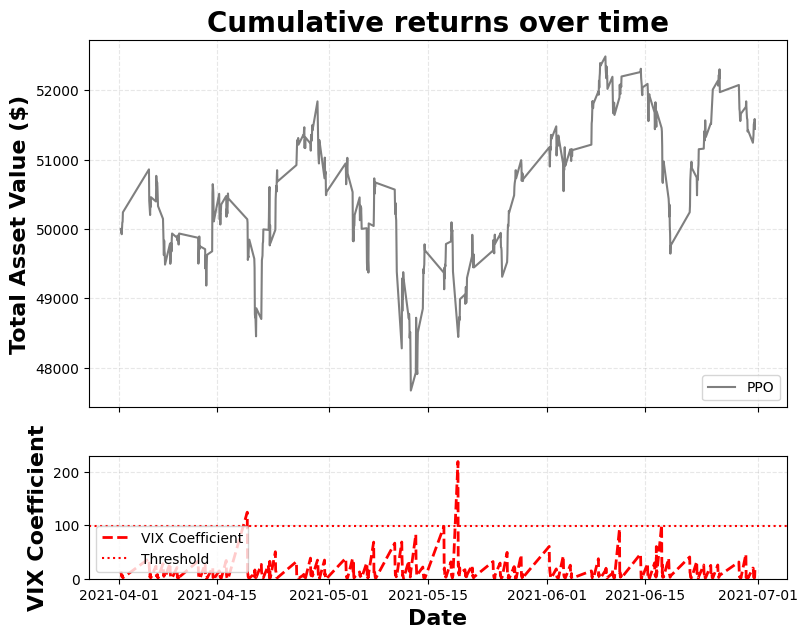

In [66]:
#@title plot_results (w/separate turbulence plot)

%matplotlib inline

def plot_results(
        account_value,
        turbulence_series,
        turbulence_thresh,
        figsize='small',
        split_label=None,
        metrics=None
    ):

    assert split_label in ['val', 'test']
    assert turbulence_series.name in ['turbulence', 'vix']
    assert figsize in ['small', 'default']

    figsizes = {
        'medium': (14, 10),
        'small': (9, 7)
    }

    # Create figure and subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsizes[figsize], sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Main plot
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO': {'color': '#7f7f7f', 'linestyle': '-'},
        'TD3': {'color': '#bcbd22', 'linestyle': '--'},
        'SAC': {'color': '#17becf', 'linestyle': '-'},
        'DJIA': {'color': '#000000', 'linestyle': '-'},
    }

    if 'DJIA' in account_value:
        ax1.plot(account_value.index, account_value['DJIA'], label="Dow Jones Index",
                linestyle=method_styles['DJIA']['linestyle'], color=method_styles['DJIA']['color'])

    if 'date' in account_value.columns:
        account_value.set_index('date', inplace=True)

    account_value.rename(columns={col: col.upper() for col in account_value.columns}, inplace=True)

    for model_name in account_value.columns:
        style = method_styles[model_name]
        ax1.plot(account_value.index, account_value[model_name], label=model_name, **style)

    # Customize main plot
    ax1.set_title(f"Cumulative returns over time", fontsize=20, fontweight='bold')
    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Turbulence plot
    if turbulence_series.name == 'turbulence':
        turbulence_label = "Turbulence Index"
    else:
        turbulence_label = "VIX Coefficient"
    ax2.plot(turbulence_series.index, turbulence_series, label=turbulence_label, color='red', linestyle='--', linewidth=2)
    ax2.axhline(y=turbulence_thresh, color='red', linestyle=':', label='Threshold')
    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.legend(loc='lower left')
    ax2.grid(True, linestyle='--', alpha=0.3)
    max_turbulence = max(turbulence_series.max(), turbulence_thresh)
    ax2.set_ylim(0, max_turbulence + 10)
    # ax2.set_yticks(list(ax2.get_yticks()) + [turbulence_thresh])

    # Shared x-axis label
    ax2.set_xlabel("Date", fontsize=16, fontweight='bold')

    # Tight layout
    # plt.tight_layout()
    return fig

# Example usage:
fig = plot_results(
    **val_result,
    figsize='small',
    split_label='val',
    metrics=val_metrics,
)

plt.show()

In [67]:
#@title plot_results (enhanced)

%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def plot_results(
        account_value,
        turbulence_series,
        turbulence_thresh,
        figsize='small',
        split_label=None,
        metrics=None,
        allowed_metrics=['sharpe_ratio', 'mdd', 'cum_return', 'ann_return'],
        ylim_padding=6_000,
        ylim_bottom = None,
        ylim_top = None
    ):
    assert split_label in ['val', 'test']
    assert turbulence_series.name in ['turbulence', 'vix']
    assert figsize in ['small', 'medium']


    figsizes = {
        'medium': (14, 10),
        'small': (8.3, 8)
    }

    # Create figure and subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsizes[figsize], sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Method styles
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO': {'color': '#7f7f7f', 'linestyle': '-'},
        'TD3': {'color': '#bcbd22', 'linestyle': '--'},
        'SAC': {'color': '#17becf', 'linestyle': '-'},
        'DJIA': {'color': '#000000', 'linestyle': '-'},
    }

    # # Plot DJIA if present
    # if 'DJIA' in account_value:
    #     ax1.plot(account_value.index, account_value['DJIA'], label="Dow Jones Index",
    #             linestyle=method_styles['DJIA']['linestyle'], color=method_styles['DJIA']['color'])

    # Ensure date is index
    if 'date' in account_value.columns:
        account_value.set_index('date', inplace=True)

    account_value.rename(columns={col: col.upper() for col in account_value.columns}, inplace=True)

    # Plot account values
    for model_name in account_value.columns:
        style = method_styles.get(model_name, {'color': 'blue', 'linestyle': '-'})  # Default style fallback
        ax1.plot(account_value.index, account_value[model_name], label=model_name, **style)

    # Construct subtitle text
    turbulence_thresh = round(turbulence_thresh)
    turbulence_label = "Turbulence Index" if turbulence_series.name == 'turbulence' else "VIX Coefficient"
    split_label_name = ('validation' if split_label == 'val' else split_label).capitalize()
    title = f"{split_label_name} split | {turbulence_label} threshold: {turbulence_thresh}"
    fig.suptitle(title, fontsize=20, fontweight='bold')

   # Define the mapping for metric names
    full_names = {
        'mdd': 'MDD',
        'ann_return': 'Annualized Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio'
    }

    # Add subtitle, properly positioned and centered
    if metrics:
        metric_text = ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in metrics.items()
            if name in allowed_metrics
        )
        ax1.set_title(metric_text, fontsize=12, color='gray', ha='center')


    # **Prettify y-axis numbers**
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # **Horizontal Line at Initial Asset Value**
    initial_asset_value = account_value.iloc[0].mean()  # Assuming initial value from mean of first row
    min_account_value = account_value.min().min()
    max_account_value = account_value.max().max()

    ax1.axhline(y=initial_asset_value, color='gray', linestyle='-.', linewidth=1.5, label="Initial Asset Value")

    # **Main Plot Customization**
    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')

    if ylim_bottom is None:
        ylim_bottom = min_account_value - ylim_padding
    ax1.set_ylim(bottom=ylim_bottom)

    if ylim_top is None:
        ylim_top = max_account_value + ylim_padding
    ax1.set_ylim(top=ylim_top)

    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    import numpy as np

    # Create a twin y-axis on the right
    ax1_right = ax1.twinx()

    # Mirror the left axis range
    ax1_right.set_ylim(ax1.get_ylim())

    # Get the existing tick positions from the left axis
    left_ticks = ax1.get_yticks().tolist()
    ymin, ymax = ax1.get_ylim()

    # Compute start and end asset values (mean of first/last row)
    start_value = account_value.iloc[0].mean()
    end_value   = account_value.iloc[-1].mean()

    # Only add start/end values if they lie within the current y-limits
    extra_ticks = []
    if ymin <= start_value <= ymax:
        extra_ticks.append(start_value)
    if ymin <= end_value <= ymax:
        extra_ticks.append(end_value)

    # Combine left ticks + extra ticks, then sort them
    all_ticks = sorted(set(left_ticks + extra_ticks))

    # Label only the start/end ticks, leave all others blank
    labels = []
    for tick in all_ticks:
        if np.isclose(tick, start_value):
            labels.append(f"{tick:,.0f}")
        elif np.isclose(tick, end_value):
            labels.append(f"{tick:,.0f}")
        else:
            labels.append("")

    ax1_right.set_yticks(all_ticks)
    ax1_right.set_yticklabels(labels)

    # Optionally, remove any right-axis label/grid:
    ax1_right.set_ylabel('')
    ax1_right.grid(False)

    # **Turbulence Plot**
    ax2.plot(turbulence_series.index, turbulence_series, label=turbulence_label, color='red', linestyle='--', linewidth=2)
    ax2.axhline(y=turbulence_thresh, color='red', linestyle=':', label=f'Threshold = {turbulence_thresh}')

    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.3)

    max_turbulence = max(turbulence_series.max(), turbulence_thresh)
    ax2.set_ylim(0, max_turbulence + 10)

    # **Shared x-axis label**
    ax2.set_xlabel("Date", fontsize=16, fontweight='bold')

    return fig

In [68]:
#@title plot_results (enchanced | list input support)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

def plot_results(
        account_value,
        turbulence_series,
        turbulence_thresh,
        turbulence_quantile=None,
        figsize='small',
        split_label=None,
        metrics=None,
        index_metrics=None,
        index_name='DJIA',
        metrics_highlight_model_name='PPO',
        allowed_metrics=['sharpe_ratio', 'mdd', 'cum_return', 'ann_return'],
        ylim_padding=6_000,
        ylim_bottom=None,
        ylim_top=None
    ):
    """
    This function now supports two input modes:
      1. Single DataFrame/Series/scalar for the three main inputs
      2. Lists of DataFrames/Series/scalars for multiple periods
    """

    # --- 1) Check inputs, possibly concatenate if they are lists ---
    is_list_input = isinstance(account_value, list)
    if is_list_input:
        # If one is a list, all must be lists
        assert isinstance(turbulence_series, list), "If account_value is a list, turbulence_series must be a list."
        assert isinstance(turbulence_thresh, list), "If account_value is a list, turbulence_thresh must be a list."
        assert len(account_value) == len(turbulence_series) == len(turbulence_thresh), \
            "All three lists must have the same length."
        assert turbulence_series[0].name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value[0].columns
        assert turbulence_quantile is not None
        if index_metrics is not None:
            assert index_name in account_value[0].columns

        # Concatenate across periods
        df_concat = []
        ts_concat = []
        thresh_concat = []
        for df_period, ts_period, thr_period in zip(account_value, turbulence_series, turbulence_thresh):
            # Ensure date is index for each period's DataFrame
            if 'date' in df_period.columns:
                df_period = df_period.set_index('date')
            df_period.rename(columns={col: col.upper() for col in df_period.columns}, inplace=True)
            df_concat.append(df_period)

            # Make sure index matches or is alignable (assuming same index)
            ts_concat.append(ts_period)

            # Repeat threshold value for length of this period
            # and store it as a Series to match the index
            thr_series = pd.Series([thr_period]*len(df_period), index=df_period.index)
            thresh_concat.append(thr_series)

        # Final single DataFrame, Series, Series for plotting
        account_value = pd.concat(df_concat)
        turbulence_series = pd.concat(ts_concat)
        turbulence_thresh = pd.concat(thresh_concat)

    else:
        # Single input variant
        assert not isinstance(turbulence_series, list), "turbulence_series must not be a list if account_value is not a list."
        assert not isinstance(turbulence_thresh, list), "turbulence_thresh must not be a list if account_value is not a list."
        assert turbulence_series.name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value.columns
        if index_metrics is not None:
            assert index_name in account_value.columns

        # Ensure date is index
        if 'date' in account_value.columns:
            account_value.set_index('date', inplace=True)
        account_value.rename(columns={col: col.upper() for col in account_value.columns}, inplace=True)

    # --- 2) Original asserts (unchanged) ---
    assert split_label in ['val', 'test']
    assert figsize in ['small', 'medium']

    # --- 3) Prepare figure ---
    figsizes = {
        'medium': (14, 10),
        'small': (8.3, 8)
    }
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsizes[figsize], sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- 4) Method styles ---
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO': {'color': 'blue', 'linestyle': '-'},
        'TD3': {'color': '#bcbd22', 'linestyle': '--'},
        'SAC': {'color': '#17becf', 'linestyle': '-'},
        'DJIA': {'color': '#000000', 'linestyle': '-'},
    }

    # --- 5) Plot account values ---
    for model_name in account_value.columns:
        style = method_styles.get(model_name, {'color': 'blue', 'linestyle': '-'})  # fallback style
        ax1.plot(account_value.index, account_value[model_name], label=model_name, **style)

    # --- 6) Title and subtitle logic ---
    turbulence_label = "Turbulence Index" if turbulence_series.name == 'turbulence' else "VIX Coefficient"
    split_label_name = ('validation' if split_label == 'val' else split_label).capitalize()

    # If threshold is still a single number, round it; if it's a Series, round all values
    if isinstance(turbulence_thresh, (int, float)):
        # single numeric
        rounded_thresh_text = str(round(turbulence_thresh))
        title = f"{split_label_name} split | {turbulence_label} threshold: {rounded_thresh_text}"
    else:
        # it's a Series, just mention "multiple" or no direct numeric
        turbulence_thresh = turbulence_thresh.round()
        title = f"{split_label_name} split | {turbulence_label} insample quantile: {turbulence_quantile}"

    fig.suptitle(title, fontsize=20, fontweight='bold')

    full_names = {
        'mdd': 'MDD',
        'ann_return': 'Annualized Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio'
    }
    # Build subtitle lines
    subtitle_lines = []

    if metrics:
        metric_text = f"{metrics_highlight_model_name} | "
        metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(metric_text)

    # NEW: optionally handle index_metrics in a similar way
    if index_metrics:
        index_metric_text = f"{index_name} | "
        index_metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in index_metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(index_metric_text)

    # If we have any lines to show, join them with newline(s) and set as subtitle
    if subtitle_lines:
        ax1.set_title("\n".join(subtitle_lines), fontsize=12, color='gray', ha='center')

    # --- 7) Y-axis (main) ---
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Horizontal line at initial asset value
    initial_asset_value = account_value.iloc[0].mean()
    min_account_value = account_value.min().min()
    max_account_value = account_value.max().max()
    ax1.axhline(y=initial_asset_value, color='gray', linestyle='-.', linewidth=1.5, label="Initial Asset Value")

    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')

    if ylim_bottom is None:
        ylim_bottom = min_account_value - ylim_padding
    if ylim_top is None:
        ylim_top = max_account_value + ylim_padding
    ax1.set_ylim(bottom=ylim_bottom, top=ylim_top)

    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # --- 8) Second y-axis ticks ---
    ax1_right = ax1.twinx()
    ax1_right.set_ylim(ax1.get_ylim())
    left_ticks = ax1.get_yticks().tolist()
    ymin, ymax = ax1.get_ylim()

    start_value = account_value.iloc[0].mean()
    end_value = account_value.iloc[-1].mean()

    extra_ticks = []
    if ymin <= start_value <= ymax:
        extra_ticks.append(start_value)
    if ymin <= end_value <= ymax:
        extra_ticks.append(end_value)

    all_ticks = sorted(set(left_ticks + extra_ticks))
    labels = []
    for tick in all_ticks:
        if np.isclose(tick, start_value):
            labels.append(f"{tick:,.0f}")
        elif np.isclose(tick, end_value):
            labels.append(f"{tick:,.0f}")
        else:
            labels.append("")
    ax1_right.set_yticks(all_ticks)
    ax1_right.set_yticklabels(labels)
    ax1_right.set_ylabel('')
    ax1_right.grid(False)

    # --- 9) Turbulence plot ---
    ax2.plot(turbulence_series.index, turbulence_series, label=turbulence_label,
             color='red', linestyle='--', linewidth=2)

    # Plot threshold line or series
    if isinstance(turbulence_thresh, (int, float)):
        # single horizontal line
        ax2.axhline(y=turbulence_thresh, color='red', linestyle=':', label=f'Threshold = {round(turbulence_thresh)}')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh)
    else:
        # threshold is a Series
        ax2.plot(turbulence_thresh.index, turbulence_thresh, color='red', linestyle=':',
                 label='Threshold')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh.max())

    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_ylim(0, max_turbulence + 10)
    ax2.set_xlabel("Date", fontsize=16, fontweight='bold')

    for ax in [ax1, ax2]:
        # Major ticks (quarter boundaries)
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        # Minor ticks (monthly)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

        # Draw major grid lines (more pronounced)
        ax.grid(which='major', axis='x', linestyle='-', linewidth=1.2, color='black', alpha=0.5)

        # Draw minor grid lines (finer)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)

    # # ------------------
    # # On ax2, enable labeling of minor ticks
    # ax2.xaxis.set_minor_formatter(mdates.DateFormatter('%Y-%m'))  # or '%m/%Y' etc.
    # ax2.tick_params(axis='x', which='minor', labelsize=8, labelrotation=45)

    ax2.tick_params(axis='x', which='major', labelsize=8, labelrotation=45)

    return fig

In [80]:
#@title plot_results (enchanced | list input | list of arrays for thresholds )
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

def plot_results(
        account_value,
        turbulence_series,
        turbulence_thresh,
        turbulence_quantile=None,
        figsize='small',
        split_label=None,
        metrics=None,
        index_metrics=None,
        index_name='DJIA',
        metrics_highlight_model_name='PPO',
        allowed_metrics=['sharpe_ratio', 'mdd', 'cum_return', 'ann_return'],
        ylim_padding=6_000,
        ylim_bottom=None,
        ylim_top=None
    ):
    """
    This function now supports two input modes:
      1. Single DataFrame/Series/scalar for the three main inputs
      2. Lists of DataFrames/Series/scalars for multiple periods
    """

    # --- 1) Check inputs, possibly concatenate if they are lists ---
    is_list_input = isinstance(account_value, list)
    if is_list_input:
        # If one is a list, all must be lists
        assert isinstance(turbulence_series, list), "If account_value is a list, turbulence_series must be a list."
        assert isinstance(turbulence_thresh, list), "If account_value is a list, turbulence_thresh must be a list."
        assert len(account_value) == len(turbulence_series) == len(turbulence_thresh), \
            "All three lists must have the same length."
        assert turbulence_series[0].name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value[0].columns
        assert turbulence_quantile is not None
        if index_metrics is not None:
            assert index_name in account_value[0].columns

        # Concatenate across periods
        df_concat = []
        ts_concat = []
        thresh_concat = []
        for df_period, ts_period, thr_period in zip(account_value, turbulence_series, turbulence_thresh):
            # Ensure date is index for each period's DataFrame
            if 'date' in df_period.columns:
                df_period = df_period.set_index('date')
            df_period.rename(columns={col: col.upper() for col in df_period.columns}, inplace=True)
            df_concat.append(df_period)

            # Make sure index matches or is alignable (assuming same index)
            ts_concat.append(ts_period)

            # Repeat threshold value for length of this period
            # and store it as a Series to match the index
            if isinstance(thr_period, (int, float)):
                # Scalar threshold: repeat for all timestamps
                thr_series = pd.Series([thr_period]*len(df_period), index=df_period.index)
            elif isinstance(thr_period, (list, np.ndarray)) and len(thr_period) == len(df_period):
                # Array threshold: create a Series from the array
                thr_series = pd.Series(thr_period, index=df_period.index)
            else:
                raise ValueError(
                    "Each turbulence_thresh entry must be either a scalar or "
                    "an array matching the period length."
                )

            thresh_concat.append(thr_series)

        # # Final single DataFrame, Series, Series for plotting
        # account_value = pd.concat(df_concat)
        # turbulence_series = pd.concat(ts_concat)
        # turbulence_thresh = pd.concat(thresh_concat)

        # Final single DataFrame, Series, Series for plotting
        account_value = pd.concat(df_concat).sort_index()
        turbulence_series = pd.concat(ts_concat).sort_index()
        turbulence_thresh = pd.concat(thresh_concat).sort_index()


    else:
        # Single input variant
        assert not isinstance(turbulence_series, list), "turbulence_series must not be a list if account_value is not a list."
        assert not isinstance(turbulence_thresh, list), "turbulence_thresh must not be a list if account_value is not a list."
        assert turbulence_series.name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value.columns
        if index_metrics is not None:
            assert index_name in account_value.columns

        # Ensure date is index
        if 'date' in account_value.columns:
            account_value.set_index('date', inplace=True)
        account_value.rename(columns={col: col.upper() for col in account_value.columns}, inplace=True)

    # --- 2) Original asserts (unchanged) ---
    assert split_label in ['val', 'test']
    assert figsize in ['small', 'medium']

    # --- 3) Prepare figure ---
    figsizes = {
        'medium': (14, 10),
        'small': (8.3, 8)
    }
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsizes[figsize], sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- 4) Method styles ---
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO': {'color': 'blue', 'linestyle': '-'},
        'TD3': {'color': '#bcbd22', 'linestyle': '--'},
        'SAC': {'color': '#17becf', 'linestyle': '-'},
        'DJIA': {'color': '#000000', 'linestyle': '-'},
    }

    # --- 5) Plot account values ---
    for model_name in account_value.columns:
        style = method_styles.get(model_name, {'color': 'blue', 'linestyle': '-'})  # fallback style
        ax1.plot(account_value.index, account_value[model_name], label=model_name, **style)

    # --- 6) Title and subtitle logic ---
    turbulence_label = "Turbulence Index" if turbulence_series.name == 'turbulence' else "VIX Coefficient"
    split_label_name = ('validation' if split_label == 'val' else split_label).capitalize()

    # If threshold is still a single number, round it; if it's a Series, round all values
    if isinstance(turbulence_thresh, (int, float)):
        # single numeric
        rounded_thresh_text = str(round(turbulence_thresh))
        title = f"{split_label_name} split | {turbulence_label} threshold: {rounded_thresh_text}"
    else:
        # it's a Series, just mention "multiple" or no direct numeric
        turbulence_thresh = turbulence_thresh.round()
        title = f"{split_label_name} split | {turbulence_label} insample quantile: {turbulence_quantile}"

    fig.suptitle(title, fontsize=20, fontweight='bold')

    full_names = {
        'mdd': 'MDD',
        'ann_return': 'Annualized Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio'
    }
    # Build subtitle lines
    subtitle_lines = []

    if metrics:
        metric_text = f"{metrics_highlight_model_name} | "
        metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(metric_text)

    # NEW: optionally handle index_metrics in a similar way
    if index_metrics:
        index_metric_text = f"{index_name} | "
        index_metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in index_metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(index_metric_text)

    # If we have any lines to show, join them with newline(s) and set as subtitle
    if subtitle_lines:
        ax1.set_title("\n".join(subtitle_lines), fontsize=12, color='gray', ha='center')

    # --- 7) Y-axis (main) ---
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Horizontal line at initial asset value
    initial_asset_value = account_value.iloc[0].mean()
    min_account_value = account_value.min().min()
    max_account_value = account_value.max().max()
    ax1.axhline(y=initial_asset_value, color='gray', linestyle='-.', linewidth=1.5, label="Initial Asset Value")

    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')

    if ylim_bottom is None:
        ylim_bottom = min_account_value - ylim_padding
    if ylim_top is None:
        ylim_top = max_account_value + ylim_padding
    ax1.set_ylim(bottom=ylim_bottom, top=ylim_top)

    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # --- 8) Second y-axis ticks ---
    ax1_right = ax1.twinx()
    ax1_right.set_ylim(ax1.get_ylim())
    left_ticks = ax1.get_yticks().tolist()
    ymin, ymax = ax1.get_ylim()

    start_value = account_value.iloc[0].mean()
    end_value = account_value.iloc[-1].mean()

    extra_ticks = []
    if ymin <= start_value <= ymax:
        extra_ticks.append(start_value)
    if ymin <= end_value <= ymax:
        extra_ticks.append(end_value)

    all_ticks = sorted(set(left_ticks + extra_ticks))
    labels = []
    for tick in all_ticks:
        if np.isclose(tick, start_value):
            labels.append(f"{tick:,.0f}")
        elif np.isclose(tick, end_value):
            labels.append(f"{tick:,.0f}")
        else:
            labels.append("")
    ax1_right.set_yticks(all_ticks)
    ax1_right.set_yticklabels(labels)
    ax1_right.set_ylabel('')
    ax1_right.grid(False)

    # --- 9) Turbulence plot ---
    ax2.plot(turbulence_series.index, turbulence_series, label=turbulence_label,
             color='red', linestyle='--', linewidth=2)

    # Plot threshold line or series
    if isinstance(turbulence_thresh, (int, float)):
        # single horizontal line
        ax2.axhline(y=turbulence_thresh, color='red', linestyle=':', label=f'Threshold = {round(turbulence_thresh)}')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh)
    else:
        # threshold is a Series
        ax2.plot(turbulence_thresh.index, turbulence_thresh, color='red', linestyle=':',
                 label='Threshold')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh.max())

    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_ylim(0, max_turbulence + 10)
    ax2.set_xlabel("Date", fontsize=16, fontweight='bold')

    for ax in [ax1, ax2]:
        # Major ticks (quarter boundaries)
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        # Minor ticks (monthly)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

        # Draw major grid lines (more pronounced)
        ax.grid(which='major', axis='x', linestyle='-', linewidth=1.2, color='black', alpha=0.5)

        # Draw minor grid lines (finer)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)

    # # ------------------
    # # On ax2, enable labeling of minor ticks
    # ax2.xaxis.set_minor_formatter(mdates.DateFormatter('%Y-%m'))  # or '%m/%Y' etc.
    # ax2.tick_params(axis='x', which='minor', labelsize=8, labelrotation=45)

    ax2.tick_params(axis='x', which='major', labelsize=8, labelrotation=45)

    return fig

In [70]:
#@title plot_results (gap with colour)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection

def plot_with_gap_colour(ax, ts, *, exp_freq='1H',
                         colour='tab:blue', gap_colour='orange',
                         **lc_kw):
    """
    Draw `ts` so that segments that step over `exp_freq` are coloured `gap_colour`.
    """
    # -- 1) Convert the index to matplotlib's float dates --------------------
    x = mdates.date2num(ts.index.to_pydatetime())
    y = ts.values.astype(float)
    pts   = np.column_stack([x, y])
    segs  = np.stack([pts[:-1], pts[1:]], axis=1)          # (N-1) segments

    # -- 2) Compute time-step in *seconds* -----------------------------------
    dt_sec  = (ts.index[1:] - ts.index[:-1]).total_seconds()   # 1-D float array
    gap_sec = pd.Timedelta(exp_freq).total_seconds()

    colours = np.where(dt_sec > gap_sec, gap_colour, colour)   # same length as segs

    # -- 3) Draw -------------------------------------------------------------
    lc = LineCollection(segs, colors=colours, **lc_kw)
    ax.add_collection(lc)
    ax.autoscale_view()


def plot_results(
        account_value,
        turbulence_series,
        turbulence_thresh,
        turbulence_quantile=None,
        figsize='small',
        split_label=None,
        metrics=None,
        index_metrics=None,
        index_name='DJIA',
        metrics_highlight_model_name='PPO',
        allowed_metrics=['sharpe_ratio', 'mdd', 'cum_return', 'ann_return'],
        ylim_padding=6_000,
        ylim_bottom=None,
        ylim_top=None
    ):
    """
    This function now supports two input modes:
      1. Single DataFrame/Series/scalar for the three main inputs
      2. Lists of DataFrames/Series/scalars for multiple periods
    """

    # --- 1) Check inputs, possibly concatenate if they are lists ---
    is_list_input = isinstance(account_value, list)
    if is_list_input:
        # If one is a list, all must be lists
        assert isinstance(turbulence_series, list), "If account_value is a list, turbulence_series must be a list."
        assert isinstance(turbulence_thresh, list), "If account_value is a list, turbulence_thresh must be a list."
        assert len(account_value) == len(turbulence_series) == len(turbulence_thresh), \
            "All three lists must have the same length."
        assert turbulence_series[0].name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value[0].columns
        assert turbulence_quantile is not None
        if index_metrics is not None:
            assert index_name in account_value[0].columns

        # Concatenate across periods
        df_concat = []
        ts_concat = []
        thresh_concat = []
        for df_period, ts_period, thr_period in zip(account_value, turbulence_series, turbulence_thresh):
            # Ensure date is index for each period's DataFrame
            if 'date' in df_period.columns:
                df_period = df_period.set_index('date')
            df_period.rename(columns={col: col.upper() for col in df_period.columns}, inplace=True)
            df_concat.append(df_period)

            # Make sure index matches or is alignable (assuming same index)
            ts_concat.append(ts_period)

            # Repeat threshold value for length of this period
            # and store it as a Series to match the index
            if isinstance(thr_period, (int, float)):
                # Scalar threshold: repeat for all timestamps
                thr_series = pd.Series([thr_period]*len(df_period), index=df_period.index)
            elif isinstance(thr_period, (list, np.ndarray)) and len(thr_period) == len(df_period):
                # Array threshold: create a Series from the array
                thr_series = pd.Series(thr_period, index=df_period.index)
            else:
                raise ValueError(
                    "Each turbulence_thresh entry must be either a scalar or "
                    "an array matching the period length."
                )

            thresh_concat.append(thr_series)

        # # Final single DataFrame, Series, Series for plotting
        # account_value = pd.concat(df_concat)
        # turbulence_series = pd.concat(ts_concat)
        # turbulence_thresh = pd.concat(thresh_concat)

        # Final single DataFrame, Series, Series for plotting
        account_value = pd.concat(df_concat).sort_index()
        turbulence_series = pd.concat(ts_concat).sort_index()
        turbulence_thresh = pd.concat(thresh_concat).sort_index()


    else:
        # Single input variant
        assert not isinstance(turbulence_series, list), "turbulence_series must not be a list if account_value is not a list."
        assert not isinstance(turbulence_thresh, list), "turbulence_thresh must not be a list if account_value is not a list."
        assert turbulence_series.name in ['turbulence', 'vix']
        assert metrics_highlight_model_name in account_value.columns
        if index_metrics is not None:
            assert index_name in account_value.columns

        # Ensure date is index
        if 'date' in account_value.columns:
            account_value.set_index('date', inplace=True)
        account_value.rename(columns={col: col.upper() for col in account_value.columns}, inplace=True)

    # --- 2) Original asserts (unchanged) ---
    assert split_label in ['val', 'test']
    assert figsize in ['small', 'medium']

    # --- 3) Prepare figure ---
    figsizes = {
        'medium': (14, 10),
        'small': (8.3, 8)
    }
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsizes[figsize], sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- 4) Method styles ---
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO': {'color': 'blue', 'linestyle': '-'},
        'TD3': {'color': '#bcbd22', 'linestyle': '--'},
        'SAC': {'color': '#17becf', 'linestyle': '-'},
        'DJIA': {'color': '#000000', 'linestyle': '-'},
    }

    # --- 5) Plot account values ---
    for model_name in account_value.columns:
        colour = method_styles.get(model_name, {'color': 'tab:blue'})['color']
        plot_with_gap_colour(ax1,
                            account_value[model_name],
                            exp_freq='1H',            # expected spacing
                            colour=colour,
                            gap_colour='lightgrey',
                            linewidth=2)


    # --- 6) Title and subtitle logic ---
    turbulence_label = "Turbulence Index" if turbulence_series.name == 'turbulence' else "VIX Coefficient"
    split_label_name = ('validation' if split_label == 'val' else split_label).capitalize()

    # If threshold is still a single number, round it; if it's a Series, round all values
    if isinstance(turbulence_thresh, (int, float)):
        # single numeric
        rounded_thresh_text = str(round(turbulence_thresh))
        title = f"{split_label_name} split | {turbulence_label} threshold: {rounded_thresh_text}"
    else:
        # it's a Series, just mention "multiple" or no direct numeric
        turbulence_thresh = turbulence_thresh.round()
        title = f"{split_label_name} split | {turbulence_label} insample quantile: {turbulence_quantile}"

    fig.suptitle(title, fontsize=20, fontweight='bold')

    full_names = {
        'mdd': 'MDD',
        'ann_return': 'Annualized Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio'
    }
    # Build subtitle lines
    subtitle_lines = []

    if metrics:
        metric_text = f"{metrics_highlight_model_name} | "
        metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(metric_text)

    # NEW: optionally handle index_metrics in a similar way
    if index_metrics:
        index_metric_text = f"{index_name} | "
        index_metric_text += ", ".join(
            f"{full_names.get(name, name.replace('_', ' ').capitalize())}: {value:.2f}"
            for name, value in index_metrics.items()
            if name in allowed_metrics
        )
        subtitle_lines.append(index_metric_text)

    # If we have any lines to show, join them with newline(s) and set as subtitle
    if subtitle_lines:
        ax1.set_title("\n".join(subtitle_lines), fontsize=12, color='gray', ha='center')

    # --- 7) Y-axis (main) ---
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Horizontal line at initial asset value
    initial_asset_value = account_value.iloc[0].mean()
    min_account_value = account_value.min().min()
    max_account_value = account_value.max().max()
    ax1.axhline(y=initial_asset_value, color='gray', linestyle='-.', linewidth=1.5, label="Initial Asset Value")

    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')

    if ylim_bottom is None:
        ylim_bottom = min_account_value - ylim_padding
    if ylim_top is None:
        ylim_top = max_account_value + ylim_padding
    ax1.set_ylim(bottom=ylim_bottom, top=ylim_top)

    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # --- 8) Second y-axis ticks ---
    ax1_right = ax1.twinx()
    ax1_right.set_ylim(ax1.get_ylim())
    left_ticks = ax1.get_yticks().tolist()
    ymin, ymax = ax1.get_ylim()

    start_value = account_value.iloc[0].mean()
    end_value = account_value.iloc[-1].mean()

    extra_ticks = []
    if ymin <= start_value <= ymax:
        extra_ticks.append(start_value)
    if ymin <= end_value <= ymax:
        extra_ticks.append(end_value)

    all_ticks = sorted(set(left_ticks + extra_ticks))
    labels = []
    for tick in all_ticks:
        if np.isclose(tick, start_value):
            labels.append(f"{tick:,.0f}")
        elif np.isclose(tick, end_value):
            labels.append(f"{tick:,.0f}")
        else:
            labels.append("")
    ax1_right.set_yticks(all_ticks)
    ax1_right.set_yticklabels(labels)
    ax1_right.set_ylabel('')
    ax1_right.grid(False)

    # --- 9) Turbulence plot ---
    ax2.plot(turbulence_series.index, turbulence_series, label=turbulence_label,
             color='red', linestyle='--', linewidth=2)

    # Plot threshold line or series
    if isinstance(turbulence_thresh, (int, float)):
        # single horizontal line
        ax2.axhline(y=turbulence_thresh, color='red', linestyle=':', label=f'Threshold = {round(turbulence_thresh)}')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh)
    else:
        # threshold is a Series
        ax2.plot(turbulence_thresh.index, turbulence_thresh, color='red', linestyle=':',
                 label='Threshold')
        max_turbulence = max(turbulence_series.max(), turbulence_thresh.max())

    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_ylim(0, max_turbulence + 10)
    ax2.set_xlabel("Date", fontsize=16, fontweight='bold')

    for ax in [ax1, ax2]:
        # Major ticks (quarter boundaries)
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        # Minor ticks (monthly)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

        # Draw major grid lines (more pronounced)
        ax.grid(which='major', axis='x', linestyle='-', linewidth=1.2, color='black', alpha=0.5)

        # Draw minor grid lines (finer)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)

    # # ------------------
    # # On ax2, enable labeling of minor ticks
    # ax2.xaxis.set_minor_formatter(mdates.DateFormatter('%Y-%m'))  # or '%m/%Y' etc.
    # ax2.tick_params(axis='x', which='minor', labelsize=8, labelrotation=45)

    ax2.tick_params(axis='x', which='major', labelsize=8, labelrotation=45)

    return fig

In [71]:
#@title plot_results (ignore gaps)

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

def _resolve_figsize(size):
    """
    Accepts either a tuple (w, h) or a keyword: 'small' | 'medium' | 'large'.
    Returns a (w, h) tuple suitable for Matplotlib.
    """
    if isinstance(size, (list, tuple)) and len(size) == 2:
        return tuple(size)

    lookup = {
        "small":  (6.4, 4.0),   # default matplotlib size
        "medium": (9.6, 6.0),
        "large":  (12.8, 8.0),
    }
    try:
        return lookup[size.lower()]
    except (KeyError, AttributeError):
        raise ValueError(
            f"figsize must be (width, height) or one of {list(lookup)}; "
            f"got {size!r}"
        )


# ──────────────────────────────────────────────────────────────────────────────
# 1)  Helper ─ turn a Series into one that has NaNs at every gap > exp_freq
# ──────────────────────────────────────────────────────────────────────────────
def insert_nans_at_gaps(s: pd.Series, exp_freq: str | pd.Timedelta = "1H") -> pd.Series:
    """
    Return a *copy* of `s` where a NaN is inserted every time the step between
    two consecutive rows exceeds `exp_freq`.

    Notes
    -----
    • Keeps the *original* index untouched – we just reindex+forward-fill+back-fill   
      to create the gap and then restore the old index **plus one NaN row** that
      splits the curve.
    • Works for any DateTimeIndex resolution (minutely, 5-min, hourly …).
    """
    s = s.sort_index()

    # Expand to the *full* range at the desired frequency (creates NaNs)
    full = s.reindex(pd.date_range(s.index[0], s.index[-1],
                                   freq=exp_freq, tz=s.index.tz))

    # Anything that was *really* present takes precedence
    full.update(s)

    # Collapse back – but keep the NaNs                                             ← break-points!
    return full


# ──────────────────────────────────────────────────────────────────────────────
# 2)  Main plotting routine (trimmed down to the essentials)
# ──────────────────────────────────────────────────────────────────────────────
def plot_results(account_value: pd.DataFrame,
                 turbulence_series: pd.Series | None = None,
                 turbulence_thresh: float | None = None,
                 exp_freq: str = "1H",
                 method_styles: dict | None = None,
                 figsize: tuple[int, int] | str = "small",
                 title: str = "Validation split | VIX Coefficient threshold: 99",
                 initial_cash: float = 50_000,
                 **kwargs):
    """
    Draw PnL curves without spurious overnight interpolation.

    Parameters
    ----------
    account_value   : columns = model names, index = DateTime (already filtered to trading hrs)
    turbulence_series, turbulence_thresh : passed straight to the 2nd panel (unchanged)
    exp_freq        : expected bar size (e.g. '1H', '5T'); anything larger ⇒ gap
    method_styles   : {"PPO": {"color": …, "linestyle": …}, …}
    """
    figsize = _resolve_figsize(figsize)          # ← add this line

    if method_styles is None:
        method_styles = {}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    # ── PnL panel ────────────────────────────────────────────────────────────
    for model in account_value.columns:
        style = {"linewidth": 1.5, "label": model} | method_styles.get(model, {})
        s = insert_nans_at_gaps(account_value[model], exp_freq=exp_freq)
        ax1.plot(s.index, s.values, **style)

    # Initial cash line (unchanged)
    ax1.axhline(initial_cash, color="grey", ls="--", lw=1, label="Initial Asset Value")

    ax1.set_ylabel("Total Asset Value ($)")
    ax1.set_ylim(kwargs.get("ylim_bottom"), kwargs.get("ylim_top"))
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))

    ax1.legend()
    ax1.grid(True, alpha=.3)
    ax1.set_title(title, fontsize=16, pad=10)

    # ── Turbulence / VIX panel (kept exactly as before) ─────────────────────
    if turbulence_series is not None:
        ax2.plot(turbulence_series.index, turbulence_series, "r--", label=turbulence_series.name)
        if turbulence_thresh is not None:
            ax2.axhline(turbulence_thresh, color="r", ls=":", label=f"Threshold = {turbulence_thresh}")
        ax2.set_ylabel("VIX Coefficient")
        ax2.grid(True, alpha=.3)
        ax2.legend()

    fig.autofmt_xdate()                 # rotate dates
    fig.tight_layout()
    return fig


In [78]:
# #@title plot_results (drop gaps)
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from matplotlib.ticker import FuncFormatter


# # ─────────────────────────────────────────────────────────────────────────────
# # Helpers
# # ─────────────────────────────────────────────────────────────────────────────
# def _month_xticks(compressed_x, real_idx):
#     ticks, labels, last_ym = [], [], (None, None)
#     for cx, ts in zip(compressed_x, real_idx):
#         ym = (ts.year, ts.month)
#         if ym != last_ym:
#             ticks.append(cx)
#             labels.append(ts.strftime("%Y-%m"))
#             last_ym = ym
#     return ticks, labels

# def _resolve_figsize(size):
#     """Allow keywords 'small' | 'medium' | 'large' in place of (w, h) tuple."""
#     if isinstance(size, (list, tuple)) and len(size) == 2:
#         return tuple(size)
#     sizes = {"small": (6.4, 4.0), "medium": (9.6, 6.0), "large": (12.8, 8.0)}
#     try:
#         return sizes[size.lower()]
#     except Exception:
#         raise ValueError(
#             f"figsize must be (width, height) or one of {list(sizes)}, got {size!r}"
#         )


# def _compressed_mdates(idx: pd.DatetimeIndex, exp_freq="1H", tol=0.1):
#     """
#     Convert a DateTimeIndex to *compressed* Matplotlib-date floats:
#     • regular bars keep their spacing (1 * exp_freq apart)
#     • gaps (> (1 + tol) * exp_freq) are removed from the timeline
#     """
#     nums = mdates.date2num(idx.to_pydatetime())
#     exp_sec = pd.Timedelta(exp_freq).total_seconds()

#     out = np.empty_like(nums)
#     offset_days = 0.0                     # cumulative gap length (in *days*)
#     out[0] = nums[0]

#     for i in range(1, len(nums)):
#         delta_sec = (nums[i] - nums[i - 1]) * 86_400.0          # days → seconds
#         if delta_sec > exp_sec * (1 + tol):                     # real gap
#             offset_days += (delta_sec - exp_sec) / 86_400.0
#         out[i] = nums[i] - offset_days

#     return out


# def _daily_xticks(compressed_x, real_idx):
#     """Return positions+labels (YYYY-MM-DD) for the first bar of every day."""
#     ticks, labels, last_day = [], [], None
#     for cx, ts in zip(compressed_x, real_idx):
#         if ts.date() != last_day:
#             ticks.append(cx)
#             labels.append(ts.strftime("%Y-%m-%d"))
#             last_day = ts.date()
#     return ticks, labels


# # ─────────────────────────────────────────────────────────────────────────────
# # Main routine
# # ─────────────────────────────────────────────────────────────────────────────
# def plot_results(
#     account_value: pd.DataFrame,
#     turbulence_series: pd.Series | None = None,
#     turbulence_thresh: float | None = None,
#     *,
#     exp_freq: str = "1H",
#     figsize="medium",
#     method_styles: dict | None = None,
#     initial_cash: float = 50_000,
#     title: str = "",
#     ylim_bottom=None,
#     ylim_top=None,
#     split_label: str | None = None,   # ←  NEW
#     **kwargs,                         # ←  catch-all for future extras
# ):
#     """
#     Plot P&L curves with overnight gaps removed (compressed timeline).

#     Parameters
#     ----------
#     … (unchanged docs) …
#     split_label : str, optional
#         e.g. 'train' / 'val' / 'test'.  If given, it is appended to the title.
#     """

#     if split_label:
#         title = f"{title}  |  {split_label.upper()}"

#     figsize = _resolve_figsize(figsize)
#     if method_styles is None:
#         method_styles = {}

#     # ── build compressed x-axis for the main DataFrame ──────────────────────
#     cx = _compressed_mdates(account_value.index, exp_freq=exp_freq)

#     fig, (ax1, ax2) = plt.subplots(
#         2,
#         1,
#         figsize=figsize,
#         sharex=False,
#         gridspec_kw={"height_ratios": [3, 1]},
#     )

#     # ── P&L panel ────────────────────────────────────────────────────────────
#     for col in account_value.columns:
#         style = {"lw": 1.5, "label": col} | method_styles.get(col, {})
#         ax1.plot(cx, account_value[col].values, **style)

#     ax1.axhline(initial_cash, color="grey", ls="--", lw=1, label="Initial Asset Value")
#     if ylim_bottom is not None or ylim_top is not None:
#         ax1.set_ylim(ylim_bottom, ylim_top)

#     ax1.set_ylabel("Total Asset Value ($)")
#     ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))
#     ax1.grid(alpha=0.3)
#     ax1.legend()
#     ax1.set_title(title, pad=10)

#     # ── Turbulence / VIX panel ───────────────────────────────────────────────
#     if turbulence_series is not None:
#         cx2 = _compressed_mdates(turbulence_series.index, exp_freq=exp_freq)
#         ax2.plot(
#             cx2,
#             turbulence_series.values,
#             "r--",
#             label=turbulence_series.name or "Turbulence Index",
#         )
#         if turbulence_thresh is not None:
#             ax2.axhline(
#                 turbulence_thresh,
#                 color="r",
#                 ls=":",
#                 label=f"Threshold = {turbulence_thresh}",
#             )
#         ax2.set_ylabel("VIX Coefficient")
#         ax2.grid(alpha=0.3)
#         ax2.legend()

#     # ── x-axis ticks: first bar of every month *plus the last bar* ─────────────
#     ticks, labels = _month_xticks(cx, account_value.index)

#     # ensure the last point is represented
#     if ticks[-1] < cx[-1] - 1e-9:                 # not already included
#         ticks.append(cx[-1])
#         labels.append(account_value.index[-1].strftime("%Y-%m"))

#     # grid & labels -------------------------------------------------------------
#     for ax in (ax1, ax2):
#         ax.set_xticks(ticks)
#         ax.grid(axis="x", which="major", alpha=0.3)   # vertical grid-lines

#     # labels only on the lower panel
#     ax1.set_xticklabels([])                           # hide on P&L panel
#     ax2.set_xticklabels(labels, rotation=45, ha="right")

#     fig.tight_layout()
#     return fig


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# ────────────────────────────────────────────────────────────────────────────
# helpers: figure size keywords and compressed x-axis
# ────────────────────────────────────────────────────────────────────────────
_FIGSIZES = {"small": (8.3, 8), "medium": (14, 10)}
TICKSIZE = 16
SUBTILE_FONTSIZE = 16

def _resolve_figsize(size):
    if isinstance(size, (tuple, list)) and len(size) == 2:
        return tuple(size)
    if size in _FIGSIZES:
        return _FIGSIZES[size]
    raise ValueError(f"figsize must be (w,h) or one of {_FIGSIZES}, got {size!r}")

def _compressed_mdates(idx, exp_freq="1H", tol=0.1):
    """Return a numpy array of Matplotlib date-floats with gaps (>exp_freq) removed."""
    nums     = mdates.date2num(idx.to_pydatetime())
    exp_sec  = pd.Timedelta(exp_freq).total_seconds()
    out      = np.empty_like(nums)
    offset_d = 0.0
    out[0]   = nums[0]
    for i in range(1, len(nums)):
        delta_sec = (nums[i] - nums[i-1]) * 86400.0
        if delta_sec > exp_sec * (1 + tol):
            offset_d += (delta_sec - exp_sec) / 86400.0
        out[i] = nums[i] - offset_d
    return out

def _month_xticks(cx, real_idx, ensure_last=True):
    """positions+labels for first bar of each month (+ last bar if wanted)."""
    ticks, labels, last_ym = [], [], (None, None)
    for x, ts in zip(cx, real_idx):
        ym = (ts.year, ts.month)
        if ym != last_ym:
            ticks.append(x)
            labels.append(ts.strftime("%Y-%m"))
            last_ym = ym
    if ensure_last and ticks[-1] < cx[-1] - 1e-9:
        ticks.append(cx[-1])
        labels.append(real_idx[-1].strftime("%Y-%m"))
    return ticks, labels

# ────────────────────────────────────────────────────────────────────────────
# main routine
# ────────────────────────────────────────────────────────────────────────────
def plot_results(
    account_value,
    turbulence_series,
    turbulence_thresh,
    turbulence_quantile=None,
    *,
    figsize="small",
    split_label=None,
    metrics=None,
    index_metrics=None,
    index_name="DJIA",
    metrics_highlight_model_name="PPO",
    allowed_metrics=("sharpe_ratio", "mdd", "cum_return", "ann_return"),
    ylim_padding=6_000,
    ylim_bottom=None,
    ylim_top=None,
    exp_freq="1H",
):
    """
    Original interface, but with *compressed timeline* (gaps removed).
    """

    # ── 1) figure -----------------------------------------------------------
    figsize = _resolve_figsize(figsize)
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=False,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ── 2) compressed x-axis ------------------------------------------------
    cx = _compressed_mdates(account_value.index, exp_freq=exp_freq)

    # ── 3) method styles ----------------------------------------------------
    method_styles = {
        'A2C': {'color': '#8c564b', 'linestyle': '--'},
        'DDPG': {'color': '#e377c2', 'linestyle': '-'},
        'PPO':  {'color': 'blue',     'linestyle': '-'},
        'TD3':  {'color': '#bcbd22', 'linestyle': '--'},
        'SAC':  {'color': '#17becf', 'linestyle': '-'},
        index_name: {'color': '#000000', 'linestyle': '-'},
    }

    for model in account_value.columns:
        style = method_styles.get(model, {'color': 'blue', 'linestyle': '-'})
        ax1.plot(cx, account_value[model].values, label=model, **style)

    # ── 4) title & subtitle (verbatim logic) --------------------------------
    turbulence_label   = "Turbulence Index" if turbulence_series.name == 'turbulence' else "VIX Coefficient"
    split_label_name   = ('validation' if split_label == 'val' else split_label).capitalize()

    if isinstance(turbulence_thresh, (int, float)):
        main_title = f"{split_label_name} split | {turbulence_label} threshold: {round(turbulence_thresh)}"
    else:
        turbulence_thresh = turbulence_thresh.round()
        main_title = f"{split_label_name} split | {turbulence_label} insample quantile: {turbulence_quantile}"
    fig.suptitle(main_title, fontsize=20, fontweight='bold')

    full_names = {
        'mdd': 'MDD',
        'ann_return': 'Annualized Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio'
    }
    subtitle_lines = []
    if metrics:
        line = (f"{metrics_highlight_model_name} | " +
                ", ".join(f"{full_names.get(k,k)}: {v:.2f}"
                          for k, v in metrics.items() if k in allowed_metrics))
        subtitle_lines.append(line)
    if index_metrics:
        line = (f"{index_name} | " +
                ", ".join(f"{full_names.get(k,k)}: {v:.2f}"
                          for k, v in index_metrics.items() if k in allowed_metrics))
        subtitle_lines.append(line)
    if subtitle_lines:
        ax1.set_title("\n".join(subtitle_lines), fontsize=SUBTILE_FONTSIZE, color='gray')

    # ── 5) y-axis formatting ------------------------------------------------
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    initial_asset_value = account_value.iloc[0].mean()
    ax1.axhline(initial_asset_value, color='gray', ls='-.', lw=1.5, label="Initial Asset Value")

    min_val, max_val = account_value.min().min(), account_value.max().max()
    if ylim_bottom is None:
        ylim_bottom = min_val - ylim_padding
    if ylim_top is None:
        ylim_top = max_val + ylim_padding
    ax1.set_ylim(ylim_bottom, ylim_top)
    ax1.set_ylabel("Total Asset Value ($)", fontsize=16, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, ls='--', alpha=.3)

    # secondary y-axis (start / end labels)
    ax1r = ax1.twinx()
    ax1r.set_ylim(ax1.get_ylim())
    ticks = sorted(set(ax1.get_yticks()) |
                   {initial_asset_value, account_value.iloc[-1].mean()})
    labels = [f"{t:,.0f}" if t in {initial_asset_value, account_value.iloc[-1].mean()} else ""
              for t in ticks]
    ax1r.set_yticks(ticks)
    ax1r.set_yticklabels(labels)
    ax1r.grid(False)

    # ── 6) turbulence panel --------------------------------------------------
    cx_t = _compressed_mdates(turbulence_series.index, exp_freq=exp_freq)
    ax2.plot(cx_t, turbulence_series.values, 'r--', lw=2, label=turbulence_label)
    if isinstance(turbulence_thresh, (int, float)):
        ax2.axhline(turbulence_thresh, color='r', ls=':', label=f"Threshold = {round(turbulence_thresh)}")
        max_turb = max(turbulence_series.max(), turbulence_thresh)
    else:
        ax2.plot(cx_t, turbulence_thresh.values, 'r:', label='Threshold')
        max_turb = max(turbulence_series.max(), turbulence_thresh.max())
    ax2.set_ylabel(turbulence_label, fontsize=16, fontweight='bold')
    ax2.set_ylim(0, max_turb + 10)
    ax2.legend(loc='upper left')
    ax2.grid(True, ls='--', alpha=.3)

    # ── 7) monthly ticks & grid on *both* panels ----------------------------
    ticks, labels = _month_xticks(cx, account_value.index)
    for ax in (ax1, ax2):
        ax.set_xticks(ticks)
        ax.grid(which='major', axis='x', ls='-', lw=1.2, color='black', alpha=.5)
        ax.grid(which='minor', axis='x', ls='--', lw=.5, color='gray',  alpha=.3)

    ax1.set_xticklabels([])                       # hide labels on top panel
    ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax2.set_xlabel("Date", fontsize=24, fontweight='bold')

    for ax in (ax1, ax2):
        ax.tick_params(axis='x', which='both', labelsize=TICKSIZE)   # x-axis ticks
        ax.tick_params(axis='y', which='both', labelsize=TICKSIZE)   # y-axis ticks

    # secondary y-axis (ax1r) too
    ax1r.tick_params(axis='y', which='both', labelsize=TICKSIZE)

    fig.tight_layout()
    return fig

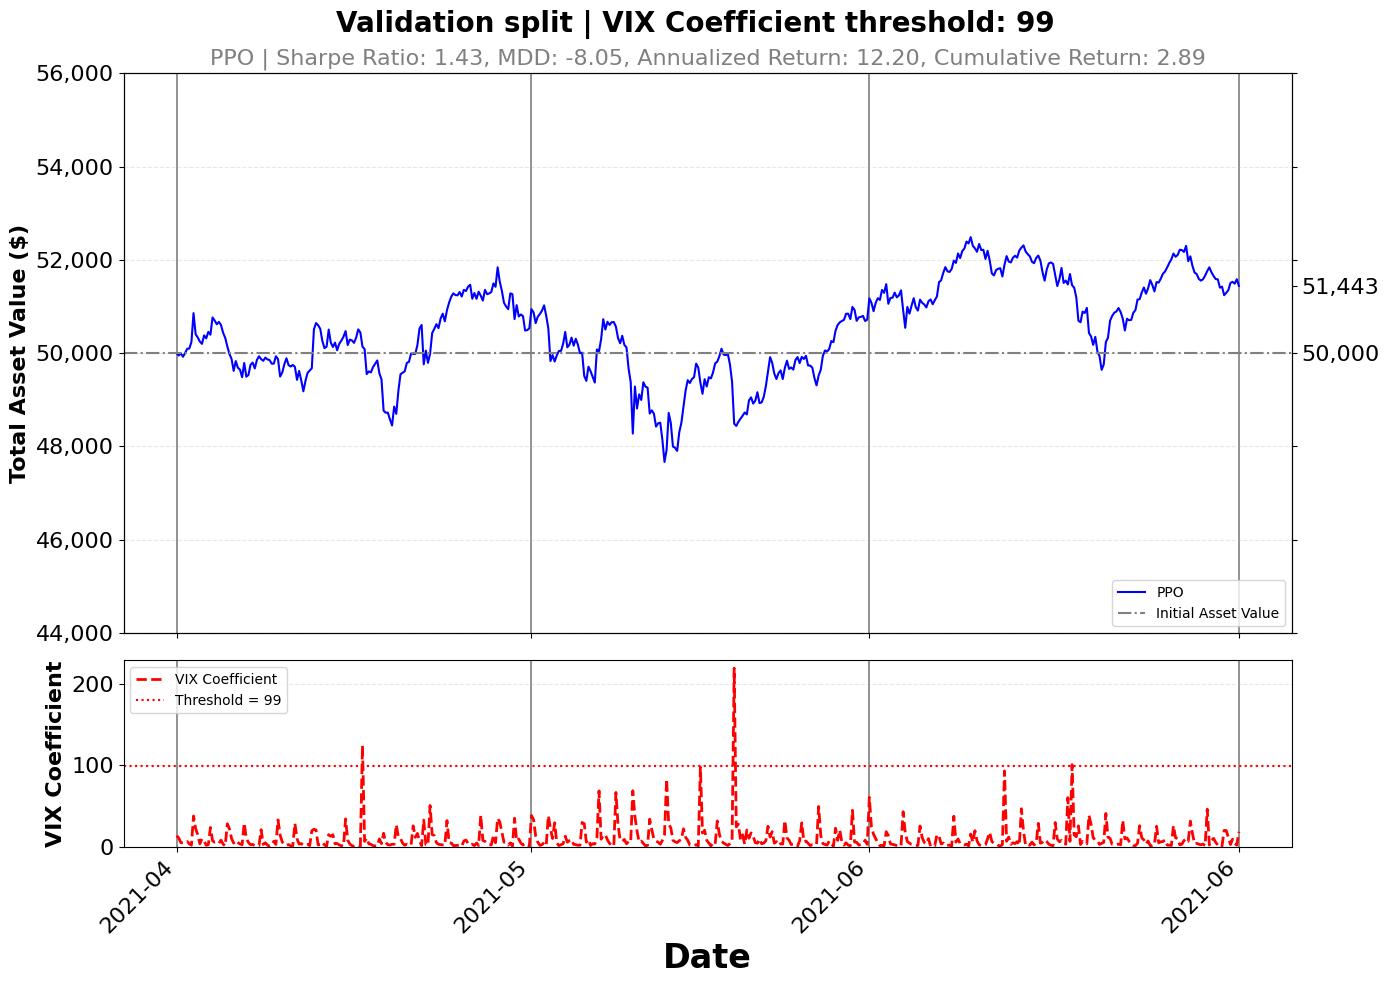

In [97]:
PLOT_YLIM_DELTA = 6_000
PLOT_INITIAL_AMOUNT = 50_000


fig = plot_results(
    **val_result,
    figsize='medium',
    split_label='val',
    metrics=val_metrics,
    ylim_bottom=PLOT_INITIAL_AMOUNT - PLOT_YLIM_DELTA,
    ylim_top=PLOT_INITIAL_AMOUNT + PLOT_YLIM_DELTA
)

plt.tight_layout()
plt.show()

In [85]:
# fig = plot_results(
#     account_value=agg_asset_values[split_label][quantile],
#     turbulence_series=agg_turbulence_series[split_label][quantile],
#     turbulence_thresh=agg_turbulence_thresh[split_label][quantile],
#     turbulence_quantile=quantile,
#     figsize='small',
#     split_label='test',
#     metrics=agg_metrics_per_split,
#     index_metrics=agg_djia_metrics
# )

# plt.tight_layout()
# plt.show()

In [ ]:
#@title batch_log_plots_as_artifact

import gc
import os
import shutil
import wandb
import matplotlib.pyplot as plt

def batch_log_plots_as_artifact(
        fig_list, fig_names, artifact_name_prefix, artifact_type="plot",
        run=None
    ):

    """
    Save a list of Matplotlib figures to a folder, log the folder as a W&B artifact,
    and delete the folder after logging.

    Parameters:
        fig_list (list): List of Matplotlib figure objects.
        folder_name (str): Name of the folder to store plots.
        artifact_name_prefix (str): Prefix for the artifact name.
        artifact_type (str): The type of the artifact (default is "plot").
    """
    if run is None:
        assert wandb.run is not None, "If run is not provided, it should be active in the background"

    assert isinstance(run, wandb.sdk.wandb_run.Run)

    # Ensure the folder exists
    os.makedirs(artifact_name_prefix, exist_ok=True)

    try:
        # Save all figures in the folder
        for i, (fig, fig_name) in enumerate(zip(fig_list, fig_names)):
            filename = os.path.join(artifact_name_prefix, f"{fig_name}.png")
            fig.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=300)
            plt.close(fig)  # Close the figure to free up memory
        fig_list.clear()  # remove references
        gc.collect()

        # Create and log the W&B artifact
        artifact_name = f"{artifact_name_prefix}-{run.id}"
        artifact = wandb.Artifact(artifact_name, type=artifact_type)
        artifact.add_dir(artifact_name_prefix, skip_cache=True)
        run.log_artifact(artifact)
    finally:
        # Ensure the folder is deleted after use
        if os.path.exists(artifact_name_prefix):
            shutil.rmtree(artifact_name_prefix)

        for fig in fig_list:
            ax = fig.gca()  # Get the current axis of the figure

            for txt in ax.texts:  # Remove all text objects
                txt.remove()

            for line in ax.lines:
                line.remove()  # Remove previous plot lines

            fig.clf()   # Clear the figure
            plt.close(fig)  # Close the figure to free memory


In [ ]:
# if log_to_wandb:
#     batch_log_plots_as_artifact(
#         [fig, fig],
#         ["val_cumulative_return_1", "val_cumulative_return_2"],
#         artifact_name_prefix="val_cumulative_return"
#     )

In [ ]:
#@title log_plot_as_artifact

import os
import matplotlib.pyplot as plt
import wandb

def log_plot_as_artifact(fig, artifact_name_prefix, artifact_type="plot"):
    """
    Save a Matplotlib figure without clipping and log it as a W&B artifact.

    Parameters:
        fig (matplotlib.figure.Figure): The Matplotlib figure to save and log.
        artifact_name (str): The name of the W&B artifact.
        artifact_type (str): The type of the artifact (default is "plot").
        filename (str): The filename to save the plot as (default is "plot.png").
    """
    assert wandb.run.id

    # Get full artifact name
    artifact_name = f'{artifact_name_prefix}-{wandb.run.id}'
    filename = artifact_name + '.png'

    try:
        # Save the figure with tight layout and proper padding
        fig.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=300)
        plt.close(fig)  # Close the figure to free up memory

        # Create and log the W&B artifact
        artifact = wandb.Artifact(artifact_name, type=artifact_type)
        artifact.add_file(filename, skip_cache=True, overwrite=True)
        wandb.log_artifact(artifact)
    finally:
        # Ensure the file is deleted after use
        if os.path.exists(filename):
            os.remove(filename)

In [ ]:
# if log_to_wandb:
#     val_fig = plot_results(**val_result)
#     log_plot_as_artifact(fig, "val_cumulative_return", artifact_type="plot")

    # test_fig = plot_results(**test_result)
    # log_plot_as_artifact(fig, "test_cumulative_return", artifact_type="plot")

In [ ]:
# if log_to_wandb:
#     run_timer_end = perf_counter()
#     run_duration_minutes = round( (run_timer_end - run_timer_start) / 60, 1)
#     wandb.run.summary[f"run.duration_minutes"] = run_duration_minutes
#     wandb.finish()

# Evaluate model

## Delete funcs

In [ ]:
#@title FUNC: delete_artifacts_by_types

import wandb
from tqdm.notebook import tqdm

def delete_artifacts_by_types(
        run_id,
        types_to_delete = [],
    ):
    assert len(types_to_delete) > 0

    api = wandb.Api()
    run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
    all_artifact_types = []
    for artifact in tqdm(run.logged_artifacts(), desc=run_id, leave=False):
        # all_artifact_types.append(artifact.type)
        if artifact.type in types_to_delete:
            artifact.delete(delete_aliases=True)

In [ ]:
#@title delete_artifacts_by_types (run)

# RUN_ID = "6grddw69"  # Replace with the actual run ID

# delete_artifacts_by_types(
#     RUN_ID,
#     types_to_delete = [
#         'plot',
#         'account_values_df',
#         'df',
#         'run_table'
#     ]
# )

In [ ]:
#@title delete_artifacts_by_types (sweep)

# SWEEP_ID = 'yd7fz9as'
SWEEP_ID = None

REVERSE = True

LIMIT = None
# LIMIT = 3

FILTER_HASH = None
FILTER_HASH = '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'

############################################

api = wandb.Api()
sweep_runs = api.sweep(f"{ENTITY}/{PROJECT}/{SWEEP_ID}").runs
num_runs = len(sweep_runs)

if REVERSE:
    sweep_runs = reversed(sweep_runs)
    # num_runs = min(LIMIT, num_runs)

run_cnt = 0
for current_run in tqdm(sweep_runs, desc="Deleting files in sweep", total=num_runs):
    if FILTER_HASH is not None and current_run.summary['config_hash'] != FILTER_HASH:
        continue
    if LIMIT is not None and run_cnt > LIMIT - 1:
        break

    delete_artifacts_by_types(
        current_run.id,
        types_to_delete = [
            'plot',
            'run_table',
            'account_values_df',
            'agg_account_values_df'
        ]
    )

    run_cnt += 1

In [ ]:
#@title delete_artifacts_by_regex
import re
from tqdm import tqdm
import wandb

def delete_artifacts_by_regex(run_id, regex_list):
    """
    Delete artifacts whose name matches any regex pattern in regex_list (partial match allowed).

    Parameters:
    run_id (str): The ID of the run.
    regex_list (list of str): List of regex patterns to partially match artifact names.

    Returns:
    None
    """
    assert len(regex_list) > 0, "regex_list must contain at least one pattern."

    api = wandb.Api()
    run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")

    for artifact in tqdm(run.logged_artifacts(), desc=f"Deleting artifacts from {run_id}", leave=False):
        if any(re.match(pattern, artifact.name) for pattern in regex_list):
            print(f"Deleting artifact: {artifact.name}")
            artifact.delete(delete_aliases=True)


In [ ]:
#@title delete_artifacts_by_regex (run)

RUN_ID = "cetkpj0x"  # Replace with the actual run ID

delete_artifacts_by_regex(
    RUN_ID,
    regex_list = [
        '-qs'
    ]
)

## Common funcs

In [ ]:
#@title load_rl_module

import ray
from ray.rllib.core import DEFAULT_MODULE_ID
from ray.rllib.core.rl_module.rl_module import RLModule

# Initialize Ray
# ray.init(ignore_reinit_error=True)

def load_rl_module(model_name, trained_models_dir="trained_models"):
    ckpt_path = os.path.join(
        trained_models_dir,
        model_name,
        "learner_group",
        "learner",
        "rl_module",
        DEFAULT_MODULE_ID,
    )

    # Path to checkpoint
    rl_module = RLModule.from_checkpoint(
        os.path.abspath(ckpt_path)
    )
    return rl_module

In [ ]:
#@title Download artifacts
from pathlib import Path

def load_artifacts(run_id, artifact_types, prepend_run_id=False, skip_cache=False):
    assert isinstance(artifact_types, list)

    # Initialize the W&B API
    api = wandb.Api()

    # Retrieve the run
    run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")

    # Iterate over the artifacts used or logged by the run
    artifacts_cnt = {_type: 0 for _type in artifact_types}
    artifacts_folders_per_run = {_type: [] for _type in artifact_types}
    print(len(run.logged_artifacts()))
    for artifact in run.logged_artifacts():
        # print(f'Considering artifact {artifact.name}')

        if "latest" in artifact.aliases \
        and artifact.type in artifact_types:
            artifacts_cnt[artifact.type] += 1

            artifact_folder = Path(f'{artifact.name}')
            if prepend_run_id:
                artifact_folder = run_id / artifact_folder

            artifacts_folders_per_run[artifact.type].append(artifact_folder)

            if not os.path.exists(artifact_folder) or skip_cache:
                !rm -rf {str(artifact_folder)}

                print(f"Downloading artifacts to {artifact_folder}")
                artifact.download(artifact_folder)
            else:
                print(f"Using cached data at {artifact_folder}")


    print(f"Run id: {run_id}")
    print(f'Artifacts downloaded cnt per type: {artifacts_cnt}')
    print(f"Artifacts folders per type: {artifacts_folders_per_run}")
    print()
    return artifacts_folders_per_run

# artifacts_folders_per_run = load_artifacts(
#     run_id='rbug5oxn',
#     artifact_types=['trained_models'],
#     prepend_run_id=True
# )

# artifacts_folders_per_run

In [ ]:
#@title group_by_hash_and_sort_by_date (for all runs in a sweep)

from collections import OrderedDict
from datetime import datetime

def group_by_hash_and_sort_by_date(
        sweep_id,
        return_inner_list=True
    ):

    api = wandb.Api()
    sweep_runs = api.sweep(f"{ENTITY}/{PROJECT}/{sweep_id}").runs

    prev_run_id = None
    prev_run_id_list = []

    # Collect run IDs and their test_start_date, grouped by config_hash
    config_hash_to_runs = {}
    for run in sweep_runs:
        config_hash = get_config_hash(run.config)
        if config_hash not in config_hash_to_runs:
            config_hash_to_runs[config_hash] = {}

        config_hash_to_runs[config_hash][run.id] = run.config['date_range']['test_start_date']

    # Sort runs for current config hash by test_start_date
    for config_hash, runs_dict in config_hash_to_runs.items():
        sorted_runs_dict = OrderedDict(
            sorted(
                runs_dict.items(),
                key=lambda x: datetime.strptime(x[1], "%Y-%m-%d %H:%M:%S"),
            )
        )

        if return_inner_list:
            config_hash_to_runs[config_hash] = list(sorted_runs_dict.items())
        else:
            config_hash_to_runs[config_hash] = sorted_runs_dict

    return config_hash_to_runs

In [ ]:
# SWEEP_ID = 'yd7fz9as'

# config_hash_to_runs = group_by_hash_and_sort_by_date(SWEEP_ID)
# next(iter(config_hash_to_runs.items()))

In [ ]:
#@title get_last_finished_run, get_first_finished_run
def get_last_finished_run(run_list):
    for last_idx in range(-1, -len(run_list) - 1, -1):
        last_run_id, _ = run_list[last_idx]
        last_run = WANDB_API.run(f"{PROJECT}/{last_run_id}")
        if last_run.state == 'finished':
            break  # Found a finished run, exit the loop
    else:
        raise ValueError(f"No finished runs for hash {config_hash}")  # Runs if no break occurs

    return last_run

def get_first_finished_run(run_list):
    first_run_id, _ = run_list[0]
    first_run = WANDB_API.run(f"{PROJECT}/{first_run_id}")
    return first_run


SWEEP_ID = 'yd7fz9as'

config_hash_to_runs = group_by_hash_and_sort_by_date(SWEEP_ID)
config_hash, run_list = next(iter(config_hash_to_runs.items()))

last_run = get_last_finished_run(run_list)
first_run = get_first_finished_run(run_list)
first_run.state, last_run.state

In [ ]:
#@title download_artifacts_per_hash

def download_artifacts_per_hash(config_hash_to_runs, artifact_type, filter_hash=None):
    artifacts_folders_per_hash = {}
    for config_hash, sorted_runs_list in config_hash_to_runs.items():
        if filter_hash is not None and config_hash != filter_hash:
            continue

        # download account dataframes for all runs
        for run_id, _ in sorted_runs_list:
            artifacts_folders_per_run = load_artifacts(
                run_id,
                artifact_types=[artifact_type],
                prepend_run_id=True
            )
            artifacts_folders_per_hash[run_id] = artifacts_folders_per_run[artifact_type]

        return artifacts_folders_per_hash

In [ ]:
# FILTER_HASH = None
# FILTER_HASH = '5b89a8d8a13f0dad4cfe425a8b2300ab5b6fb4b1d863471a46b6758a66d4461b'

# artifacts_folders_per_run = download_artifacts_per_hash(
#     config_hash_to_runs,
#     artifact_type='account_values_df',
#     filter_hash=FILTER_HASH
# )

# artifacts_folders_per_run

In [ ]:
#@title batch_log_account_values

import os
import shutil
import wandb
import pandas as pd

def batch_log_account_values(
       dataframe_list, dataframe_names, artifact_name_prefix, artifact_type="account_values_df"
):
    """
    Logs a list of Pandas DataFrames (account values) as W&B Tables and CSV files within a single artifact.

    Parameters:
        dataframe_list (list of pd.DataFrame): List of account value DataFrames to log.
        dataframe_names (list of str): List of names corresponding to each DataFrame.
        artifact_name_prefix (str): Prefix for the artifact name.
        artifact_type (str): The type of the artifact (default is "df").
    """

    if run is None:
        assert wandb.run is not None, "If run is not provided, it should be active in the background"
    assert isinstance(run, wandb.sdk.wandb_run.Run)

    assert len(dataframe_list) == len(dataframe_names), "Mismatch between DataFrames and names"

    # Ensure directory for saving files
    os.makedirs(artifact_name_prefix, exist_ok=True)

    # Create a W&B artifact
    artifact_name = f"{artifact_name_prefix}-{wandb.run.id}"
    artifact = wandb.Artifact(artifact_name, type=artifact_type)

    for df, name in zip(dataframe_list, dataframe_names):
        file_path = os.path.join(artifact_name_prefix, f"{name}.csv")

        # Save DataFrame as CSV
        df.to_csv(file_path, index=True)

        # Add file to the artifact
        print(f'[BATCH LOG] Adding {file_path} to run {wandb.run.id}')
        artifact.add_file(file_path)

        # # Log DataFrame as W&B Table
        # wandb.log({name: wandb.Table(dataframe=df)})

    # Log the artifact to W&B
    artifact = wandb.log_artifact(artifact)

    # # Cleanup: Remove temporary files
    # shutil.rmtree(artifact_name_prefix)


In [ ]:
#@title auxilary regex funcs

import re

def extract_split_label(text):
    """Extracts 'val' or 'test' from the given string. Returns None if not found."""
    match = re.search(r'-(val|test)-', text)
    return match.group(1) if match else None

def extract_turbulence_log_name(text):
    """Extracts 'vix' or 'ti' from the given string. Returns None if not found."""
    match = re.search(r'-(vix|ti)-', text)
    return match.group(1) if match else None

def find_file_by_regex(
        folder,
        regex,
    ):

    matched_file_name = None
    for file_name in os.listdir(str(folder)):
        _match = re.search(f'({regex})', file_name)
        if _match:
            matched_file_name = Path(file_name)
            break

    return matched_file_name

### Evaluate aggregated DJIA

In [ ]:
# SWEEP_ID = 'yd7fz9as'
# config_hash_to_runs = group_by_hash_and_sort_by_date(SWEEP_ID)

In [ ]:
#@title eval_agg_dija
import wandb

def eval_agg_dija(first_run, last_run, split_label='test', silent=False):
    """
    Compute DJIA metrics aggregated over period
        from first_run `test_start_date`
        till last_run  `test_end_date`
    """

    df_djia = load_djia(
        start_date=pd.Timestamp(first_run.config['date_range']['test_start_date']),
        end_date=pd.Timestamp(last_run.config['date_range']['test_end_date']),
        initial_amount=first_run.config['initial_amount']
    )

    djia_metrics = compute_metrics(df_djia)
    print(f'djia_metrics: {djia_metrics}')

    # assert isinstance(last_run, wandb.sdk.wandb_run.Run), "last_run should be activated"

    log_eval_results(
        'djia',
        djia_metrics,
        split_label=split_label,
        metric_prefix='agg',
        run=last_run
    )

    # wandb.finish()

    return df_djia, djia_metrics

# FILTER_HASH = '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'

# run_list = config_hash_to_runs[FILTER_HASH]
# last_run = get_last_finished_run(run_list)
# first_run = get_first_finished_run(run_list)
# df_djia, djia_metrics = eval_agg_dija(first_run, last_run, silent=True)
# df_djia.head()

In [ ]:
# SILENT = True

# for config_hash, run_list in config_hash_to_runs.items():
#     last_run = get_last_finished_run(run_list)
#     first_run = get_first_finished_run(run_list)
#     df_djia = eval_agg_dija(first_run, last_run, silent=SILENT)
#     break

## Evaluate w/ quantile thresholding

In [ ]:
FILTER_HASH_LIST_DICT = {
    'yd7fz9as': [
        '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f' # up to 2020
    ],

    '7v5kglse': [
        '7806a5bb2bbf73a2f38700885860b45f8a51fa0060ffab4faf277248bf65b725' # up to 2025
    ]
}

SWEEP_ID = 'yd7fz9as' # PPO 8k up to 2020
# SWEEP_ID = '7v5kglse' # PPO 8k up to 2025

config_hash_to_runs = group_by_hash_and_sort_by_date(SWEEP_ID)

In [ ]:
#@title evaluate sliding window for a single quantile

FILTER_HASH_LIST = None
FILTER_HASH_LIST = [
    '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
]

SKIP_EVAL = False

LIMIT_RUNS = None
# LIMIT_RUNS = 2

#######################

lookback_window = 63 # one quarter
quantile = 0.5
is_expanding_insample = False

#############################

quantile_log_name = 'qe' if is_expanding_insample else 'q'

wandb.finish()
for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")
    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'

    # TODO: preload data for end_date=max(last_run_test_end_dates_over_all_config_hashes)
    # print(
    #     first_run.config['date_range']['train_start_date'],
    #     last_run.config['date_range']['test_end_date'],
    # )

    # load full data
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        if_vix = if_vix # should be fixed for a particular hash during training
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # 1. Compute threshold
        current_train_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date = first_run.config['date_range']['train_start_date'],
            end_date = current_run.config['date_range']['val_start_date'],
            if_train=True,
        )

        # compute in-sample turbulence based on full train period
        if is_expanding_insample or run_idx == 0:
            insample_turbulence = current_train_np_env_config['turbulence_array']
            insample_turbulence_threshold = np.quantile(
                insample_turbulence, quantile
            )

        # compute historical turbulence based on train data inside lookback window
        historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]
        print('test_start_date', current_run.config['date_range']['test_start_date'])
        print('val_start_date', current_run.config['date_range']['val_start_date'])

        # decide whether market is volatile or not
        historical_turbulence_mean = historical_turbulence.mean()
        if historical_turbulence_mean > insample_turbulence_threshold:
            print("assume volatile market -> use conservative in-sample threshold")
            turbulence_thresh = insample_turbulence_threshold
        else:
            print("assume non-volatile market -> use minimally restrictive in-sample threshold")
            turbulence_thresh = np.quantile(
                insample_turbulence, 1
            )

        print(
            f"Threshold: historical: {historical_turbulence_mean.round(2)} | "
            f"insample: {insample_turbulence_threshold.round(2)}"
        )
        print(f"turbulence_threshold: {turbulence_thresh.round(2)}")

        if SKIP_EVAL:
            continue

        # load val & test periods
        val_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['val_start_date'],
            end_date=current_run.config['date_range']['test_start_date'],
            if_train=False
        )

        test_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['test_start_date'],
            end_date=current_run.config['date_range']['test_end_date'],
            if_train=False,
        )

        # load model
        current_run = wandb.init(project=PROJECT, id=current_run.id, resume='must')
        artifact_folders = load_artifacts(
            current_run.id,
            artifact_types=['trained_models']
        )
        rl_module = load_rl_module(
            model_name,
            trained_models_dir = artifact_folders['trained_models'][0]
        )

        # evaluate model for each split
        for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
            # perform state transfer only for `test`
            if prev_run is not None and split_label == 'test':
                prev_end_amount, prev_end_stocks = get_env_end_state(
                    prev_run,
                    split_label,
                    turbulence_log_name,
                    turbulence_thresh=turbulence_thresh
                )
            else:
                prev_end_amount, prev_end_stocks = None, None

            # evaluate model
            result, metrics = evaluate_model(
                turbulence_thresh=turbulence_thresh,
                model_name=model_name,
                algo_or_rl_module=rl_module,
                run_config=run_config,
                np_env_config=np_env_config,
                split_label=split_label,
                log_to_wandb=False,
                return_metrics=True,
                prev_end_amount=prev_end_amount,
                prev_end_stocks=prev_end_stocks,
            )

            metrics.update({
                f"{turbulence_log_name}_insample": turbulence_thresh,
                f"{turbulence_log_name}_historical_mean": historical_turbulence_mean,
                f"{turbulence_log_name}_lookback_window": lookback_window,
            })

            log_eval_results(
                model_name,
                metrics=metrics,
                split_label=split_label,
                turbulence_log_name=None,
                turbulence_thresh=None,
                run=None,
                metric_prefix=None,
                quantile_log_name=quantile_log_name,
                quantile_thresh=quantile
            )

        prev_run = current_run
        wandb.finish()

In [ ]:
#@title evaluate regular metrics for a single quantile

FILTER_HASH_LIST = None
FILTER_HASH_LIST = [
    '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
]

SKIP_EVAL = False

LIMIT_RUNS = None
# LIMIT_RUNS = 2

#######################

lookback_window = 63 # one quarter
quantile = 0.5
is_expanding_insample = False

#############################

quantile_log_name = 'qe' if is_expanding_insample else 'q'

wandb.finish()
for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")
    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'

    # TODO: preload data for end_date=max(last_run_test_end_dates_over_all_config_hashes)
    # print(
    #     first_run.config['date_range']['train_start_date'],
    #     last_run.config['date_range']['test_end_date'],
    # )

    # load full data
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        if_vix = if_vix # should be fixed for a particular hash during training
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # 1. Compute threshold
        current_train_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date = first_run.config['date_range']['train_start_date'],
            end_date = current_run.config['date_range']['val_start_date'],
            if_train=True,
        )

        # compute in-sample turbulence based on full train period
        if is_expanding_insample or run_idx == 0:
            insample_turbulence = current_train_np_env_config['turbulence_array']
            insample_turbulence_threshold = np.quantile(
                insample_turbulence, quantile
            )

        # compute historical turbulence based on train data inside lookback window
        historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]
        print('test_start_date', current_run.config['date_range']['test_start_date'])
        print('val_start_date', current_run.config['date_range']['val_start_date'])

        # decide whether market is volatile or not
        historical_turbulence_mean = historical_turbulence.mean()
        if historical_turbulence_mean > insample_turbulence_threshold:
            print("assume volatile market -> use conservative in-sample threshold")
            turbulence_thresh = insample_turbulence_threshold
        else:
            print("assume non-volatile market -> use minimally restrictive in-sample threshold")
            turbulence_thresh = np.quantile(
                insample_turbulence, 1
            )

        print(
            f"Threshold: historical: {historical_turbulence_mean.round(2)} | "
            f"insample: {insample_turbulence_threshold.round(2)}"
        )
        print(f"turbulence_threshold: {turbulence_thresh.round(2)}")

        if SKIP_EVAL:
            continue

        # load val & test periods
        val_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['val_start_date'],
            end_date=current_run.config['date_range']['test_start_date'],
            if_train=False
        )

        test_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['test_start_date'],
            end_date=current_run.config['date_range']['test_end_date'],
            if_train=False,
        )

        # load model
        current_run = wandb.init(project=PROJECT, id=current_run.id, resume='must')
        artifact_folders = load_artifacts(
            current_run.id,
            artifact_types=['trained_models']
        )
        rl_module = load_rl_module(
            model_name,
            trained_models_dir = artifact_folders['trained_models'][0]
        )

        # evaluate model for each split
        for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
            # perform state transfer only for `test`
            if prev_run is not None and split_label == 'test':
                prev_end_amount, prev_end_stocks = get_env_end_state(
                    prev_run,
                    split_label,
                    turbulence_log_name,
                    turbulence_thresh=turbulence_thresh
                )
            else:
                prev_end_amount, prev_end_stocks = None, None

            # evaluate model
            result, metrics = evaluate_model(
                turbulence_thresh=turbulence_thresh,
                model_name=model_name,
                algo_or_rl_module=rl_module,
                run_config=run_config,
                np_env_config=np_env_config,
                split_label=split_label,
                log_to_wandb=False,
                return_metrics=True,
                prev_end_amount=prev_end_amount,
                prev_end_stocks=prev_end_stocks,
            )

            metrics.update({
                f"{turbulence_log_name}_insample": turbulence_thresh,
                f"{turbulence_log_name}_historical_mean": historical_turbulence_mean,
                f"{turbulence_log_name}_lookback_window": lookback_window,
            })

            log_eval_results(
                model_name,
                metrics=metrics,
                split_label=split_label,
                turbulence_log_name=None,
                turbulence_thresh=None,
                run=None,
                metric_prefix=None,
                quantile_log_name=quantile_log_name,
                quantile_thresh=quantile
            )

        prev_run = current_run
        wandb.finish()

In [ ]:
#@title evaluate regular metrics for quantile GRID

if 'quantile' in locals():
    del quantile

FILTER_HASH_LIST = [
    '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
]
SKIP_EVAL = False

LIMIT_RUNS = None
LIMIT_RUNS = 1

#######################

lookback_window = 63 # one quarter
is_expanding_insample = False

q_lower = 0.85
q_upper = 0.9
q_step = 0.05
quantile_grid = np.arange(q_lower, q_upper + q_step, q_step)

#############################

quantile_log_name = 'qe' if is_expanding_insample else 'q'

wandb.finish()
for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")
    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'

    # TODO: preload data for end_date=max(last_run_test_end_dates_over_all_config_hashes)
    # print(
    #     first_run.config['date_range']['train_start_date'],
    #     last_run.config['date_range']['test_end_date'],
    # )

    # load full data
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        if_vix = if_vix # should be fixed for a particular hash during training
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # 1. Compute threshold
        current_train_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date = first_run.config['date_range']['train_start_date'],
            end_date = current_run.config['date_range']['val_start_date'],
            if_train=True,
        )

        for quantile in quantile_grid:
            # compute in-sample turbulence based on full train period
            if is_expanding_insample or run_idx == 0:
                insample_turbulence = current_train_np_env_config['turbulence_array']
                insample_turbulence_threshold = np.quantile(
                    insample_turbulence, quantile
                )

            # compute historical turbulence based on train data inside lookback window
            historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]
            print('test_start_date', current_run.config['date_range']['test_start_date'])
            print('val_start_date', current_run.config['date_range']['val_start_date'])

            # decide whether market is volatile or not
            historical_turbulence_mean = historical_turbulence.mean()
            if historical_turbulence_mean > insample_turbulence_threshold:
                print("assume volatile market -> use conservative in-sample threshold")
                turbulence_thresh = insample_turbulence_threshold
            else:
                print("assume non-volatile market -> use minimally restrictive in-sample threshold")
                turbulence_thresh = np.quantile(
                    insample_turbulence, 1
                )

            print(
                f"Threshold: historical: {historical_turbulence_mean.round(2)} | "
                f"insample: {insample_turbulence_threshold.round(2)}"
            )
            print(f"turbulence_threshold: {turbulence_thresh.round(2)}")

            if SKIP_EVAL:
                continue

            # load val & test periods
            val_np_env_config = get_np_env_config(
                data,
                data_processor,
                start_date=current_run.config['date_range']['val_start_date'],
                end_date=current_run.config['date_range']['test_start_date'],
                if_train=False
            )

            test_np_env_config = get_np_env_config(
                data,
                data_processor,
                start_date=current_run.config['date_range']['test_start_date'],
                end_date=current_run.config['date_range']['test_end_date'],
                if_train=False,
            )

            # load model
            current_run = wandb.init(project=PROJECT, id=current_run.id, resume='must')
            artifact_folders = load_artifacts(
                current_run.id,
                artifact_types=['trained_models']
            )
            rl_module = load_rl_module(
                model_name,
                trained_models_dir = artifact_folders['trained_models'][0]
            )

            # evaluate model for each split
            for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
                # evaluate model
                result, metrics = evaluate_model(
                    turbulence_thresh=turbulence_thresh,
                    model_name=model_name,
                    algo_or_rl_module=rl_module,
                    run_config=run_config,
                    np_env_config=np_env_config,
                    split_label=split_label,
                    log_to_wandb=False,
                    return_metrics=True,
                    prev_end_amount=prev_end_amount,
                    prev_end_stocks=prev_end_stocks,
                )

                metrics.update({
                    f"{turbulence_log_name}_insample": turbulence_thresh,
                    f"{turbulence_log_name}_historical_mean": historical_turbulence_mean,
                    f"{turbulence_log_name}_lookback_window": lookback_window,
                })

                log_eval_results(
                    model_name,
                    metrics=metrics,
                    split_label=split_label,
                    turbulence_log_name=None,
                    turbulence_thresh=None,
                    run=None,
                    metric_prefix=None,
                    quantile_log_name=quantile_log_name,
                    quantile_thresh=quantile
                )

        prev_run = current_run
        wandb.finish()

In [ ]:
#@title evaluate AGGREGATED metrics for quantile GRID

SILENT = True

FILTER_HASH_LIST = None
FILTER_HASH_LIST = [
    '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
]

SKIP_EVAL = False

LIMIT_RUNS = None
LIMIT_RUNS = 3

#######################

lookback_window = 63 # one quarter
is_expanding_insample = False

q_lower = 0.9

q_upper = q_lower
# q_upper = 0.9

q_step = 0.1
quantile_grid = np.arange(q_lower, q_upper + q_step, q_step)

#############################

if 'quantile' in locals():
    del quantile

wandb.finish()
quantile_log_name = 'qe' if is_expanding_insample else 'q'

# expand result dataframes per each quantile per each split label
agg_asset_values = {
    'test': {
        quantile: pd.DataFrame()
        for quantile in quantile_grid
    }
}

for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")
    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'

    # load full data
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        if_vix = if_vix # should be fixed for a particular hash during training
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # load full train range
        current_train_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date = first_run.config['date_range']['train_start_date'],
            end_date = current_run.config['date_range']['val_start_date'],
            if_train=True,
        )

        # load val & test periods
        val_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['val_start_date'],
            end_date=current_run.config['date_range']['test_start_date'],
            if_train=False
        )

        test_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run.config['date_range']['test_start_date'],
            end_date=current_run.config['date_range']['test_end_date'],
            if_train=False,
        )

        for quantile in quantile_grid:
            # compute in-sample turbulence based on full train period
            if is_expanding_insample or run_idx == 0:
                insample_turbulence = current_train_np_env_config['turbulence_array']
                insample_turbulence_threshold = np.quantile(
                    insample_turbulence, quantile
                )

            # compute historical turbulence based on train data inside lookback window
            historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]

            # decide whether market is volatile or not
            historical_turbulence_mean = historical_turbulence.mean()
            if historical_turbulence_mean > insample_turbulence_threshold:
                turbulence_thresh = insample_turbulence_threshold
            else:
                turbulence_thresh = np.quantile(
                    insample_turbulence, 1
                )

            print(
                f"Threshold: historical: {historical_turbulence_mean.round(2)} | "
                f"insample: {insample_turbulence_threshold.round(2)}"
            )
            print(f"turbulence_threshold: {turbulence_thresh.round(2)}\n")

            if SKIP_EVAL:
                continue

            # load model
            current_run = wandb.init(
                project=PROJECT, id=current_run.id, resume='must',
                settings=wandb.Settings(silent="true" if SILENT else "false")
            )
            artifact_folders = load_artifacts(
                current_run.id,
                artifact_types=['trained_models']
            )
            rl_module = load_rl_module(
                model_name,
                trained_models_dir = artifact_folders['trained_models'][0]
            )

            # evaluate model for each split
            for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
                if split_label not in agg_asset_values.keys():
                    # aggregated metrics are computed only for test
                    continue

                # perform state transfer if previous run exists
                if split_label == 'test' and prev_run is not None:
                    prev_end_amount, prev_end_stocks = get_env_end_state(
                        run=prev_run,
                        model_name=model_name,
                        split_label=split_label,
                        quantile_log_name=quantile_log_name,
                        quantile_thresh=quantile,
                    )
                    print(f"Transfering previous run env state with amount: {prev_end_amount}.")
                else:
                    print("Creating brand new env.")
                    prev_end_amount, prev_end_stocks = None, None

                # evaluate model under given quantile
                result, metrics = evaluate_model(
                    turbulence_thresh=turbulence_thresh,
                    model_name=model_name,
                    algo_or_rl_module=rl_module,
                    run_config=run_config,
                    np_env_config=np_env_config,
                    split_label=split_label,
                    log_to_wandb=False,
                    return_metrics=True,
                    prev_end_amount=prev_end_amount,
                    prev_end_stocks=prev_end_stocks,
                )

                metrics.update({
                    f"{turbulence_log_name}_insample": turbulence_thresh,
                    f"{turbulence_log_name}_historical_mean": historical_turbulence_mean,
                    f"{turbulence_log_name}_lookback_window": lookback_window,
                })

                log_eval_results(
                    model_name,
                    metrics=metrics,
                    split_label=split_label,
                    turbulence_log_name=None,
                    turbulence_thresh=None,
                    run=None,
                    metric_prefix=None,
                    quantile_log_name=quantile_log_name,
                    quantile_thresh=quantile,
                )

                print('\ntrain_start_date', current_run.config['date_range']['train_start_date'])
                print('val_start_date', current_run.config['date_range']['val_start_date'])
                print('test_start_date', current_run.config['date_range']['test_start_date'])
                print('test_end_date', current_run.config['date_range']['test_end_date'])

                # asset values for current run
                run_asset_values_per_split = result['account_value']

                # debug dates
                print("\nagg_asset_values dates:")
                if len(agg_asset_values[split_label][quantile]):
                    display(agg_asset_values[split_label][quantile]['date'].agg(['min', 'max']))
                else:
                    print("No dates (empty df)")
                print("\nrun_asset_values_per_split dates:")
                display(run_asset_values_per_split['date'].agg(['min', 'max']))

                # agg asset values for current run
                agg_asset_values[split_label][quantile] = pd.concat([
                    agg_asset_values[split_label][quantile],
                    run_asset_values_per_split,
                ])

                assert agg_asset_values[split_label][quantile]['date'].is_monotonic_increasing

                # log aggregated metrics
                agg_metrics_per_split = compute_metrics(agg_asset_values[split_label][quantile])
                log_eval_results(
                    model_name,
                    agg_metrics_per_split,
                    split_label=split_label,
                    turbulence_log_name=None,
                    turbulence_thresh=None,
                    run=None,
                    metric_prefix='agg',
                    quantile_log_name=quantile_log_name,
                    quantile_thresh=quantile,
                )

        prev_run = current_run
        wandb.finish()

In [ ]:
#@title evaluate AGGREGATED metrics for quantile GRID (w/plots & DJIA & caching)

USE_CACHE = False
SILENT = True

FILTER_HASH_LIST = None
FILTER_HASH_LIST = [
    '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
]

SKIP_EVAL = False
LOG_PLOTS = True

LIMIT_RUNS = None
LIMIT_RUNS = 1

#######################

lookback_window = 63 # one quarter
is_expanding_insample = True

q_lower = 0.1
# q_lower = 0

# q_upper = q_lower
q_upper = 0.9

# q_step = 0.1
q_step = 0.1

quantile_grid = np.arange(q_lower, q_upper + q_step, q_step)

split_label = 'test' # HACK: should be iterating over splits in oter lopp and THEN over quantiles in contrast to current implementation

#############################

if LIMIT_RUNS is not None:
    num_runs = min(len(run_list), LIMIT_RUNS)
else:
    num_runs = len(run_list)

if 'quantile' in locals():
    del quantile

quantile_grid = quantile_grid.round(2)

wandb.finish()
quantile_log_name = 'qe' if is_expanding_insample else 'q'

for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")

    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    if USE_CACHE:
        # try to load cached dataframes
        artifacts_folders_per_hash = download_artifacts_per_hash(
            config_hash_to_runs,
            artifact_type='agg_account_values_df',
            filter_hash=config_hash
        )

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
        turbulence_label = 'vix'
    else:
        turbulence_log_name = 'ti'
        turbulence_label = 'turbulence'

    # load full data
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        if_vix = if_vix # should be fixed for a particular hash during training
    )

    # Init collections for expanding results
    agg_turbulence_thresh = {
        'test': {
            # quantile: pd.DataFrame()
            quantile: []
            for quantile in quantile_grid
        }
    }
    agg_asset_values = {
        'test': {
            # quantile: pd.DataFrame()
            quantile: []
            for quantile in quantile_grid
        }
    }
    agg_turbulence_series = {
        'test': {
            # quantile: pd.Series(name=turbulence_label)
            quantile: []
            for quantile in quantile_grid
        }
    }

    first_train_np_env_config = get_np_env_config(
        data,
        data_processor,
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = first_run.config['date_range']['val_start_date'],
        if_train=True,
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run_api = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # load full train period for in-sample turbulence
        current_train_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date = first_run.config['date_range']['train_start_date'],
            end_date = current_run_api.config['date_range']['val_start_date'],
            if_train=True,
        )

        # load val & test periods
        val_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run_api.config['date_range']['val_start_date'],
            end_date=current_run_api.config['date_range']['test_start_date'],
            if_train=False
        )

        test_np_env_config = get_np_env_config(
            data,
            data_processor,
            start_date=current_run_api.config['date_range']['test_start_date'],
            end_date=current_run_api.config['date_range']['test_end_date'],
            if_train=False,
        )

        # store figures and names, save later in a single artifact
        fig_list = []
        fig_names = []
        fig_collection_name = f"agg_cum_return-{split_label}-{quantile_log_name}"

        if USE_CACHE:
            # store dataframes and names, save later in a single artifact
            account_values_list = []
            account_values_names = []
            account_values_collection_name = f"agg_account_values-{split_label}-{quantile_log_name}"

            artifacts_folders_per_run = artifacts_folders_per_hash[current_run_id]

        agg_metrics_per_quantiles = []
        for quantile in quantile_grid:
            if is_expanding_insample:
                insample_turbulence = current_train_np_env_config['turbulence_array']
            else:
                insample_turbulence = first_train_np_env_config['turbulence_array']

            insample_turbulence_threshold = np.quantile(
                insample_turbulence, quantile
            ).round(2)

            # compute historical turbulence based on train data inside lookback window
            historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]
            historical_turbulence_mean = historical_turbulence.mean().round(2)

            # decide whether market is volatile or not
            if historical_turbulence_mean > insample_turbulence_threshold:
                turbulence_thresh = insample_turbulence_threshold
            else:
                turbulence_thresh = np.quantile(
                    insample_turbulence, 1
                )

            turbulence_thresh = turbulence_thresh.round(2)

            print(
                f"Threshold for quantile={quantile}: "
                f"historical: {historical_turbulence_mean} | insample: {insample_turbulence_threshold}"
            )
            print(f"turbulence_threshold: {turbulence_thresh}\n")

            if SKIP_EVAL:
                continue

            # load model
            artifact_folders = load_artifacts(
                current_run_api.id,
                artifact_types=['trained_models']
            )
            rl_module = load_rl_module(
                model_name,
                trained_models_dir = artifact_folders['trained_models'][0]
            )

            # evaluate model for each split
            for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
                if split_label not in agg_asset_values.keys():
                    # aggregated metrics are computed only for test
                    continue

                if USE_CACHE:
                    artifacts_folders_per_run = artifacts_folders_per_hash[current_run_id]
                    matched_file_path = None
                    for folder in artifacts_folders_per_run:
                        matched_file_name = find_file_by_regex(folder, 'best')
                        if matched_file_name is not None:
                            matched_file_path = folder / matched_file_name
                            break

                if USE_CACHE and matched_file_path is not None:
                    print(f"[ASSET VALUES] Using cached file: {matched_file_path}")
                    run_asset_values_per_split = pd.read_csv(matched_file_path, index_col=0)
                    display(run_asset_values_per_split)
                    run_asset_values_per_split['date'] = pd.to_datetime(
                        run_asset_values_per_split['date']
                    ).dt.tz_convert(NY).dt.tz_localize(None)
                else:
                    print("[ASSET VALUES] Running inference to obtain asset values.")
                    # perform state transfer if previous run exists
                    if split_label == 'test' and prev_run is not None:
                        assert isinstance(prev_run, wandb.apis.public.runs.Run)
                        prev_end_amount, prev_end_stocks = get_env_end_state(
                            run=prev_run,
                            model_name=model_name,
                            split_label=split_label,
                            quantile_log_name=quantile_log_name,
                            quantile_thresh=quantile,
                        )
                        print(f"Transfering previous run env state with amount: {prev_end_amount}")
                    else:
                        print("Creating brand new env.")
                        prev_end_amount, prev_end_stocks = None, None


                    # evaluate model under given quantile
                    result, metrics = evaluate_model(
                        turbulence_thresh=turbulence_thresh,
                        model_name=model_name,
                        algo_or_rl_module=rl_module,
                        run_config=run_config,
                        np_env_config=np_env_config,
                        split_label=split_label,
                        log_to_wandb=False,
                        return_metrics=True,
                        prev_end_amount=prev_end_amount,
                        prev_end_stocks=prev_end_stocks,
                    )

                    metrics.update({
                        f"threshold": turbulence_thresh,
                        f"insample_threshold": insample_turbulence_threshold,
                        f"historical_mean": historical_turbulence_mean,
                        f"lookback_window": lookback_window,
                    })

                    assert turbulence_log_name == 'vix', "TODO: support other tubulence indices logging for quantiles"
                    log_eval_results(
                        model_name,
                        metrics=metrics,
                        split_label=split_label,
                        turbulence_log_name=None,
                        turbulence_thresh=None,
                        run=current_run_api,
                        metric_prefix=None,
                        quantile_log_name=quantile_log_name,
                        quantile_thresh=quantile,
                    )

                    # asset values for current run
                    run_asset_values_per_split = result['account_value']

                print('\ntrain_start_date', current_run_api.config['date_range']['train_start_date'])
                print('val_start_date', current_run_api.config['date_range']['val_start_date'])
                print('test_start_date', current_run_api.config['date_range']['test_start_date'])
                print('test_end_date', current_run_api.config['date_range']['test_end_date'])


                # debug dates
                print("\nagg_asset_values dates:")
                if len(agg_asset_values[split_label][quantile]) > 0:
                    display(
                        pd.concat(agg_asset_values[split_label][quantile])['date'].agg(['min', 'max'])
                    )
                else:
                    print("No dates (empty df)")
                print("\nrun_asset_values_per_split dates:")
                display(run_asset_values_per_split['date'].agg(['min', 'max']))


                ######### EXPAND COLLECTIONS FOR RESULTS

                # agg_asset_values[split_label][quantile] = pd.concat([
                #     agg_asset_values[split_label][quantile],
                #     run_asset_values_per_split,
                # ])

                agg_asset_values[split_label][quantile].append(
                    run_asset_values_per_split
                )

                assert pd.concat(agg_asset_values[split_label][quantile])['date'].is_monotonic_increasing

                run_turbulence_series_per_split = result['turbulence_series']

                # agg_turbulence_series[split_label][quantile] = pd.concat([
                #     agg_turbulence_series[split_label][quantile],
                #     run_turbulence_series_per_split,
                # ])

                agg_turbulence_series[split_label][quantile].append(
                    run_turbulence_series_per_split
                )

                agg_turbulence_thresh[split_label][quantile].append(turbulence_thresh)


                ############# LOG AGGREGATED METRICS

                agg_metrics_per_split = compute_metrics(pd.concat(agg_asset_values[split_label][quantile]))

                log_eval_results(
                    model_name,
                    agg_metrics_per_split,
                    split_label=split_label,
                    turbulence_log_name=None,
                    turbulence_thresh=None,
                    run=current_run_api,
                    metric_prefix='agg',
                    quantile_log_name=quantile_log_name,
                    quantile_thresh=quantile,
                )

                agg_metrics_per_split.update({
                    f"quantile": quantile,
                })
                agg_metrics_per_quantiles.append(agg_metrics_per_split)

                # compute DJIA metrics for split for dates from first run till current run
                full_df_dija, agg_djia_metrics = eval_agg_dija(first_run, current_run_api, split_label, silent=SILENT)
                current_df_djia = full_df_dija[
                    full_df_dija['date'] >= current_run_api.config['date_range']['test_start_date']
                ]

                # add DJIA metrics to current agg result df
                agg_asset_values[split_label][quantile][-1] = pd.merge(
                    agg_asset_values[split_label][quantile][-1],
                    current_df_djia,
                    on='date'
                )

                if not LOG_PLOTS or run_idx == num_runs - 1:
                    fig = plot_results(
                        account_value=agg_asset_values[split_label][quantile],
                        turbulence_series=agg_turbulence_series[split_label][quantile],
                        turbulence_thresh=agg_turbulence_thresh[split_label][quantile],
                        turbulence_quantile=quantile,
                        figsize='small',
                        split_label='test',
                        metrics=agg_metrics_per_split,
                        index_metrics=agg_djia_metrics
                    )

                    # Create plot name
                    fig_name = f"{fig_collection_name}_{quantile}"
                    fig_list.append(fig)
                    fig_names.append(fig_name)

                if USE_CACHE:
                    # Create df name
                    account_values_name = f"{account_values_collection_name}_{quantile}"
                    account_values_list.append(agg_asset_values[split_label][quantile])
                    account_values_names.append(account_values_name)

        current_run_sdk = wandb.init(
            project=PROJECT, id=current_run_id, resume='must',
            settings=wandb.Settings(silent="true" if SILENT else "false")
        )

        agg_metrics_per_quantiles = pd.DataFrame(agg_metrics_per_quantiles)
        table = wandb.Table(dataframe=agg_metrics_per_quantiles)
        wandb.log({f'agg_metrics_per_quantiles-{split_label}-{quantile_log_name}': table})

        if not LOG_PLOTS or run_idx == len(run_list) - 1:
            batch_log_plots_as_artifact(
                fig_list,
                fig_names,
                artifact_name_prefix=fig_collection_name,
                run=current_run_sdk,
            )

        if USE_CACHE:
            batch_log_account_values(
                account_values_list,
                account_values_names,
                artifact_name_prefix=account_values_collection_name,
                artifact_type="agg_account_values_df",
                run=current_run_sdk
            )

        wandb.finish()

        # switch back to API interface, since we wont be logging metrics for prev_run on next iteration
        prev_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

In [ ]:
#@title evaluate SLIDING WINDOW aggregated metrics for quantile GRID (w/plots & DJIA & caching)

USE_CACHE = False
SILENT = True

FILTER_HASH_LIST = None
FILTER_HASH_LIST = FILTER_HASH_LIST_DICT[SWEEP_ID]

SKIP_EVAL = False

# LOG_PLOTS = False
# LOG_PLOTS = 'all'
LOG_PLOTS = 'last_only'

LIMIT_RUNS = None
# LIMIT_RUNS = 2

#######################

lookback_window = 63 # one quarter
is_expanding_insample = False
is_sliding_window = True

q_lower = 0.1
q_upper = 0.9
q_step = 0.2

# q_lower = 0.5
# q_upper = q_lower
# q_step = 0.1

quantile_grid = np.arange(q_lower, q_upper + q_step, q_step)

split_label = 'test' # HACK: should be iterating over splits in oter lopp and THEN over quantiles in contrast to current implementation

#############################

assert is_sliding_window, "Branching not implemented"
quantile_log_name = 'q'
quantile_log_name += 'q' if is_expanding_insample else ''
quantile_log_name += 's' if is_sliding_window else ''

assert isinstance(LOG_PLOTS, bool) or LOG_PLOTS in ['last_only', 'all']

if LIMIT_RUNS is not None:
    num_runs = min(len(run_list), LIMIT_RUNS)
else:
    num_runs = len(run_list)

if 'quantile' in locals():
    del quantile

if 'current_train_np_env_config' in locals():
    del current_train_np_env_config

quantile_grid = quantile_grid.round(2)
wandb.finish()

for config_hash, run_list in config_hash_to_runs.items():
    print(f"\n\nConfig_hash: {config_hash}")

    if FILTER_HASH_LIST is not None and config_hash not in FILTER_HASH_LIST:
        continue

    if USE_CACHE:
        # try to load cached dataframes
        artifacts_folders_per_hash = download_artifacts_per_hash(
            config_hash_to_runs,
            artifact_type='agg_account_values_df',
            filter_hash=config_hash
        )

    # find first and last runs
    first_run = get_first_finished_run(run_list)
    last_run = get_last_finished_run(run_list)

    if_vix = first_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
    if if_vix:
        turbulence_log_name = 'vix'
        turbulence_label = 'vix'
    else:
        turbulence_log_name = 'ti'
        turbulence_label = 'turbulence'

    turbulence_sma_col = f"{turbulence_label}_{lookback_window}_sma"

    # load full data (with lookback window for sliding window turbulence calculation)
    data, data_processor = load_cached_data(
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = last_run.config['date_range']['test_end_date'],
        tech_indicator_padding = lookback_window,
        if_vix = if_vix, # should be fixed for a particular hash during training
        technical_indicator_list = INDICATORS,
        extra_indicator_list = [turbulence_sma_col]
    )

    # Init collections for expanding results
    agg_turbulence_thresh = {
        'test': {
            # quantile: pd.DataFrame()
            quantile: []
            for quantile in quantile_grid
        }
    }
    agg_asset_values = {
        'test': {
            # quantile: pd.DataFrame()
            quantile: []
            for quantile in quantile_grid
        }
    }
    agg_turbulence_series = {
        'test': {
            # quantile: pd.Series(name=turbulence_label)
            quantile: []
            for quantile in quantile_grid
        }
    }

    first_train_np_env_config = get_np_env_config(
        data,
        data_processor,
        use_extra_indicators=True,
        start_date = first_run.config['date_range']['train_start_date'],
        end_date = first_run.config['date_range']['val_start_date'],
        if_train=True,
    )

    prev_run = None
    for run_idx, (current_run_id, _) in enumerate(run_list): # TODO: iterate over runs
        print(f"\nRun #{run_idx}: {current_run_id}")

        if LIMIT_RUNS is not None and run_idx > LIMIT_RUNS - 1:
            break

        current_run_api = WANDB_API.run(f"{PROJECT}/{current_run_id}")

        # # load full train period for in-sample turbulence
        # current_train_np_env_config = get_env_config(
        #     data,
        #     data_processor,
        #     start_date = first_run.config['date_range']['train_start_date'],
        #     end_date = current_run_api.config['date_range']['val_start_date'],
        #     # tech_indicator_padding = lookback_window - 1,
        #     if_train=True,
        # )

        # load val & test periods
        val_np_env_config = get_np_env_config(
            data,
            data_processor,
            use_extra_indicators=True,
            start_date=current_run_api.config['date_range']['val_start_date'],
            end_date=current_run_api.config['date_range']['test_start_date'],
            if_train=False
        )

        test_np_env_config = get_np_env_config(
            data,
            data_processor,
            use_extra_indicators=True,
            start_date=current_run_api.config['date_range']['test_start_date'],
            end_date=current_run_api.config['date_range']['test_end_date'],
            if_train=False,
        )

        # store figures and names, save later in a single artifact
        fig_list = []
        fig_names = []
        fig_collection_name = f"agg_cum_return-{split_label}-{quantile_log_name}"

        if USE_CACHE:
            # store dataframes and names, save later in a single artifact
            account_values_list = []
            account_values_names = []
            account_values_collection_name = f"agg_account_values-{split_label}-{quantile_log_name}"
            artifacts_folders_per_run = artifacts_folders_per_hash[current_run_id]

        agg_metrics_per_quantiles = []
        for quantile in quantile_grid:
            if is_expanding_insample:
                raise NotImplementedError("TODO: expand day by day. Turbulence threshold should be an array of threshods - one per each day")
                insample_turbulence = current_train_np_env_config['turbulence_array']
            else:
                # in-sample turbulence is static
                insample_turbulence = first_train_np_env_config['turbulence_array']

            insample_turbulence_threshold = np.quantile(
                insample_turbulence, quantile
            ).round(2)

            if SKIP_EVAL:
                continue

            # load model
            artifact_folders = load_artifacts(
                current_run_api.id,
                artifact_types=['trained_models']
            )
            rl_module = load_rl_module(
                model_name,
                trained_models_dir = artifact_folders['trained_models'][0]
            )

            # evaluate model for each split
            for split_label, np_env_config in zip(
                ['val', 'test'],
                [val_np_env_config, test_np_env_config],
            ):
                if split_label not in agg_asset_values.keys():
                    # aggregated metrics are computed only for test
                    continue

                # compute historical turbulence based on current split data inside lookback window
                historical_turbulence_mean = np_env_config[turbulence_sma_col]
                # historical_turbulence_mean = np_env_config['turbulence_array']

                turbulence_thresh = np.where(
                    historical_turbulence_mean > insample_turbulence_threshold,
                    insample_turbulence_threshold, # high volatility -> limit by in-sample turbulence
                    np.quantile(insample_turbulence, 1) # low volatility -> allow all actions
                ).round(2)

                print(
                    f"Thresholds for quantile={quantile}: ",
                    f"\thistorical_turbulence_mean: {historical_turbulence_mean}",
                    f"\tinsample_turbulence_threshold: {insample_turbulence_threshold}",
                    f"\tturbulence_threshold: {turbulence_thresh}",
                    sep='\n',
                    end='\n'
                )

                if USE_CACHE:
                    artifacts_folders_per_run = artifacts_folders_per_hash[current_run_id]
                    matched_file_path = None
                    for folder in artifacts_folders_per_run:
                        matched_file_name = find_file_by_regex(folder, 'best')
                        if matched_file_name is not None:
                            matched_file_path = folder / matched_file_name
                            break

                if USE_CACHE and matched_file_path is not None:
                    print(f"[ASSET VALUES] Using cached file: {matched_file_path}")
                    run_asset_values_per_split = pd.read_csv(matched_file_path, index_col=0)
                    display(run_asset_values_per_split)
                    run_asset_values_per_split['date'] = pd.to_datetime(
                        run_asset_values_per_split['date']
                    ).dt.tz_convert(NY).dt.tz_localize(None)
                else:
                    print("[ASSET VALUES] Running inference to obtain asset values.")
                    # perform state transfer if previous run exists
                    if split_label == 'test' and prev_run is not None:
                        assert isinstance(prev_run, wandb.apis.public.runs.Run)
                        prev_end_amount, prev_end_stocks = get_env_end_state(
                            run=prev_run,
                            model_name=model_name,
                            split_label=split_label,
                            quantile_log_name=quantile_log_name,
                            quantile_thresh=quantile,
                        )
                        print(f"Transfering previous run env state with amount: {prev_end_amount}")
                    else:
                        print("Creating brand new env.")
                        prev_end_amount, prev_end_stocks = None, None


                    # evaluate model under given quantile
                    result, metrics = evaluate_model(
                        turbulence_thresh=turbulence_thresh,
                        model_name=model_name,
                        algo_or_rl_module=rl_module,
                        run_config=run_config,
                        np_env_config=np_env_config,
                        split_label=split_label,
                        log_to_wandb=False,
                        return_metrics=True,
                        prev_end_amount=prev_end_amount,
                        prev_end_stocks=prev_end_stocks,
                    )

                    metrics.update({
                        f"threshold": turbulence_thresh,
                        f"insample_threshold": insample_turbulence_threshold,
                        f"historical_mean": historical_turbulence_mean,
                        f"lookback_window": lookback_window,
                    })

                    assert turbulence_log_name == 'vix', "TODO: support other tubulence indices logging for quantiles"
                    log_eval_results(
                        model_name,
                        metrics=metrics,
                        split_label=split_label,
                        turbulence_log_name=None,
                        turbulence_thresh=None,
                        run=current_run_api,
                        metric_prefix=None,
                        quantile_log_name=quantile_log_name,
                        quantile_thresh=quantile,
                    )

                    # asset values for current run
                    run_asset_values_per_split = result['account_value']

                print('\ntrain_start_date', current_run_api.config['date_range']['train_start_date'])
                print('val_start_date', current_run_api.config['date_range']['val_start_date'])
                print('test_start_date', current_run_api.config['date_range']['test_start_date'])
                print('test_end_date', current_run_api.config['date_range']['test_end_date'])


                # debug dates
                print("\nagg_asset_values dates:")
                if len(agg_asset_values[split_label][quantile]) > 0:
                    display(
                        pd.concat(agg_asset_values[split_label][quantile])['date'].agg(['min', 'max'])
                    )
                else:
                    print("No dates (empty df)")
                print("\nrun_asset_values_per_split dates:")
                display(run_asset_values_per_split['date'].agg(['min', 'max']))


                ######### EXPAND COLLECTIONS FOR RESULTS

                # agg_asset_values[split_label][quantile] = pd.concat([
                #     agg_asset_values[split_label][quantile],
                #     run_asset_values_per_split,
                # ])

                agg_asset_values[split_label][quantile].append(
                    run_asset_values_per_split
                )

                assert pd.concat(agg_asset_values[split_label][quantile])['date'].is_monotonic_increasing

                run_turbulence_series_per_split = result['turbulence_series']

                # agg_turbulence_series[split_label][quantile] = pd.concat([
                #     agg_turbulence_series[split_label][quantile],
                #     run_turbulence_series_per_split,
                # ])

                agg_turbulence_series[split_label][quantile].append(
                    run_turbulence_series_per_split
                )

                agg_turbulence_thresh[split_label][quantile].append(
                    turbulence_thresh
                )

                ############# LOG AGGREGATED METRICS

                agg_metrics_per_split = compute_metrics(pd.concat(agg_asset_values[split_label][quantile]))

                log_eval_results(
                    model_name,
                    agg_metrics_per_split,
                    split_label=split_label,
                    turbulence_log_name=None,
                    turbulence_thresh=None,
                    run=current_run_api,
                    metric_prefix='agg',
                    quantile_log_name=quantile_log_name,
                    quantile_thresh=quantile,
                )

                agg_metrics_per_split.update({
                    f"quantile": quantile,
                })
                agg_metrics_per_quantiles.append(agg_metrics_per_split)

                # compute DJIA metrics for split for dates from first run till current run
                full_df_dija, agg_djia_metrics = eval_agg_dija(first_run, current_run_api, split_label, silent=SILENT)
                current_df_djia = full_df_dija[
                    full_df_dija['date'] >= current_run_api.config['date_range']['test_start_date']
                ]

                # add DJIA metrics to current agg result df
                agg_asset_values[split_label][quantile][-1] = pd.merge(
                    agg_asset_values[split_label][quantile][-1],
                    current_df_djia,
                    on='date'
                )

                if not LOG_PLOTS or LOG_PLOTS == 'last_only' and run_idx == num_runs - 1:
                    fig = plot_results(
                        account_value=agg_asset_values[split_label][quantile],
                        turbulence_series=agg_turbulence_series[split_label][quantile],
                        turbulence_thresh=agg_turbulence_thresh[split_label][quantile],
                        turbulence_quantile=quantile,
                        figsize='small',
                        split_label='test',
                        metrics=agg_metrics_per_split,
                        index_metrics=agg_djia_metrics
                    )

                    # Create plot name
                    fig_name = f"{fig_collection_name}_{quantile}"
                    fig_list.append(fig)
                    fig_names.append(fig_name)

                if USE_CACHE:
                    # Create df name
                    account_values_name = f"{account_values_collection_name}_{quantile}"
                    account_values_list.append(agg_asset_values[split_label][quantile])
                    account_values_names.append(account_values_name)

        current_run_sdk = wandb.init(
            project=PROJECT, id=current_run_id, resume='must',
            settings=wandb.Settings(silent="true" if SILENT else "false")
        )

        agg_metrics_per_quantiles = pd.DataFrame(agg_metrics_per_quantiles)
        table = wandb.Table(dataframe=agg_metrics_per_quantiles)
        wandb.log({f'agg_metrics_per_quantiles-{split_label}-{quantile_log_name}': table})

        if not LOG_PLOTS or LOG_PLOTS == 'last_only' and run_idx == len(run_list) - 1:
            batch_log_plots_as_artifact(
                fig_list,
                fig_names,
                artifact_name_prefix=fig_collection_name,
                run=current_run_sdk,
            )

        if USE_CACHE:
            batch_log_account_values(
                account_values_list,
                account_values_names,
                artifact_name_prefix=account_values_collection_name,
                artifact_type="agg_account_values_df",
                run=current_run_sdk
            )

        wandb.finish()

        # switch back to API interface, since we wont be logging metrics for prev_run on next iteration
        prev_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")

In [ ]:
#@title filter_metrics
import re

current_run_id = 'cetkpj0x'
current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")
prev_run = find_prev_run(current_run.sweep.id, current_run.id)

regex_list = [
    'q_\d+',
    'qe_\d+',
]

def filter_metrics(current_run, regex_list):
    matches_per_regex = {}
    for regex in regex_list:
        matches = []
        for metric_name in current_run.summary.keys():
            match = re.search(regex, metric_name)
            if match is not None:
                matches.append(metric_name)

        # print(f"Regex `{regex}` matches:", matches)
        matches_per_regex[regex] = matches

    return matches_per_regex

# matches_per_regex = filter_metrics(current_run, regex_list)
# matches_per_regex

# assert prev_run.summary['end_amount'] == current_run.summary['start_amount']
# assert prev_run.summary['end_stocks'] == current_run.summary['start_stocks']

In [ ]:
#@title delete_summary_metrics

def delete_summary_metrics(run, metrics_to_remove: list):
    global WANDB_API
    try:
        # Remove specified keys if they exist
        deleted_keys = []
        for key in metrics_to_remove:
            if key in run.summary:
                del run.summary[key]
                print(f"Deleted {key} from run {run.id}")
                deleted_keys.append(key)

        # Apply the changes
        if len(deleted_keys) > 0:
            run.summary.update()
            print(f"Summary updated successfully for run {run.id}")
        else:
            print(f"No summary update for run {run.id}")

    except wandb.errors.CommError as e:
        print(f"Error accessing W&B: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")


In [ ]:
#@title delete_summary_metrics (run)

regex_list = [
    'q_\d+',
    'qe_\d+',
    # 'qs_\d+',
]

current_run_id = 'dcl4jcb8'
current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")
matches_per_regex = filter_metrics(current_run, regex_list)
for regex, matches in matches_per_regex.items():
    if len(matches) > 0:
        delete_summary_metrics(current_run, matches)

In [ ]:
#@title delete_summary_metrics (sweep)

# regex_list = [
#     'q_\d+',
#     'qe_\d+',
#     # 'qs_\d+',
# ]

# for config_hash, run_list in config_hash_to_runs.items():
#     for current_run_id, _ in run_list:
#         print(f"Run: {current_run_id}")
#         current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")
#         matches_per_regex = filter_metrics(current_run, regex_list)
#         for regex, matches in matches_per_regex.items():
#             if len(matches) > 0:
#                 delete_summary_metrics(current_run, matches)

In [ ]:
#@title evaluate AGGREGATE metrics for quantile GRID (with data leak)
# NOTE: data leak = use full test data from first run test_start_date up to the current test_end_date

q_lower = q_upper = 0.9
q_step = 0.1
quantile_grid = np.arange(q_lower, q_upper + q_step, q_step)
config_hash = '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'
run_list = config_hash_to_runs[config_hash]

first_run = get_first_finished_run(run_list)
last_run = get_last_finished_run(run_list)

if_vix = last_run.config.get('if_vix', True) # assume all runs with same config hash use same volatility index
if if_vix:
    turbulence_log_name = 'vix'
else:
    turbulence_log_name = 'ti'

# load full data
data, data_processor = load_cached_data(
    start_date = first_run.config['date_range']['train_start_date'],
    end_date = last_run.config['date_range']['test_end_date'],
    if_vix = if_vix # should be fixed for a particular hash during training
)

# current_run = WANDB_API.run(f"{PROJECT}/{current_run_id}")
current_run = last_run

# load full train range
current_train_np_env_config = get_np_env_config(
    data,
    data_processor,
    start_date = first_run.config['date_range']['train_start_date'],
    end_date = current_run.config['date_range']['val_start_date'],
    if_train=True,
)

# load full test period
test_np_env_config = get_np_env_config(
    data,
    data_processor,
    start_date=first_run.config['date_range']['test_start_date'],
    end_date=current_run.config['date_range']['test_end_date'],
    if_train=False,
)

agg_asset_values = {
    'test': {
        quantile: pd.DataFrame()
        for quantile in quantile_grid
    }
}

# compute in-sample turbulence based on full train period
if is_expanding_insample or run_idx == 0:
    insample_turbulence = current_train_np_env_config['turbulence_array']
    insample_turbulence_threshold = np.quantile(
        insample_turbulence, quantile
    )

# compute historical turbulence based on train data inside lookback window
historical_turbulence = current_train_np_env_config['turbulence_array'][-lookback_window:]

# decide whether market is volatile or not
historical_turbulence_mean = historical_turbulence.mean()
if historical_turbulence_mean > insample_turbulence_threshold:
    turbulence_thresh = insample_turbulence_threshold
else:
    turbulence_thresh = np.quantile(
        insample_turbulence, 1
    )

print(
    f"Threshold: historical: {historical_turbulence_mean.round(2)} | "
    f"insample: {insample_turbulence_threshold.round(2)}"
)
print(f"turbulence_threshold: {turbulence_thresh.round(2)}")

# if SKIP_EVAL:
#     continue

# load model
current_run = wandb.init(project=PROJECT, id=current_run.id, resume='must')
artifact_folders = load_artifacts(
    current_run.id,
    artifact_types=['trained_models']
)
rl_module = load_rl_module(
    model_name,
    trained_models_dir = artifact_folders['trained_models'][0]
)

# evaluate model for each split
for split_label, np_env_config in zip(['val', 'test'], [val_np_env_config, test_np_env_config]):
    if split_label not in agg_asset_values.keys():
        # aggregated metrics are computed only for test
        continue

    # perform state transfer if previous run exists
    if split_label == 'test' and prev_run is not None:
        prev_end_amount, prev_end_stocks = get_env_end_state(
            run=prev_run,
            model_name=model_name,
            split_label=split_label,
            quantile_log_name=quantile_log_name,
            quantile_thresh=quantile,
        )
        print(f"Transfering previous run env state with amount: {prev_end_amount}.")
    else:
        print("Creating brand new env.")
        prev_end_amount, prev_end_stocks = None, None

    # evaluate model under given quantile
    result, metrics = evaluate_model(
        turbulence_thresh=turbulence_thresh,
        model_name=model_name,
        algo_or_rl_module=rl_module,
        run_config=run_config,
        np_env_config=np_env_config,
        split_label=split_label,
        log_to_wandb=False,
        return_metrics=True,
        prev_end_amount=prev_end_amount,
        prev_end_stocks=prev_end_stocks,
    )

    metrics.update({
        f"{turbulence_log_name}_insample": turbulence_thresh,
        f"{turbulence_log_name}_historical_mean": historical_turbulence_mean,
        f"{turbulence_log_name}_lookback_window": lookback_window,
    })

    log_eval_results(
        model_name,
        metrics=metrics,
        split_label=split_label,
        turbulence_log_name=None,
        turbulence_thresh=None,
        run=None,
        metric_prefix='leak',
        quantile_log_name=quantile_log_name,
        quantile_thresh=quantile,
    )

    # log aggregated metrics
    run_asset_values_per_split = result['account_value']
    agg_asset_values[split_label][quantile] = pd.concat([
        agg_asset_values[split_label][quantile],
        run_asset_values_per_split,
    ])

    agg_metrics_per_split = compute_metrics(agg_asset_values[split_label][quantile])

    log_eval_results(
        model_name,
        agg_metrics_per_split,
        split_label=split_label,
        turbulence_log_name=None,
        turbulence_thresh=None,
        run=None,
        metric_prefix='leak_agg',
        quantile_log_name=quantile_log_name,
        quantile_thresh=quantile,
    )

## Evaluate w/ grid thresholds (step by step)

In [ ]:
import wandb

RUN_ID = "q0z9x202"  # Replace with the actual run ID

wandb.finish()
wandb.init(project=PROJECT, id=RUN_ID, resume='must')

In [ ]:
#@title Download artifacts

artifact_types = ['trained_models']

# Initialize the W&B API
api = wandb.Api()

# Retrieve the run
current_run = api.run(f"{ENTITY}/{PROJECT}/{RUN_ID}")

# Iterate over the artifacts used or logged by the run
for artifact in current_run.logged_artifacts():
    if artifact.type in artifact_types:
        artifact_folder = f'./{artifact.type}'
        !rm -rf artifact_folder
        artifact.download(artifact_folder)

RUN_ID = 'rbug5oxn'

In [ ]:
#@title load_rl_module

import ray
from ray.rllib.core import DEFAULT_MODULE_ID
from ray.rllib.core.rl_module.rl_module import RLModule

# Initialize Ray
# ray.init(ignore_reinit_error=True)

def load_rl_module(model_name):
    ckpt_path = os.path.join(
        "trained_models",
        model_name,
        "learner_group",
        "learner",
        "rl_module",
        DEFAULT_MODULE_ID,
    )

    # Path to checkpoint
    rl_module = RLModule.from_checkpoint(
        os.path.abspath(ckpt_path)
    )
    return rl_module

rl_module = load_rl_module(model_name)

In [ ]:
#@title compute threshold results

split_label = 'val'
np_env_config = val_np_env_config
num_intervals = 10
# default_thresh = 99

if run_config.get('if_vix', True):
    turbulence_log_name = 'vix'
else:
    turbulence_log_name = 'ti'
    raise NotImplementedError

# Calculate threshold grid
turb_ary = np_env_config['turbulence_array']
threshold_grid = np.linspace(turb_ary.min(), turb_ary.max(), num_intervals)
threshold_grid = np.ceil(threshold_grid).astype(int).tolist()
threshold_grid.append(max(threshold_grid) + 1)
# threshold_grid.append(default_thresh)

th_metrics = []  # List to store metrics for all thresholds
th_results = {}  # Dictionary to store results per threshold

for th in threshold_grid:
    result, metrics = evaluate_model(
        turbulence_thresh=th,
        model_name=model_name,
        algo_or_rl_module=rl_module,
        run_config=run_config,
        np_env_config=np_env_config,
        split_label='val',
        log_to_wandb=True,
        return_metrics=True
    )

    metrics = {turbulence_log_name: th, **metrics}
    th_metrics.append(metrics)
    th_results[th] = result

# Convert metrics to a DataFrame and log to WandB
df = pd.DataFrame(th_metrics).astype({turbulence_log_name: int})

In [ ]:
#@title drop duplicates and zeros
metric_cols = df.drop(columns=[turbulence_log_name]).columns # take only true metric columns

# drop duplicate rows
df.drop_duplicates(
    metric_cols,
    inplace=True
)

# drop rows with all metrics equal 0
df.drop(
    df[
        (df[metric_cols] == 0).all(axis=1)
    ].index,
    inplace=True
)

In [ ]:
#@title log results

# Log table
wandb_table = wandb.Table(dataframe=df)
wandb.log({f"threshold_grid_metrics-{split_label}": wandb_table})

# Log metrics for best threshold
best_idx = df['sharpe_ratio'].idxmax()  # Use idxmax() instead of argmax()
best_metrics = df.loc[best_idx].to_dict()
for metric_name, metric_value in best_metrics.items():
    formatted_name = f"{split_label}.{turbulence_log_name}_best.{metric_name}/{model_name}"
    wandb.run.summary[formatted_name] = round(metric_value, 2)  # Use formatted_name instead

In [ ]:
min_account_value = float('+inf')
max_account_value = float('-inf')
for th_value, result in th_results.items():
    # display(result['account_value'])
    min_account_value = min(min_account_value, result['account_value'][model_name].min())
    max_account_value = max(max_account_value, result['account_value'][model_name].max())

min_account_value, max_account_value

In [ ]:
# Plot returns
for th_value in df[turbulence_log_name].values:
    result = th_results[th_value]
    metrics = df.drop(columns=[turbulence_log_name])[
        df[turbulence_log_name] == th_value].iloc[0].to_dict()

    fig = plot_results(
        **result,
        figsize='small',
        split_label=split_label,
        metrics=metrics,
    )
    log_plot_as_artifact(
        fig,
        f"cum_return-{split_label}-{turbulence_log_name}_{th_value}",
        artifact_type="plot"
    )

In [ ]:
wandb.finish()

## Eval w/ grid thresholds (func)

### General funcs

In [ ]:
#@title evaluate_threshold_grid

import numpy as np
import pandas as pd
import wandb

def evaluate_threshold_grid(
    algo_or_rl_module,
    model_name,
    run_config,
    np_env_config,
    num_grid_points=10,
    split_label='val',
    chosen_th=None,
    plot_padding=500
):

    if run_config.get('if_vix', True):
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'
        raise NotImplementedError

    # Calculate threshold grid
    turb_ary = np_env_config['turbulence_array']
    threshold_grid = np.linspace(turb_ary.min(), turb_ary.max(), num_grid_points)
    threshold_grid = np.ceil(threshold_grid).astype(int).tolist()
    threshold_grid.append(max(threshold_grid) + 1)
    if chosen_th is not None:
        threshold_grid.append(chosen_th)

    th_metrics = []  # List to store metrics for all thresholds
    th_results = {}  # Dictionary to store results per threshold

    for th in threshold_grid:
        result, metrics = evaluate_model(
            turbulence_thresh=th,
            model_name=model_name,
            algo_or_rl_module=algo_or_rl_module,
            run_config=run_config,
            np_env_config=np_env_config,
            split_label=split_label,
            log_to_wandb=True,
            return_metrics=True
        )

        metrics = {turbulence_log_name: th, **metrics}
        th_metrics.append(metrics)
        th_results[th] = result

    # Convert metrics to a DataFrame and log to WandB
    df = pd.DataFrame(th_metrics).astype({turbulence_log_name: int})
    metric_cols = df.drop(columns=[turbulence_log_name]).columns # take only true metric columns

    # Identify the protected row where turbulence_log_name == chosen_th
    protected_row = df[df[turbulence_log_name] == chosen_th].tail(1)  # Keep only the last occurrence

    # Drop duplicate rows (except the protected one)
    df = df.drop_duplicates(metric_cols, keep="last")

    # Drop rows where all metric columns are 0, excluding the protected row
    df = df[~((df[metric_cols] == 0).all(axis=1) & ~df.index.isin(protected_row.index))]

    wandb_table = wandb.Table(dataframe=df)
    wandb.log({f"threshold_grid_metrics-{split_label}": wandb_table})

    # Log metrics for best threshold
    best_idx = df['sharpe_ratio'].idxmax()  # Use idxmax() instead of argmax()
    best_metrics = df.loc[best_idx].to_dict()
    best_metrics[turbulence_log_name] = int(best_metrics[turbulence_log_name])
    log_eval_results(model_name, best_metrics, split_label, turbulence_log_name, 'best')

    # Log metrics for chosen threshold (if any)
    if chosen_th is not None:
        chosen_metrics = df[df[turbulence_log_name] == chosen_th].iloc[0].to_dict()
        log_eval_results(model_name, chosen_metrics, split_label, turbulence_log_name, 'chosen')

    # Compute min_account_value and max_account_value
    min_account_value = float('+inf')
    max_account_value = float('-inf')
    for th_value, result in th_results.items():
        min_account_value = min(min_account_value, result['account_value'][model_name].min())
        max_account_value = max(max_account_value, result['account_value'][model_name].max())

    min_account_value -= plot_padding
    max_account_value += plot_padding

    # Log cumulative return plots and tables

    fig_list = []
    fig_names = []
    fig_collection_name = f"cum_return-{split_label}-{turbulence_log_name}"

    account_values_list = []
    account_values_names = []
    account_values_collection_name = f"account_values-{split_label}-{turbulence_log_name}"

    best_th_value = best_metrics[turbulence_log_name]

    for th_value in df[turbulence_log_name].values:
        result = th_results[th_value]
        metrics = df.drop(columns=[turbulence_log_name])[
            df[turbulence_log_name] == th_value].iloc[0].to_dict()

        fig = plot_results(
            **result,
            figsize='small',
            split_label=split_label,
            metrics=metrics,
            ylim_bottom=min_account_value,
            ylim_top=max_account_value
        )

        # Create plot name
        fig_name = f"{fig_collection_name}_{th_value}"
        if th_value == best_th_value:
            fig_name += "_best"
        if chosen_th is not None and th_value == chosen_th:
            fig_name += "_chosen"

        fig_list.append(fig)
        fig_names.append(fig_name)

        # Create df name
        account_values_name = f"{account_values_collection_name}_{th_value}"
        if th_value == best_th_value:
            account_values_name += "_best"
        if chosen_th is not None and th_value == chosen_th:
            account_values_name += "_chosen"

        account_values_list.append(result['account_value'])
        account_values_names.append(account_values_name)

    batch_log_plots_as_artifact(
        fig_list,
        fig_names,
        artifact_name_prefix=fig_collection_name
    )

    batch_log_account_values(
        account_values_list,
        account_values_names,
        artifact_name_prefix=account_values_collection_name
    )

    best_th = best_metrics[turbulence_log_name]
    return best_th

In [ ]:
#@title evaluate_threshold_grid (w/state transfer)

import numpy as np
import pandas as pd
import wandb

def evaluate_threshold_grid(
    algo_or_rl_module,
    model_name,
    run,
    np_env_config,
    num_grid_points=10,
    split_label='val',
    chosen_th=None,
    plot_padding=500,
    draw_plots=True,
):
    run_config = run.config

    if run_config.get('if_vix', True):
        turbulence_log_name = 'vix'
    else:
        turbulence_log_name = 'ti'
        raise NotImplementedError

    # Calculate threshold grid
    turb_ary = np_env_config['turbulence_array']
    threshold_grid = np.linspace(turb_ary.min(), turb_ary.max(), num_grid_points)
    threshold_grid = np.ceil(threshold_grid).astype(int).tolist()
    threshold_grid.append(max(threshold_grid) + 1)
    if chosen_th is not None:
        threshold_grid.append(chosen_th)

    th_metrics = []  # List to store metrics for all thresholds
    th_results = {}  # Dictionary to store results per threshold

    prev_run = find_prev_run(run.sweep_id, run.id)
    for th in threshold_grid:
        if prev_run is not None and split_label == 'test': # perform state transfer only for `test`
            prev_end_amount, prev_end_stocks = get_env_end_state(
                prev_run,
                split_label,
                turbulence_log_name,
                turbulence_thresh=th
            )
        else:
            prev_end_amount, prev_end_stocks = None, None

        result, metrics = evaluate_model(
            turbulence_thresh=th,
            model_name=model_name,
            algo_or_rl_module=algo_or_rl_module,
            run_config=run_config,
            np_env_config=np_env_config,
            split_label=split_label,
            log_to_wandb=True,
            return_metrics=True,
            prev_end_amount=prev_end_amount,
            prev_end_stocks=prev_end_stocks
        )

        metrics = {turbulence_log_name: th, **metrics}
        th_metrics.append(metrics)
        th_results[th] = result

    # Convert metrics to a DataFrame and log to WandB
    df = pd.DataFrame(th_metrics).astype({turbulence_log_name: int})
    metric_cols = df.drop(
        columns=[
            turbulence_log_name,
            'end_amount',
            'end_stocks', # HACK: cant hash np.ndarray -> drop
            'end_total_asset',
        ],
        errors='ignore'
    ).columns # take only true metric columns

    # Identify the protected row where turbulence_log_name == chosen_th
    protected_row = df[df[turbulence_log_name] == chosen_th].tail(1)  # Keep only the last occurrence

    # Drop duplicate rows (except the protected one)
    df = df.drop_duplicates(metric_cols, keep="last")

    # Drop rows where all metric columns are 0, excluding the protected row
    df = df[~((df[metric_cols] == 0).all(axis=1) & ~df.index.isin(protected_row.index))]

    wandb_table = wandb.Table(dataframe=df)
    wandb.log({f"threshold_grid_metrics-{split_label}": wandb_table})

    # Log metrics for best threshold
    best_idx = df['sharpe_ratio'].idxmax()  # Use idxmax() instead of argmax()
    best_metrics = df.loc[best_idx].to_dict()
    best_metrics[turbulence_log_name] = int(best_metrics[turbulence_log_name])
    log_eval_results(model_name, best_metrics, split_label, turbulence_log_name, turbulence_thresh_postfix='best')

    # Log metrics for chosen threshold (if any)
    if chosen_th is not None:
        chosen_metrics = df[df[turbulence_log_name] == chosen_th].iloc[0].to_dict()
        log_eval_results(model_name, chosen_metrics, split_label, turbulence_log_name, turbulence_thresh_postfix='chosen')

    # Compute min_account_value and max_account_value
    min_account_value = float('+inf')
    max_account_value = float('-inf')
    for th_value, result in th_results.items():
        min_account_value = min(min_account_value, result['account_value'][model_name].min())
        max_account_value = max(max_account_value, result['account_value'][model_name].max())

    min_account_value -= plot_padding
    max_account_value += plot_padding

    # Log cumulative return plots and tables
    fig_list = []
    fig_names = []
    fig_collection_name = f"cum_return-{split_label}-{turbulence_log_name}"

    account_values_list = []
    account_values_names = []
    account_values_collection_name = f"account_values-{split_label}-{turbulence_log_name}"

    best_th_value = best_metrics[turbulence_log_name]

    for th_value in df[turbulence_log_name].values:
        result = th_results[th_value]
        metrics = df.drop(columns=[turbulence_log_name])[
            df[turbulence_log_name] == th_value].iloc[0].to_dict()

        if draw_plots:
            fig = plot_results(
                **result,
                figsize='small',
                split_label=split_label,
                metrics=metrics,
                ylim_bottom=min_account_value,
                ylim_top=max_account_value
            )

            # Create plot name
            fig_name = f"{fig_collection_name}_{th_value}"
            if th_value == best_th_value:
                fig_name += "_best"
            if chosen_th is not None and th_value == chosen_th:
                fig_name += "_chosen"

            fig_list.append(fig)
            fig_names.append(fig_name)

        # Create df name
        account_values_name = f"{account_values_collection_name}_{th_value}"
        if th_value == best_th_value:
            account_values_name += "_best"
        if chosen_th is not None and th_value == chosen_th:
            account_values_name += "_chosen"

        account_values_list.append(result['account_value'])
        account_values_names.append(account_values_name)

    if draw_plots:
        batch_log_plots_as_artifact(
            fig_list,
            fig_names,
            artifact_name_prefix=fig_collection_name
        )

    batch_log_account_values(
        account_values_list,
        account_values_names,
        artifact_name_prefix=account_values_collection_name
    )

    best_th = best_metrics[turbulence_log_name]
    return best_th

In [ ]:
#@title build_quarterly_train_val_test
from finrl.meta.data_processors.processor_yahoofinance import YahooFinanceProcessor

def build_quarterly_train_val_test(config):
    date_range = {key: pd.Timestamp(date) for key, date in config['date_range'].items()}

    train_start_date = date_range['train_start_date']
    val_start_date = date_range['val_start_date']
    test_start_date = date_range['test_start_date']
    test_end_date = date_range['test_end_date']

    train_env_config = get_np_env_config(
        start_date=date_range['train_start_date'],
        end_date=date_range['val_start_date'],
        if_train=True
    )

    val_env_config = get_np_env_config(
        start_date=date_range['val_start_date'],
        end_date=date_range['test_start_date'],
        if_train=False
    )

    test_env_config = get_np_env_config(
        start_date=date_range['test_start_date'],
        end_date=date_range['test_end_date'],
        if_train=False
    )

    dataset_name = get_quarterly_dataset_name(
        config['stock_index_name'], train_start_date, val_start_date, test_start_date
    )

    config.update({
        "dataset_name": dataset_name,
        "train.num_datapoints": len(train_env_config['price_array']),
        "val.num_datapoints": len(val_env_config['price_array']),
        "test.num_datapoints": len(test_env_config['price_array']),
    })

    return train_env_config, val_env_config, test_env_config

# train_env_config, val_env_config, test_env_config = build_quarterly_train_val_test(config)

### Evaluate

In [ ]:
#@title Evaluate threshold grid (run)

import wandb

RUN_ID = "6grddw69"

wandb.finish()
current_run = wandb.init(project=PROJECT, id=RUN_ID, resume='must')
artifacts_folders_per_run = load_artifacts(RUN_ID, artifact_types=['trained_models'])
rl_module = load_rl_module(
    model_name,
    trained_models_dir=artifacts_folders_per_run['trained_models'][0]
)

(
    current_train_np_env_config,
    val_np_env_config,
    test_np_env_config
) = build_quarterly_train_val_test(current_run.config)

val_best_th = evaluate_threshold_grid(
    rl_module,
    model_name,
    current_run,
    val_np_env_config,
    split_label='val',
)

_ = evaluate_threshold_grid(
    rl_module,
    model_name,
    current_run,
    test_np_env_config,
    split_label='test',
    chosen_th=val_best_th
)

wandb.finish()

In [ ]:
#@title Evaluate threshold grid (sweep)

import tracemalloc
import gc
import wandb

SWEEP_ID = "yd7fz9as"

REVERSE = False # True -> start from earliest

LIMIT = None
# LIMIT = 5

LAST_IDX = None

FIRST_IDX = None
FIRST_IDX = 4

FILTER_HASH = None
FILTER_HASH = '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'

DRAW_PLOTS = True
DRAW_PLOTS = False

##############################################

def evaluate_threshold_grid_sweep():
    wandb.finish()

    api = wandb.Api()
    sweep_runs = api.sweep(f"{ENTITY}/{PROJECT}/{SWEEP_ID}").runs

    if REVERSE:
        sweep_runs = reversed(sweep_runs)

    processed_run_cnt = 0

    for idx, run in enumerate(sweep_runs):
        # print(run.id, run.summary['config_hash'])
        if FILTER_HASH is not None and run.summary['config_hash'] != FILTER_HASH:
            continue

        if FIRST_IDX is not None and idx < FIRST_IDX:
            continue

        if LAST_IDX is not None and idx >= LAST_IDX:
            break

        print(f"\nprocessed_run_cnt: {processed_run_cnt}")
        if LIMIT is not None and processed_run_cnt == LIMIT:
            break

        run = wandb.init(project=PROJECT, id=run.id, resume='must')

        artifact_folders = load_artifacts(
            run.id,
            artifact_types=['trained_models']
        )

        rl_module = load_rl_module(
            model_name,
            trained_models_dir = artifact_folders['trained_models'][0]
        )

        (
            train_np_env_config,
            val_np_env_config,
            test_np_env_config
        ) = build_quarterly_train_val_test(run.config)

        val_best_th = evaluate_threshold_grid(
            rl_module,
            model_name,
            run,
            val_np_env_config,
            split_label='val',
            draw_plots=DRAW_PLOTS
        )

        _ = evaluate_threshold_grid(
            rl_module,
            model_name,
            run,
            test_np_env_config,
            split_label='test',
            chosen_th=val_best_th,
            draw_plots=DRAW_PLOTS
        )

        wandb.finish()
        del run
        gc.collect()

        processed_run_cnt += 1

    del api, sweep_runs
    gc.collect()

# # Init tracemalloc
# tracemalloc.start()
# snapshot_start = tracemalloc.take_snapshot()

evaluate_threshold_grid_sweep()

# # Finish tracemalloc
# snapshot_end = tracemalloc.take_snapshot()
# top_stats = snapshot_end.compare_to(snapshot_start, 'lineno')
# for stat in top_stats[:5]:
#     print(stat)

## Evaluate aggregated metrics

In [ ]:
# run_id = 'baef19h5'
# artifacts_folders_per_run = artifacts_folders_per_hash[run_id]
# for folder in artifacts_folders_per_run:
#     file_name = find_file_by_postfix(folder, 'best')
#     df = pd.read_csv(folder / file_name, index_col=0)
#     display(df) # TODO: pd.to_datetime

In [ ]:
#@title Compute aggregated metrics sequentially

def compute_aggregated_metrics(
        artifacts_folders_per_hash,
        config_hash_to_runs,
        filter_hash=None,
        limit_runs=None,
    ):

    for config_hash, sorted_runs_list in config_hash_to_runs.items():
        if config_hash != filter_hash:
            continue

        # Iteratively expand aggregated asset values dataftames by sequential concatenation
        agg_asset_values = {
            # NOTE: compute agg metrics only for test

            # 'val': {
            #     'best': pd.DataFrame()
            # },

            'test': {
                'chosen': pd.DataFrame(),
                'best': pd.DataFrame(),
            }
        }

        for run_index, (run_id, test_start_date) in enumerate(sorted_runs_list):
            print(f"run_index: {run_index}")

            if limit_runs is not None and run_index > limit_runs - 1:
                break

            artifacts_folders_per_run = artifacts_folders_per_hash[run_id]
            split_thresholds = {
                # 'val': ['best'],
                'test': ['chosen', 'best']
            }

            run = wandb.init(
                entity=ENTITY,
                project=PROJECT,
                id=run_id,
                resume="must",  # or 'allow'
            )

            for split_folder in artifacts_folders_per_run:
                split_label = extract_split_label(str(split_folder))
                if split_label != 'test':
                    continue

                turbulence_log_name = extract_turbulence_log_name(str(split_folder))
                for turbulence_thresh in split_thresholds[split_label]:
                    file_name = find_file_by_regex(split_folder, turbulence_thresh)
                    run_asset_values_per_split = pd.read_csv(split_folder / file_name, index_col=0)
                    agg_asset_values[split_label][turbulence_thresh] = pd.concat([
                        agg_asset_values[split_label][turbulence_thresh],
                        run_asset_values_per_split,
                    ])
                    # display(agg_asset_values[split_label][turbulence_thresh])

                    # print(run_index)
                    # display(agg_asset_values)
                    # TODO: fix saving column name when saving asset values

                    agg_metrics_per_split = compute_metrics(agg_asset_values[split_label][turbulence_thresh])

                    log_eval_results(
                        model_name,
                        agg_metrics_per_split,
                        split_label,
                        turbulence_log_name,
                        turbulence_thresh=turbulence_thresh,
                        run=run,
                        metric_prefix='agg',
                    )

            wandb.finish()

        print()

In [ ]:
# LIMIT_RUNS = None
# # LIMIT_RUNS = 1

# compute_aggregated_metrics(
#     artifacts_folders_per_hash,
#     config_hash_to_runs,

#     # filter_hash=None,
#     filter_hash=FILTER_HASH,

#     # limit_runs=None
#     limit_runs=LIMIT_RUNS
# )

In [ ]:
#@title 1 & 2. Download asset values & compute agg metrics (sweep)

import wandb

SWEEP_ID = "yd7fz9as"  # Replace with the actual run ID

FILTER_HASH = None
FILTER_HASH = '1ea39a67636c8e66b0064c4cac304a880b02405eff96aa2bc82017e78cd8461f'

LIMIT_RUNS = None
# LIMIT_RUNS = 3

##############################################

config_hash_to_runs = group_by_hash_and_sort_by_date(
    SWEEP_ID,
)

artifacts_folders_per_run = download_artifacts_per_hash(
    config_hash_to_runs,
    filter_hash=FILTER_HASH
)

compute_aggregated_metrics(
    artifacts_folders_per_run,
    config_hash_to_runs,

    filter_hash=FILTER_HASH,

    limit_runs=LIMIT_RUNS
)

# Async wandb agent

In [ ]:
import wandb
wandb.finish()
current_run = wandb.init(project=PROJECT, id='0v2mh4ei', resume='must')

In [ ]:
import json
import wandb
from hashlib import sha256

def config_to_canonical_string(cfg_dict):
    """Convert config dictionary to a deterministic JSON string."""
    return json.dumps(cfg_dict, sort_keys=True)

# Initialize wandb run (ensure this runs within an active wandb session)
run_config = wandb.run.config

# Extract only relevant config fields
canon_str = config_to_canonical_string({
    'seed': run_config['seed'],
    'training_params': run_config['training_params']
})

# Compute SHA-256 hash correctly
config_hash = sha256(canon_str.encode()).hexdigest()

print(f"Config Hash: {config_hash}")

In [ ]:
import json
import wandb
from hashlib import sha256

def config_to_canonical_string(cfg_dict):
    """Convert config dictionary to a deterministic JSON string."""
    return json.dumps(cfg_dict, sort_keys=True)

# Initialize wandb run (ensure this runs within an active wandb session)
run_config = wandb.run.config

# Extract only relevant config fields
canon_str = config_to_canonical_string({
    'seed': run_config['seed'],
    'training_params': run_config['training_params']
})

# Compute SHA-256 hash correctly
config_hash = sha256(canon_str.encode()).hexdigest()

print(f"Config Hash: {config_hash}")

In [ ]:
# def download_pretrained_models
prev_run_id = 'nbjng3f8'
load_artifacts(prev_run_id, artifact_types=['trained_models'])

In [ ]:
#@title load_model

import ray
from ray.rllib.algorithms.ppo import PPO

AVAILABLE_MODELS_CLASSES = {
    'ppo': PPO
}

def load_model(model_name, trained_model_dir = TRAINED_MODEL_DIR):
    model_class = AVAILABLE_MODELS_CLASSES[model_name]
    checkpoint_path = os.path.abspath(f"{trained_model_dir}/{model_name}")
    algo = model_class.from_checkpoint(checkpoint_path)
    return algo

load_model('ppo')